# 8/10 이후

- 변수 조합 1차 비교 및 후보 선정


4개 알고리즘별로 동일한 데이터 분할과 기본 학습 조건을 적용하여 5개 변수 조합을 비교하고, PR-AUC를 중심으로 성능이 우수한 조합 1~3개를 후보로 선정합니다. 알고리즘마다 변수 조합의 효과가 다를 수 있으므로 선정 결과는 달라도 되며, 조합 간 성능 차이가 미미하면 임의로 제외하지 않고 시간순 교차검증과 하이퍼파라미터 튜닝 단계에서 추가로 비교합니다.

In [63]:
## 라이브러리 불러오기

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

RANDOM_STATE = 42
TARGET = "is_fraud"
THRESHOLD = 0.9

print("LightGBM version:", lgb.__version__)

LightGBM version: 4.7.0


In [3]:
## 데이터 불러오기

import os

DATA_PATH = (
    r"C:\Users\splen\OneDrive\Desktop\BDAI_"
    r"\BOOSTMAP\Fraud-FDS-Project\data"
    r"\fraud_full_features.csv"
)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Train 파일을 찾을 수 없습니다: {DATA_PATH}"
    )

print("Train 파일 경로:", DATA_PATH)

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["trans_date_trans_time"]
)

print("데이터 크기:", df.shape)
display(df.head())

Train 파일 경로: C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP\Fraud-FDS-Project\data\fraud_full_features.csv
데이터 크기: (1296675, 31)


,trans_date_trans_time,cc_num,merchant,category,amt,is_fraud,recent_24h_high_amt_count,category_recent_fraud_rate,category_recent_fraud_rate_missing,count_30min,...,amt_to_prior_median_ratio,is_10x_prior_median,has_prior_normal_transaction,outside_trans_hours_80,is_online,risk_time_22_04,interact_repeat_category,merchant_change_count,rolling_sum_amt_1h,is_high_amt
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,0,0,0.000000,0,0,...,NaN,0,0,0,1,0,0.0,0,7.27,0
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,0,0,0.006154,0,1,...,7.281981,0,1,0,0,0,0.0,1,52.94,0
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,0,0,0.006135,0,2,...,2.726457,0,1,0,0,0,0.0,1,135.02,0
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,0,0,0.000000,0,1,...,0.657159,0,1,0,0,0,0.0,1,34.79,0
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,0,0,0.000000,0,1,...,0.619628,0,1,0,0,0,0.0,1,61.97,0


In [65]:
## 모든 팀원이 공통으로 사용할 80:20 행 분할

# 전체 데이터의 행 위치
all_indices = np.arange(len(df))

# 전체 타깃
y_all = df[TARGET].astype(int)

# 이상거래 비율을 유지하는 층화 분할
train_idx, val_idx = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_all
)

print("Train 크기:", f"{len(train_idx):,}")
print("Validation 크기:", f"{len(val_idx):,}")

Train 크기: 1,037,340
Validation 크기: 259,335


80:20 분할 잘 됨

In [66]:
## 분할이 제대로 되었는지 확인

y_train_common = y_all.iloc[train_idx]
y_val_common = y_all.iloc[val_idx]

print(
    f"Train 이상거래: {y_train_common.sum():,}건 "
    f"({y_train_common.mean():.4%})"
)

print(
    f"Validation 이상거래: {y_val_common.sum():,}건 "
    f"({y_val_common.mean():.4%})"
)

Train 이상거래: 6,005건 (0.5789%)
Validation 이상거래: 1,501건 (0.5788%)


train셋, val셋에서 이상거래율 비슷 OK

In [67]:
## train 데이터에서 scale_pos_weight(가중치) 계산

n_negative = (y_train_common == 0).sum()
n_positive = (y_train_common == 1).sum()

if n_positive == 0:
    raise ValueError(
        "Train 데이터에 이상거래가 없어 scale_pos_weight를 계산할 수 없습니다."
    )

scale_pos_weight = n_negative / n_positive

print(f"Train 정상거래 수: {n_negative:,}")
print(f"Train 이상거래 수: {n_positive:,}")
print(f"scale_pos_weight: {scale_pos_weight:.6f}")

Train 정상거래 수: 1,031,335
Train 이상거래 수: 6,005
scale_pos_weight: 171.746045


In [68]:
feature_combinations = {
    "조합1": [
        "category",
        "amt",
        "trans_hour",
        "age",
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "rolling_sum_amt_1h",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "count_30min"
    ],

    "조합2": [
        "category",
        "amt",
        "trans_hour",
        "age",
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "rolling_sum_amt_1h",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "count_30min",
        "merchant_change_count"
    ],

    "조합3": [
        "category",
        "amt",
        "trans_hour",
        "age",
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "rolling_sum_amt_1h",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "count_30min",
        "high_speed"
    ],

    "조합4": [
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "category",
        "amt",
        "trans_hour",
        "age"
    ],

    "조합5": [
        "category",
        "amt",
        "is_online",
        "recent_24h_high_amt_count",
        "category_recent_fraud_rate",
        "speed_2",
        "customer_mean_amt",
        "customer_std_amt",
        "amt_ratio_to_mean",
        "amt_zscore_card",
        "customer_transaction_count",
        "trans_hour",
        "age",
        "rolling_sum_amt_1h",
        "prior_normal_median_amt",
        "amt_to_prior_median_ratio",
        "risk_time_22_04",
        "interact_repeat_category",
        "has_prior_normal_transaction"
    ]
}

In [69]:
for combination_name, feature_list in feature_combinations.items():
    print(f"{combination_name}: {len(feature_list)}개 변수")
    print(feature_list)
    print()

조합1: 10개 변수
['category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card', 'prior_normal_median_amt', 'count_30min']

조합2: 11개 변수
['category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card', 'prior_normal_median_amt', 'count_30min', 'merchant_change_count']

조합3: 11개 변수
['category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card', 'prior_normal_median_amt', 'count_30min', 'high_speed']

조합4: 6개 변수
['recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'category', 'amt', 'trans_hour', 'age']

조합5: 19개 변수
['category', 'amt', 'is_online', 'recent_24h_high_amt_count', 'category_recent_fraud_rate', 'speed_2', 'customer_mean_amt', 'customer_std_amt', 'amt_ratio_to_mean', 'amt_zscore_card', 'customer_transaction_count', 'trans_hour', 'age', 'rolling_sum_amt_1

In [70]:
## csv에 누락된 변수가 있는지 확인

all_columns_exist = True

for combination_name, feature_list in feature_combinations.items():
    missing_columns = [
        column
        for column in feature_list
        if column not in df.columns
    ]

    if missing_columns:
        all_columns_exist = False
        print(f"❌ {combination_name} 누락 변수: {missing_columns}")
    else:
        print(f"✅ {combination_name}: 모든 변수 확인 완료")

if all_columns_exist:
    print("\n5개 조합에 필요한 변수가 모두 존재합니다.")
else:
    print("\n누락된 변수의 실제 열 이름을 확인해야 합니다.")

✅ 조합1: 모든 변수 확인 완료
✅ 조합2: 모든 변수 확인 완료
✅ 조합3: 모든 변수 확인 완료
✅ 조합4: 모든 변수 확인 완료
✅ 조합5: 모든 변수 확인 완료

5개 조합에 필요한 변수가 모두 존재합니다.


In [71]:
# 5개 조합에서 사용하는 전체 변수 목록
all_features = list(dict.fromkeys(
    feature
    for feature_list in feature_combinations.values()
    for feature in feature_list
))

print(f"중복 제외 전체 변수 수: {len(all_features)}개")

중복 제외 전체 변수 수: 22개


In [72]:
%pip install jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
feature_check_df = pd.DataFrame({
    "dtype": df[all_features].dtypes.astype(str),
    "결측치수": df[all_features].isna().sum(),
    "결측치비율_pct": (
        df[all_features].isna().mean() * 100
    ),
    "고유값수": df[all_features].nunique(dropna=False)
}).sort_values(
    by="결측치수",
    ascending=False
)

display(
    feature_check_df.style.format({
        "결측치비율_pct": "{:.4f}"
    })
)

,dtype,결측치수,결측치비율_pct,고유값수
amt_to_prior_median_ratio,float64,1649,0.1272,1247936
prior_normal_median_amt,float64,1649,0.1272,15827
amt,float64,0,0.0000,52928
trans_hour,int64,0,0.0000,24
age,int64,0,0.0000,83
category,str,0,0.0000,14
recent_24h_high_amt_count,int64,0,0.0000,10
rolling_sum_amt_1h,float64,0,0.0000,69038
amt_zscore_card,float64,0,0.0000,1294710
count_30min,int64,0,0.0000,6


실무적으로 각 모델의 최대 성능을 비교하려는 것이기 때문에,

category(현재 혼자 str 타입)을 원-핫 인코딩이 아닌, LightGBM 자체 범주형 처리로.

In [74]:
## lightGBM 자체 범주형 처리 (category 변수만)

def prepare_combination_data(
    df,
    feature_list,
    train_idx,
    val_idx,
    target="is_fraud"
):
    # 선택한 변수와 타깃 복사
    X_all = df[feature_list].copy()
    y_all = df[target].astype(int).copy()

    # LightGBM이 자체 처리할 범주형 변수
    categorical_features = []

    if "category" in X_all.columns:
        X_all["category"] = X_all["category"].astype("category")
        categorical_features.append("category")

    # 모든 조합에 동일한 행 분할 적용
    X_train = X_all.iloc[train_idx].copy()
    X_val = X_all.iloc[val_idx].copy()

    y_train = y_all.iloc[train_idx].copy()
    y_val = y_all.iloc[val_idx].copy()

    return {
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train,
        "y_val": y_val,
        "categorical_features": categorical_features
    }

In [75]:
combination1_data = prepare_combination_data(
    df=df,
    feature_list=feature_combinations["조합1"],
    train_idx=train_idx,
    val_idx=val_idx,
    target=TARGET
)

print("Train 크기:", combination1_data["X_train"].shape)
print("Validation 크기:", combination1_data["X_val"].shape)

print("\nTrain 자료형:")
print(combination1_data["X_train"].dtypes)

print(
    "\n범주형 변수:",
    combination1_data["categorical_features"]
)

print(
    "\nTrain 결측치 수:",
    combination1_data["X_train"].isna().sum().sum()
)

print(
    "Validation 결측치 수:",
    combination1_data["X_val"].isna().sum().sum()
)

print(
    "\nTrain 이상거래율:",
    combination1_data["y_train"].mean()
)

print(
    "Validation 이상거래율:",
    combination1_data["y_val"].mean()
)

Train 크기: (1037340, 10)
Validation 크기: (259335, 10)

Train 자료형:
category                     category
amt                           float64
trans_hour                      int64
age                             int64
recent_24h_high_amt_count       int64
amt_to_prior_median_ratio     float64
rolling_sum_amt_1h            float64
amt_zscore_card               float64
prior_normal_median_amt       float64
count_30min                     int64
dtype: object

범주형 변수: ['category']

Train 결측치 수: 2636
Validation 결측치 수: 662

Train 이상거래율: 0.00578884454470087
Validation 이상거래율: 0.005787880540613492


결측치 수는 prior_normal_median_amt, amt_to_prior_median_ratio의 NaN이기 때문에 ㄱㅊ음

In [76]:
from sklearn import set_config

set_config(display="text")

## 조합1 (민정 Model 40)

In [77]:
from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

model_combination1_v2 = LGBMClassifier(
    objective="binary",
    metric="auc",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

model_combination1_v2.fit(
    combination1_data["X_train"],
    combination1_data["y_train"],
    eval_set=[
        (
            combination1_data["X_val"],
            combination1_data["y_val"]
        )
    ],
    eval_metric="auc",
    categorical_feature=combination1_data["categorical_features"],
    callbacks=[
        early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
            verbose=True
        ),
        log_evaluation(period=100)
    ]
);

Training until validation scores don't improve for 100 rounds

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)



[100]	valid_0's auc: 0.998823
[200]	valid_0's auc: 0.999258
[300]	valid_0's auc: 0.999404
[400]	valid_0's auc: 0.99944
[500]	valid_0's auc: 0.999451
Early stopping, best iteration is:
[492]	valid_0's auc: 0.999456
Evaluated only: auc


In [78]:
print("최적 반복 횟수:", model_combination1_v2.best_iteration_)
print("최적 점수:")
print(model_combination1_v2.best_score_)
print("평가 지표:")
print(model_combination1_v2.evals_result_.keys())
print(model_combination1_v2.evals_result_["valid_0"].keys())

최적 반복 횟수: 492
최적 점수:
defaultdict(<class 'collections.OrderedDict'>, {'valid_0': OrderedDict({'auc': np.float64(0.9994557772807843)})})
평가 지표:
dict_keys(['valid_0'])
odict_keys(['auc'])


In [79]:
## 492개 트리를 사용한 예측확률로 임계값 0.90 성능을 계산
## 하기 전에,  예측확률을 변수에 저장만 하는 코드.

val_probability_combination1_v2 = (
    model_combination1_v2.predict_proba(
        combination1_data["X_val"],
        num_iteration=model_combination1_v2.best_iteration_
    )[:, 1]
)

In [80]:
import numpy as np

print("예측확률 개수:", len(val_probability_combination1_v2))
print("Validation 행 수:", len(combination1_data["X_val"]))

print("최소 확률:", val_probability_combination1_v2.min())
print("최대 확률:", val_probability_combination1_v2.max())
print("평균 확률:", val_probability_combination1_v2.mean())

print("\n확률 분위수:")
print(
    np.quantile(
        val_probability_combination1_v2,
        [0, 0.5, 0.9, 0.99, 0.995, 0.999, 1.0]
    )
)

예측확률 개수: 259335
Validation 행 수: 259335
최소 확률: 4.661481550417692e-09
최대 확률: 0.9999905373099288
평균 확률: 0.0114293834569628

확률 분위수:
[4.66148155e-09 7.87283149e-05 2.62484883e-03 4.09374977e-01
 9.92786506e-01 9.99934335e-01 9.99990537e-01]


In [81]:
## 공통 임계값 0.90 적용해서  성능 확인.

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

COMMON_THRESHOLD = 0.90

y_val_combination1 = combination1_data["y_val"].to_numpy()

val_prediction_combination1_v2 = (
    val_probability_combination1_v2 >= COMMON_THRESHOLD
).astype(int)

precision_v2 = precision_score(
    y_val_combination1,
    val_prediction_combination1_v2,
    zero_division=0
)

recall_v2 = recall_score(
    y_val_combination1,
    val_prediction_combination1_v2,
    zero_division=0
)

f1_v2 = f1_score(
    y_val_combination1,
    val_prediction_combination1_v2,
    zero_division=0
)

roc_auc_v2 = roc_auc_score(
    y_val_combination1,
    val_probability_combination1_v2
)

pr_auc_v2 = average_precision_score(
    y_val_combination1,
    val_probability_combination1_v2
)

tn, fp, fn, tp = confusion_matrix(
    y_val_combination1,
    val_prediction_combination1_v2,
    labels=[0, 1]
).ravel()

print(f"최적 반복 횟수: {model_combination1_v2.best_iteration_}")
print(f"공통 임계값: {COMMON_THRESHOLD:.2f}")
print(f"Precision: {precision_v2:.6f}")
print(f"Recall: {recall_v2:.6f}")
print(f"F1-score: {f1_v2:.6f}")
print(f"ROC-AUC: {roc_auc_v2:.6f}")
print(f"PR-AUC: {pr_auc_v2:.6f}")

print("\nConfusion Matrix")
print(f"TN: {tn:,}")
print(f"FP: {fp:,}")
print(f"FN: {fn:,}")
print(f"TP: {tp:,}")

print("\n예측 결과")
print("실제 이상거래 수:", int(y_val_combination1.sum()))
print("예측 이상거래 수:", int(val_prediction_combination1_v2.sum()))

최적 반복 횟수: 492
공통 임계값: 0.90
Precision: 0.899685
Recall: 0.950033
F1-score: 0.924174
ROC-AUC: 0.999456
PR-AUC: 0.972656

Confusion Matrix
TN: 257,675
FP: 159
FN: 75
TP: 1,426

예측 결과
실제 이상거래 수: 1501
예측 이상거래 수: 1585


- 실제 이상거래 1,501건 중 1,426건을 탐지.
- 이상거래를 75건 놓쳤고, 
- 정상거래 159건을 이상거래로 오탐.

##### 다시 한 번 짚고 넘어가는 'lightGBM 기본 설정'
- 동일한 Train/Validation 인덱스
- n_estimators=3000
- learning_rate=0.03
- 동일한 하이퍼파라미터와 scale_pos_weight
- eval_metric="auc"
- early_stopping=100
- first_metric_only=True
- 공통 임계값 0.90
- category는 LightGBM 자체 범주형 처리

## 조합 2 (민정 모델 42)

In [82]:
## 조합2 데이터 준비

combination2_data = prepare_combination_data(
    df=df,
    feature_list=feature_combinations["조합2"],
    train_idx=train_idx,
    val_idx=val_idx,
    target=TARGET
)

print("조합2 변수:")
print(feature_combinations["조합2"])

print("\nTrain 크기:", combination2_data["X_train"].shape)
print("Validation 크기:", combination2_data["X_val"].shape)

print("\n자료형:")
print(combination2_data["X_train"].dtypes)

print(
    "\n범주형 변수:",
    combination2_data["categorical_features"]
)

print(
    "Train/Validation 행 수 일치:",
    len(combination2_data["X_train"]) == len(combination1_data["X_train"])
    and len(combination2_data["X_val"]) == len(combination1_data["X_val"])
)

조합2 변수:
['category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card', 'prior_normal_median_amt', 'count_30min', 'merchant_change_count']

Train 크기: (1037340, 11)
Validation 크기: (259335, 11)

자료형:
category                     category
amt                           float64
trans_hour                      int64
age                             int64
recent_24h_high_amt_count       int64
amt_to_prior_median_ratio     float64
rolling_sum_amt_1h            float64
amt_zscore_card               float64
prior_normal_median_amt       float64
count_30min                     int64
merchant_change_count           int64
dtype: object

범주형 변수: ['category']
Train/Validation 행 수 일치: True


In [83]:
## 학습
# 
from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

model_combination2 = LGBMClassifier(
    objective="binary",
    metric="auc",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

model_combination2.fit(
    combination2_data["X_train"],
    combination2_data["y_train"],
    eval_set=[
        (
            combination2_data["X_val"],
            combination2_data["y_val"]
        )
    ],
    eval_metric="auc",
    categorical_feature=combination2_data["categorical_features"],
    callbacks=[
        early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
            verbose=True
        ),
        log_evaluation(period=100)
    ]
);

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.998823
[200]	valid_0's auc: 0.999258
[300]	valid_0's auc: 0.999379
[400]	valid_0's auc: 0.999413
[500]	valid_0's auc: 0.999397
Early stopping, best iteration is:
[412]	valid_0's auc: 0.999419
Evaluated only: auc


In [84]:
print("최적 반복 횟수:", model_combination2.best_iteration_)
print("최적 Validation ROC-AUC:")
print(model_combination2.best_score_["valid_0"]["auc"])

최적 반복 횟수: 412
최적 Validation ROC-AUC:
0.9994186618489438


In [85]:
## validation 예측확률 생성

import numpy as np

val_probability_combination2 = model_combination2.predict_proba(
    combination2_data["X_val"],
    num_iteration=model_combination2.best_iteration_
)[:, 1]

print("예측확률 개수:", len(val_probability_combination2))
print("Validation 행 수:", len(combination2_data["X_val"]))
print("최소 확률:", val_probability_combination2.min())
print("최대 확률:", val_probability_combination2.max())
print("평균 확률:", val_probability_combination2.mean())

print("\n확률 분위수:")
print(
    np.quantile(
        val_probability_combination2,
        [0, 0.5, 0.9, 0.99, 0.995, 0.999, 1.0]
    )
)

예측확률 개수: 259335
Validation 행 수: 259335
최소 확률: 3.064396598151915e-08
최대 확률: 0.9999800962378019
평균 확률: 0.012361333401292515

확률 분위수:
[3.06439660e-08 1.22323898e-04 3.48835373e-03 4.67683051e-01
 9.92596283e-01 9.99887321e-01 9.99980096e-01]


In [86]:
## 공통 임계값 0.90으로 평가

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

COMMON_THRESHOLD = 0.90

y_val_combination2 = combination2_data["y_val"].to_numpy()

val_prediction_combination2 = (
    val_probability_combination2 >= COMMON_THRESHOLD
).astype(int)

precision_combination2 = precision_score(
    y_val_combination2,
    val_prediction_combination2,
    zero_division=0
)

recall_combination2 = recall_score(
    y_val_combination2,
    val_prediction_combination2,
    zero_division=0
)

f1_combination2 = f1_score(
    y_val_combination2,
    val_prediction_combination2,
    zero_division=0
)

roc_auc_combination2 = roc_auc_score(
    y_val_combination2,
    val_probability_combination2
)

pr_auc_combination2 = average_precision_score(
    y_val_combination2,
    val_probability_combination2
)

tn2, fp2, fn2, tp2 = confusion_matrix(
    y_val_combination2,
    val_prediction_combination2,
    labels=[0, 1]
).ravel()

print(f"최적 반복 횟수: {model_combination2.best_iteration_}")
print(f"공통 임계값: {COMMON_THRESHOLD:.2f}")
print(f"Precision: {precision_combination2:.6f}")
print(f"Recall: {recall_combination2:.6f}")
print(f"F1-score: {f1_combination2:.6f}")
print(f"ROC-AUC: {roc_auc_combination2:.6f}")
print(f"PR-AUC: {pr_auc_combination2:.6f}")

print("\nConfusion Matrix")
print(f"TN: {tn2:,}")
print(f"FP: {fp2:,}")
print(f"FN: {fn2:,}")
print(f"TP: {tp2:,}")

print("\n예측 결과")
print("실제 이상거래 수:", int(y_val_combination2.sum()))
print("예측 이상거래 수:", int(val_prediction_combination2.sum()))

최적 반복 횟수: 412
공통 임계값: 0.90
Precision: 0.884758
Recall: 0.951366
F1-score: 0.916854
ROC-AUC: 0.999419
PR-AUC: 0.971890

Confusion Matrix
TN: 257,648
FP: 186
FN: 73
TP: 1,428

예측 결과
실제 이상거래 수: 1501
예측 이상거래 수: 1614


조합2는 조합1보다 이상거래를 2건 더 탐지했지만, 정상거래를 이상거래로 잘못 잡은 건수가 27건 증가함. 

그 결과 Precision과 F1-score가 낮아짐.

현재 순위
1. 조합1 (F1 : 0.924174)
2. 조합2 (F1 : 0.916854)

### 조합 3 (민정 모델 44)

In [87]:
## 조합3 데이터 준비

combination3_data = prepare_combination_data(
    df=df,
    feature_list=feature_combinations["조합3"],
    train_idx=train_idx,
    val_idx=val_idx,
    target=TARGET
)

print("조합3 변수:")
print(feature_combinations["조합3"])

print("\nTrain 크기:", combination3_data["X_train"].shape)
print("Validation 크기:", combination3_data["X_val"].shape)
print("\n범주형 변수:", combination3_data["categorical_features"])

print(
    "조합1과 행 수 일치:",
    len(combination3_data["X_train"]) == len(combination1_data["X_train"])
    and len(combination3_data["X_val"]) == len(combination1_data["X_val"])
)

조합3 변수:
['category', 'amt', 'trans_hour', 'age', 'recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'rolling_sum_amt_1h', 'amt_zscore_card', 'prior_normal_median_amt', 'count_30min', 'high_speed']

Train 크기: (1037340, 11)
Validation 크기: (259335, 11)

범주형 변수: ['category']
조합1과 행 수 일치: True


In [88]:
## 학습

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

model_combination3 = LGBMClassifier(
    objective="binary",
    metric="auc",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

model_combination3.fit(
    combination3_data["X_train"],
    combination3_data["y_train"],
    eval_set=[
        (
            combination3_data["X_val"],
            combination3_data["y_val"]
        )
    ],
    eval_metric="auc",
    categorical_feature=combination3_data["categorical_features"],
    callbacks=[
        early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
            verbose=True
        ),
        log_evaluation(period=100)
    ]
);

print("최적 반복 횟수:", model_combination3.best_iteration_)
print(
    "최적 Validation ROC-AUC:",
    model_combination3.best_score_["valid_0"]["auc"]
)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.998815
[200]	valid_0's auc: 0.999292
[300]	valid_0's auc: 0.999422
[400]	valid_0's auc: 0.999452
Early stopping, best iteration is:
[381]	valid_0's auc: 0.999456
Evaluated only: auc
최적 반복 횟수: 381
최적 Validation ROC-AUC: 0.9994561687447165


In [89]:
## validation 예측확률 생성

import numpy as np

val_probability_combination3 = model_combination3.predict_proba(
    combination3_data["X_val"],
    num_iteration=model_combination3.best_iteration_
)[:, 1]

print("예측확률 개수:", len(val_probability_combination3))
print("Validation 행 수:", len(combination3_data["X_val"]))
print("최소 확률:", val_probability_combination3.min())
print("최대 확률:", val_probability_combination3.max())
print("평균 확률:", val_probability_combination3.mean())

print("\n확률 분위수:")
print(
    np.quantile(
        val_probability_combination3,
        [0, 0.5, 0.9, 0.99, 0.995, 0.999, 1.0]
    )
)

예측확률 개수: 259335
Validation 행 수: 259335
최소 확률: 1.1469886671787456e-08
최대 확률: 0.9999572619584892
평균 확률: 0.01267587553611143

확률 분위수:
[1.14698867e-08 1.48775063e-04 3.81707442e-03 4.78184645e-01
 9.92843992e-01 9.99852965e-01 9.99957262e-01]


In [90]:
## 공통 임계값 0.90으로 평가

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

COMMON_THRESHOLD = 0.90

y_val_combination3 = combination3_data["y_val"].to_numpy()

val_prediction_combination3 = (
    val_probability_combination3 >= COMMON_THRESHOLD
).astype(int)

precision_combination3 = precision_score(
    y_val_combination3,
    val_prediction_combination3,
    zero_division=0
)

recall_combination3 = recall_score(
    y_val_combination3,
    val_prediction_combination3,
    zero_division=0
)

f1_combination3 = f1_score(
    y_val_combination3,
    val_prediction_combination3,
    zero_division=0
)

roc_auc_combination3 = roc_auc_score(
    y_val_combination3,
    val_probability_combination3
)

pr_auc_combination3 = average_precision_score(
    y_val_combination3,
    val_probability_combination3
)

tn3, fp3, fn3, tp3 = confusion_matrix(
    y_val_combination3,
    val_prediction_combination3,
    labels=[0, 1]
).ravel()

print(f"최적 반복 횟수: {model_combination3.best_iteration_}")
print(f"공통 임계값: {COMMON_THRESHOLD:.2f}")
print(f"Precision: {precision_combination3:.6f}")
print(f"Recall: {recall_combination3:.6f}")
print(f"F1-score: {f1_combination3:.6f}")
print(f"ROC-AUC: {roc_auc_combination3:.6f}")
print(f"PR-AUC: {pr_auc_combination3:.6f}")

print("\nConfusion Matrix")
print(f"TN: {tn3:,}")
print(f"FP: {fp3:,}")
print(f"FN: {fn3:,}")
print(f"TP: {tp3:,}")

print("\n예측 결과")
print("실제 이상거래 수:", int(y_val_combination3.sum()))
print("예측 이상거래 수:", int(val_prediction_combination3.sum()))

최적 반복 횟수: 381
공통 임계값: 0.90
Precision: 0.878844
Recall: 0.952032
F1-score: 0.913975
ROC-AUC: 0.999456
PR-AUC: 0.971038

Confusion Matrix
TN: 257,637
FP: 197
FN: 72
TP: 1,429

예측 결과
실제 이상거래 수: 1501
예측 이상거래 수: 1626


조합3은 조합1보다 이상거래를 3건 더 탐지했지만, 오탐은 38건 더 발생. 이 때문에 Recall은 가장 높지만 Precision과 F1-score는 가장 낮음.

현재 F1-score 순위: 
1. 조합1: 0.924174
2. 조합2: 0.916854
3. 조합3: 0.913975

#### 조합 3개가 모두 최적 iteration이 500이 안 되길래, early_stopping = 200으로 재학습해서 성능 유의미하게 좋아지는지 조합1만 먼저 확인하기 위한 실험.

In [91]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

model_combination1_es200 = LGBMClassifier(
    objective="binary",
    metric="auc",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

model_combination1_es200.fit(
    combination1_data["X_train"],
    combination1_data["y_train"],
    eval_set=[
        (
            combination1_data["X_val"],
            combination1_data["y_val"]
        )
    ],
    eval_metric="auc",
    categorical_feature=combination1_data["categorical_features"],
    callbacks=[
        early_stopping(
            stopping_rounds=200,
            first_metric_only=True,
            verbose=True
        ),
        log_evaluation(period=100)
    ]
);

print("기존 최적 반복:", model_combination1_v2.best_iteration_)
print("기존 최고 ROC-AUC:",
      model_combination1_v2.best_score_["valid_0"]["auc"])

print("\nES 200 최적 반복:",
      model_combination1_es200.best_iteration_)
print("ES 200 최고 ROC-AUC:",
      model_combination1_es200.best_score_["valid_0"]["auc"])

Training until validation scores don't improve for 200 rounds

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)



[100]	valid_0's auc: 0.998823
[200]	valid_0's auc: 0.999258
[300]	valid_0's auc: 0.999404
[400]	valid_0's auc: 0.99944
[500]	valid_0's auc: 0.999451
[600]	valid_0's auc: 0.999388
Early stopping, best iteration is:
[492]	valid_0's auc: 0.999456
Evaluated only: auc
기존 최적 반복: 492
기존 최고 ROC-AUC: 0.9994557772807843

ES 200 최적 반복: 492
ES 200 최고 ROC-AUC: 0.9994557772807843


early stopping을 200으로 늘려도 똑같음. 트리를 500개 이상 만들지 않은 게, 학습 부족이 원인이 아니었음. 기존대로 100 ㄱㄱ

## 조합 4 (다영님 모델)

In [92]:
## 조합4 데이터 준비

combination4_data = prepare_combination_data(
    df=df,
    feature_list=feature_combinations["조합4"],
    train_idx=train_idx,
    val_idx=val_idx,
    target=TARGET
)

print("조합4 변수:")
print(feature_combinations["조합4"])

print("\nTrain 크기:", combination4_data["X_train"].shape)
print("Validation 크기:", combination4_data["X_val"].shape)
print("\n범주형 변수:", combination4_data["categorical_features"])

print(
    "조합1과 행 수 일치:",
    len(combination4_data["X_train"]) == len(combination1_data["X_train"])
    and len(combination4_data["X_val"]) == len(combination1_data["X_val"])
)

조합4 변수:
['recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'category', 'amt', 'trans_hour', 'age']

Train 크기: (1037340, 6)
Validation 크기: (259335, 6)

범주형 변수: ['category']
조합1과 행 수 일치: True


In [93]:
## 학습

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

model_combination4 = LGBMClassifier(
    objective="binary",
    metric="auc",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

model_combination4.fit(
    combination4_data["X_train"],
    combination4_data["y_train"],
    eval_set=[
        (
            combination4_data["X_val"],
            combination4_data["y_val"]
        )
    ],
    eval_metric="auc",
    categorical_feature=combination4_data["categorical_features"],
    callbacks=[
        early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
            verbose=True
        ),
        log_evaluation(period=100)
    ]
)

print("최적 반복 횟수:", model_combination4.best_iteration_)
print(
    "최적 Validation ROC-AUC:",
    model_combination4.best_score_["valid_0"]["auc"]
)

Training until validation scores don't improve for 100 rounds


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[100]	valid_0's auc: 0.998984
[200]	valid_0's auc: 0.999288
[300]	valid_0's auc: 0.999359
[400]	valid_0's auc: 0.999358
Early stopping, best iteration is:
[343]	valid_0's auc: 0.999372
Evaluated only: auc
최적 반복 횟수: 343
최적 Validation ROC-AUC: 0.999372378667718


In [94]:
## validation 예측확률 생성

import numpy as np

val_probability_combination4 = model_combination4.predict_proba(
    combination4_data["X_val"],
    num_iteration=model_combination4.best_iteration_
)[:, 1]

print("예측확률 개수:", len(val_probability_combination4))
print("Validation 행 수:", len(combination4_data["X_val"]))
print("최소 확률:", val_probability_combination4.min())
print("최대 확률:", val_probability_combination4.max())
print("평균 확률:", val_probability_combination4.mean())

print("\n확률 분위수:")
print(
    np.quantile(
        val_probability_combination4,
        [0, 0.5, 0.9, 0.99, 0.995, 0.999, 1.0]
    )
)

예측확률 개수: 259335
Validation 행 수: 259335
최소 확률: 2.608190268090454e-07
최대 확률: 0.9999477841498874
평균 확률: 0.015166390084457025

확률 분위수:
[2.60819027e-07 2.07452103e-04 3.92909549e-03 6.80076986e-01
 9.91777280e-01 9.99845758e-01 9.99947784e-01]


In [95]:
## 공통 임계값 0.90으로 평가

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

COMMON_THRESHOLD = 0.90

y_val_combination4 = combination4_data["y_val"].to_numpy()

val_prediction_combination4 = (
    val_probability_combination4 >= COMMON_THRESHOLD
).astype(int)

precision_combination4 = precision_score(
    y_val_combination4,
    val_prediction_combination4,
    zero_division=0
)

recall_combination4 = recall_score(
    y_val_combination4,
    val_prediction_combination4,
    zero_division=0
)

f1_combination4 = f1_score(
    y_val_combination4,
    val_prediction_combination4,
    zero_division=0
)

roc_auc_combination4 = roc_auc_score(
    y_val_combination4,
    val_probability_combination4
)

pr_auc_combination4 = average_precision_score(
    y_val_combination4,
    val_probability_combination4
)

tn4, fp4, fn4, tp4 = confusion_matrix(
    y_val_combination4,
    val_prediction_combination4,
    labels=[0, 1]
).ravel()

print(f"최적 반복 횟수: {model_combination4.best_iteration_}")
print(f"공통 임계값: {COMMON_THRESHOLD:.2f}")
print(f"Precision: {precision_combination4:.6f}")
print(f"Recall: {recall_combination4:.6f}")
print(f"F1-score: {f1_combination4:.6f}")
print(f"ROC-AUC: {roc_auc_combination4:.6f}")
print(f"PR-AUC: {pr_auc_combination4:.6f}")

print("\nConfusion Matrix")
print(f"TN: {tn4:,}")
print(f"FP: {fp4:,}")
print(f"FN: {fn4:,}")
print(f"TP: {tp4:,}")

print("\n예측 결과")
print("실제 이상거래 수:", int(y_val_combination4.sum()))
print("예측 이상거래 수:", int(val_prediction_combination4.sum()))

최적 반복 횟수: 343
공통 임계값: 0.90
Precision: 0.806215
Recall: 0.950700
F1-score: 0.872516
ROC-AUC: 0.999372
PR-AUC: 0.965424

Confusion Matrix
TN: 257,491
FP: 343
FN: 74
TP: 1,427

예측 결과
실제 이상거래 수: 1501
예측 이상거래 수: 1770


이상거래를 1건 더 탐지, 오탐이 184건 증가.
Precision이 약 9.35%p 감소

현재 F1-score 순위는:

1. 조합1: 0.924174
2. 조합2: 0.916854
3. 조합3: 0.913975
4. 조합4: 0.872516

## 조합 5 (나겸님 모델)

In [96]:
## 조합 5 데이터 준비

combination5_data = prepare_combination_data(
    df=df,
    feature_list=feature_combinations["조합5"],
    train_idx=train_idx,
    val_idx=val_idx,
    target=TARGET
)

print("조합5 변수:")
print(feature_combinations["조합5"])

print("\nTrain 크기:", combination5_data["X_train"].shape)
print("Validation 크기:", combination5_data["X_val"].shape)
print("\n범주형 변수:", combination5_data["categorical_features"])

print(
    "조합1과 행 수 일치:",
    len(combination5_data["X_train"]) == len(combination1_data["X_train"])
    and len(combination5_data["X_val"]) == len(combination1_data["X_val"])
)

조합5 변수:
['category', 'amt', 'is_online', 'recent_24h_high_amt_count', 'category_recent_fraud_rate', 'speed_2', 'customer_mean_amt', 'customer_std_amt', 'amt_ratio_to_mean', 'amt_zscore_card', 'customer_transaction_count', 'trans_hour', 'age', 'rolling_sum_amt_1h', 'prior_normal_median_amt', 'amt_to_prior_median_ratio', 'risk_time_22_04', 'interact_repeat_category', 'has_prior_normal_transaction']

Train 크기: (1037340, 19)
Validation 크기: (259335, 19)

범주형 변수: ['category']
조합1과 행 수 일치: True


In [97]:
from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

model_combination5 = LGBMClassifier(
    objective="binary",
    metric="auc",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

model_combination5.fit(
    combination5_data["X_train"],
    combination5_data["y_train"],
    eval_set=[
        (
            combination5_data["X_val"],
            combination5_data["y_val"]
        )
    ],
    eval_metric="auc",
    categorical_feature=combination5_data["categorical_features"],
    callbacks=[
        early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
            verbose=True
        ),
        log_evaluation(period=100)
    ]
)

print("최적 반복 횟수:", model_combination5.best_iteration_)
print(
    "최적 Validation ROC-AUC:",
    model_combination5.best_score_["valid_0"]["auc"]
)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.998278
[200]	valid_0's auc: 0.999048
[300]	valid_0's auc: 0.999314
[400]	valid_0's auc: 0.999459
[500]	valid_0's auc: 0.999545
[600]	valid_0's auc: 0.999602
[700]	valid_0's auc: 0.999621
[800]	valid_0's auc: 0.999637
[900]	valid_0's auc: 0.999654
[1000]	valid_0's auc: 0.999671
[1100]	valid_0's auc: 0.999688
[1200]	valid_0's auc: 0.999703
[1300]	valid_0's auc: 0.999719
[1400]	valid_0's auc: 0.999731
[1500]	valid_0's auc: 0.999744
[1600]	valid_0's auc: 0.999748
[1700]	valid_0's auc: 0.99975
Early stopping, best iteration is:
[1680]	valid_0's auc: 0.999751
Evaluated only: auc
최적 반복 횟수: 1680
최적 Validation ROC-AUC: 0.9997505250745775


In [98]:
import numpy as np

val_probability_combination5 = model_combination5.predict_proba(
    combination5_data["X_val"],
    num_iteration=model_combination5.best_iteration_
)[:, 1]

print("예측확률 개수:", len(val_probability_combination5))
print("Validation 행 수:", len(combination5_data["X_val"]))
print("최소 확률:", val_probability_combination5.min())
print("최대 확률:", val_probability_combination5.max())
print("평균 확률:", val_probability_combination5.mean())

print("\n확률 분위수:")
print(
    np.quantile(
        val_probability_combination5,
        [0, 0.5, 0.9, 0.99, 0.995, 0.999, 1.0]
    )
)

예측확률 개수: 259335
Validation 행 수: 259335
최소 확률: 2.1003004960688718e-13
최대 확률: 0.9999999997525739
평균 확률: 0.006356377687915276

확률 분위수:
[2.10030050e-13 2.35975817e-07 3.54820289e-05 1.76913952e-02
 9.96464774e-01 9.99999697e-01 1.00000000e+00]


In [99]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

COMMON_THRESHOLD = 0.90

y_val_combination5 = combination5_data["y_val"].to_numpy()

val_prediction_combination5 = (
    val_probability_combination5 >= COMMON_THRESHOLD
).astype(int)

precision_combination5 = precision_score(
    y_val_combination5,
    val_prediction_combination5,
    zero_division=0
)

recall_combination5 = recall_score(
    y_val_combination5,
    val_prediction_combination5,
    zero_division=0
)

f1_combination5 = f1_score(
    y_val_combination5,
    val_prediction_combination5,
    zero_division=0
)

roc_auc_combination5 = roc_auc_score(
    y_val_combination5,
    val_probability_combination5
)

pr_auc_combination5 = average_precision_score(
    y_val_combination5,
    val_probability_combination5
)

tn5, fp5, fn5, tp5 = confusion_matrix(
    y_val_combination5,
    val_prediction_combination5,
    labels=[0, 1]
).ravel()

print(f"최적 반복 횟수: {model_combination5.best_iteration_}")
print(f"공통 임계값: {COMMON_THRESHOLD:.2f}")
print(f"Precision: {precision_combination5:.6f}")
print(f"Recall: {recall_combination5:.6f}")
print(f"F1-score: {f1_combination5:.6f}")
print(f"ROC-AUC: {roc_auc_combination5:.6f}")
print(f"PR-AUC: {pr_auc_combination5:.6f}")

print("\nConfusion Matrix")
print(f"TN: {tn5:,}")
print(f"FP: {fp5:,}")
print(f"FN: {fn5:,}")
print(f"TP: {tp5:,}")

print("\n예측 결과")
print("실제 이상거래 수:", int(y_val_combination5.sum()))
print("예측 이상거래 수:", int(val_prediction_combination5.sum()))

최적 반복 횟수: 1680
공통 임계값: 0.90
Precision: 0.968793
Recall: 0.930713
F1-score: 0.949371
ROC-AUC: 0.999751
PR-AUC: 0.982701

Confusion Matrix
TN: 257,789
FP: 45
FN: 104
TP: 1,397

예측 결과
실제 이상거래 수: 1501
예측 이상거래 수: 1442


현재까지 1위였던 조합 1과 비교하면,

조합 5는
- 오탐(FP) 114건 감소 -> Precision 약 6.91%p 상승
- 미탐(FN) 29건 증가 -> Recall 약 1.93%p 하락

조합5는 정상거래를 이상거래로 잘못 탐지하는 문제를 크게 줄인 대신, 이상거래를 조금 더 놓치는 결과.

### 최종 F1 순위는:

1. 조합5: 0.949371 <- 선택.
2. 조합1: 0.924174
3. 조합2: 0.916854
4. 조합3: 0.913975
5. 조합4: 0.872516

## 2. 시간순 교차검증 및 하이퍼파라미터 튜닝

시간순 Fold를 나누기 전에 데이터의 시간 범위와 월별 이상거래 분포부터 확인

In [100]:
### 월별 거래 건수·이상거래 수·이상거래율 확인 코드

import pandas as pd

TIME_COL = "trans_date_trans_time"
TARGET = "is_fraud"

# 시간형으로 변환
df[TIME_COL] = pd.to_datetime(df[TIME_COL])

# 전체 데이터를 거래 발생 시간순으로 정렬
df = (
    df.sort_values(TIME_COL)
      .reset_index(drop=True)
)

print("전체 행 수:", len(df))
print("시작 시점:", df[TIME_COL].min())
print("종료 시점:", df[TIME_COL].max())
print("전체 이상거래 수:", int(df[TARGET].sum()))
print("전체 이상거래율:", df[TARGET].mean())

# 월별 거래 및 이상거래 분포
monthly_distribution = (
    df.assign(month=df[TIME_COL].dt.to_period("M"))
      .groupby("month", observed=True)
      .agg(
          transaction_count=(TARGET, "size"),
          fraud_count=(TARGET, "sum"),
          fraud_rate=(TARGET, "mean")
      )
      .reset_index()
)

monthly_distribution["fraud_rate_pct"] = (
    monthly_distribution["fraud_rate"] * 100
)

print("\n월별 분포")
display(
    monthly_distribution[
        [
            "month",
            "transaction_count",
            "fraud_count",
            "fraud_rate_pct"
        ]
    ]
)

전체 행 수: 1296675
시작 시점: 2019-01-01 00:00:18
종료 시점: 2020-06-21 12:13:37
전체 이상거래 수: 7506
전체 이상거래율: 0.005788651743883394

월별 분포


,month,transaction_count,fraud_count,fraud_rate_pct
0,2019-01,52525,506,0.963351
1,2019-02,49866,517,1.036779
2,2019-03,70939,494,0.696373
3,2019-04,68078,376,0.552308
4,2019-05,72532,408,0.562510
5,2019-06,86064,354,0.411322
6,2019-07,86596,331,0.382235
7,2019-08,87359,382,0.437276
8,2019-09,70652,418,0.591632
9,2019-10,68758,454,0.660287


월별 분포를 보면 모든 달에 이상거래가 300건 이상 있어서, 시간순 검증 구간에 이상거래가 부족할 가능성은 낮음.

 따라서 노션에 적어놓은대로 행 수 기준 3-Fold Expanding Window를 적용.

In [101]:
## Fold 경계만 생성하고 기간/이상거래 분포 확인.
import numpy as np
import pandas as pd

TIME_COL = "trans_date_trans_time"
TARGET = "is_fraud"

# 시간순 정렬 상태 재확인
df[TIME_COL] = pd.to_datetime(df[TIME_COL])

df = (
    df.sort_values(TIME_COL)
      .reset_index(drop=True)
)

n = len(df)

# 전체 데이터를 6개 구간으로 나누기 위한 경계
boundaries = np.linspace(0, n, 7, dtype=int)

time_folds = []

for fold_number in range(1, 4):

    train_end = boundaries[fold_number + 2]
    val_start = train_end
    val_end = boundaries[fold_number + 3]

    train_idx_fold = np.arange(0, train_end)
    val_idx_fold = np.arange(val_start, val_end)

    time_folds.append(
        {
            "fold": fold_number,
            "train_idx": train_idx_fold,
            "val_idx": val_idx_fold
        }
    )

    train_part = df.iloc[train_idx_fold]
    val_part = df.iloc[val_idx_fold]

    print(f"\n===== Fold {fold_number} =====")

    print(
        "Train 기간:",
        train_part[TIME_COL].min(),
        "~",
        train_part[TIME_COL].max()
    )
    print("Train 행 수:", len(train_part))
    print("Train 이상거래 수:", int(train_part[TARGET].sum()))
    print("Train 이상거래율:", train_part[TARGET].mean())

    print(
        "\nValidation 기간:",
        val_part[TIME_COL].min(),
        "~",
        val_part[TIME_COL].max()
    )
    print("Validation 행 수:", len(val_part))
    print("Validation 이상거래 수:", int(val_part[TARGET].sum()))
    print("Validation 이상거래율:", val_part[TARGET].mean())

    print(
        "\n시간 순서 정상:",
        train_part[TIME_COL].max()
        <= val_part[TIME_COL].min()
    )


===== Fold 1 =====
Train 기간: 2019-01-01 00:00:18 ~ 2019-10-03 07:35:11
Train 행 수: 648337
Train 이상거래 수: 3827
Train 이상거래율: 0.005902794380083198

Validation 기간: 2019-10-03 07:35:47 ~ 2019-12-18 17:06:47
Validation 행 수: 216113
Validation 이상거래 수: 1091
Validation 이상거래율: 0.0050482849250160795

시간 순서 정상: True

===== Fold 2 =====
Train 기간: 2019-01-01 00:00:18 ~ 2019-12-18 17:06:47
Train 행 수: 864450
Train 이상거래 수: 4918
Train 이상거래율: 0.005689166522066053

Validation 기간: 2019-12-18 17:07:05 ~ 2020-03-24 15:14:25
Validation 행 수: 216112
Validation 이상거래 수: 1363
Validation 이상거래율: 0.0063069149329977045

시간 순서 정상: True

===== Fold 3 =====
Train 기간: 2019-01-01 00:00:18 ~ 2020-03-24 15:14:25
Train 행 수: 1080562
Train 이상거래 수: 6281
Train 이상거래율: 0.005812715975575673

Validation 기간: 2020-03-24 15:14:30 ~ 2020-06-21 12:13:37
Validation 행 수: 216113
Validation 이상거래 수: 1225
Validation 이상거래율: 0.005668330919472683

시간 순서 정상: True


In [102]:
## 조합 1 Fold별 데이터 준비

combination1_timefold_data = []

for fold_info in time_folds:
    
    fold_number = fold_info["fold"]
    
    fold_data = prepare_combination_data(
        df=df,
        feature_list=feature_combinations["조합1"],
        train_idx=fold_info["train_idx"],
        val_idx=fold_info["val_idx"],
        target=TARGET
    )
    
    combination1_timefold_data.append(
        {
            "fold": fold_number,
            **fold_data
        }
    )
    
    print(f"\n===== 조합1 Fold {fold_number} =====")
    print("Train 크기:", fold_data["X_train"].shape)
    print("Validation 크기:", fold_data["X_val"].shape)
    print("Train 이상거래 수:", int(fold_data["y_train"].sum()))
    print("Validation 이상거래 수:", int(fold_data["y_val"].sum()))
    print("범주형 변수:", fold_data["categorical_features"])


===== 조합1 Fold 1 =====
Train 크기: (648337, 10)
Validation 크기: (216113, 10)
Train 이상거래 수: 3827
Validation 이상거래 수: 1091
범주형 변수: ['category']

===== 조합1 Fold 2 =====
Train 크기: (864450, 10)
Validation 크기: (216112, 10)
Train 이상거래 수: 4918
Validation 이상거래 수: 1363
범주형 변수: ['category']

===== 조합1 Fold 3 =====
Train 크기: (1080562, 10)
Validation 크기: (216113, 10)
Train 이상거래 수: 6281
Validation 이상거래 수: 1225
범주형 변수: ['category']


In [103]:
## 조합 5의 Fold별 데이터 준비

combination5_timefold_data = []

for fold_info in time_folds:
    
    fold_number = fold_info["fold"]
    
    fold_data = prepare_combination_data(
        df=df,
        feature_list=feature_combinations["조합5"],
        train_idx=fold_info["train_idx"],
        val_idx=fold_info["val_idx"],
        target=TARGET
    )
    
    combination5_timefold_data.append(
        {
            "fold": fold_number,
            **fold_data
        }
    )
    
    print(f"\n===== 조합5 Fold {fold_number} =====")
    print("Train 크기:", fold_data["X_train"].shape)
    print("Validation 크기:", fold_data["X_val"].shape)
    print("Train 이상거래 수:", int(fold_data["y_train"].sum()))
    print("Validation 이상거래 수:", int(fold_data["y_val"].sum()))
    print("범주형 변수:", fold_data["categorical_features"])


===== 조합5 Fold 1 =====
Train 크기: (648337, 19)
Validation 크기: (216113, 19)
Train 이상거래 수: 3827
Validation 이상거래 수: 1091
범주형 변수: ['category']

===== 조합5 Fold 2 =====
Train 크기: (864450, 19)
Validation 크기: (216112, 19)
Train 이상거래 수: 4918
Validation 이상거래 수: 1363
범주형 변수: ['category']

===== 조합5 Fold 3 =====
Train 크기: (1080562, 19)
Validation 크기: (216113, 19)
Train 이상거래 수: 6281
Validation 이상거래 수: 1225
범주형 변수: ['category']


하이퍼파라미터 튜닝의 1차 기준은 불균형 데이터에 적합한 3개 Fold의 평균 PR-AUC.

- 1차 기준: 평균 PR-AUC가 높은 설정
- 2차 기준: Fold별 PR-AUC 표준편차가 작은 설정

참고 지표: ROC-AUC

F1-score: 아직 사용하지 않음
→ 임계값에 영향을 받기 때문에 최종 모델 선정 후 별도로 튜닝

In [104]:
## 조합1의 기본 설정 시간순 교차검증
## scale_pos_weight도 각 Fold의 학습 데이터만으로 다시 계산해 미래 정보가 들어가지 않게함.

import numpy as np
import pandas as pd

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

combination1_baseline_results = []

for fold_data in combination1_timefold_data:

    fold_number = fold_data["fold"]

    X_train = fold_data["X_train"]
    y_train = fold_data["y_train"]
    X_val = fold_data["X_val"]
    y_val = fold_data["y_val"]

    # Fold별 학습 데이터에서만 불균형 비율 계산
    fold_scale_pos_weight = (
        (y_train == 0).sum() / (y_train == 1).sum()
    )

    model = LGBMClassifier(
        objective="binary",
        n_estimators=3000,
        learning_rate=0.03,
        num_leaves=31,
        scale_pos_weight=fold_scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="average_precision",
        categorical_feature=fold_data["categorical_features"],
        callbacks=[
            early_stopping(
                stopping_rounds=100,
                first_metric_only=True,
                verbose=False
            ),
            log_evaluation(period=0)
        ]
    )

    val_probability = model.predict_proba(
        X_val,
        num_iteration=model.best_iteration_
    )[:, 1]

    fold_pr_auc = average_precision_score(
        y_val,
        val_probability
    )

    fold_roc_auc = roc_auc_score(
        y_val,
        val_probability
    )

    combination1_baseline_results.append(
        {
            "fold": fold_number,
            "best_iteration": model.best_iteration_,
            "scale_pos_weight": fold_scale_pos_weight,
            "pr_auc": fold_pr_auc,
            "roc_auc": fold_roc_auc
        }
    )

    print(
        f"Fold {fold_number} 완료 | "
        f"Best iteration: {model.best_iteration_} | "
        f"PR-AUC: {fold_pr_auc:.6f} | "
        f"ROC-AUC: {fold_roc_auc:.6f}"
    )

combination1_baseline_df = pd.DataFrame(
    combination1_baseline_results
)

print("\n조합1 기본 설정 결과")
display(combination1_baseline_df)

print(
    f"평균 PR-AUC: "
    f"{combination1_baseline_df['pr_auc'].mean():.6f}"
)
print(
    f"PR-AUC 표준편차: "
    f"{combination1_baseline_df['pr_auc'].std(ddof=1):.6f}"
)
print(
    f"평균 ROC-AUC: "
    f"{combination1_baseline_df['roc_auc'].mean():.6f}"
)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 완료 | Best iteration: 613 | PR-AUC: 0.966643 | ROC-AUC: 0.999171


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 완료 | Best iteration: 1185 | PR-AUC: 0.977094 | ROC-AUC: 0.999203


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3 완료 | Best iteration: 713 | PR-AUC: 0.974724 | ROC-AUC: 0.999511

조합1 기본 설정 결과


,fold,best_iteration,scale_pos_weight,pr_auc,roc_auc
0,1,613,168.411288,0.966643,0.999171
1,2,1185,174.772672,0.977094,0.999203
2,3,713,171.036618,0.974724,0.999511


평균 PR-AUC: 0.972820
PR-AUC 표준편차: 0.005479
평균 ROC-AUC: 0.999295


Fold1이 조금 낮지만, 편차가 크지않아, 시간 구간이 바뀌어도 비교적 안정적인 성능.

In [105]:
## 동일한 기본 설정으로, 조합 5만 시간순 교차검증.

combination5_baseline_results = []

for fold_data in combination5_timefold_data:

    fold_number = fold_data["fold"]

    X_train = fold_data["X_train"]
    y_train = fold_data["y_train"]
    X_val = fold_data["X_val"]
    y_val = fold_data["y_val"]

    # 각 Fold의 학습 데이터만으로 계산
    fold_scale_pos_weight = (
        (y_train == 0).sum() / (y_train == 1).sum()
    )

    model = LGBMClassifier(
        objective="binary",
        n_estimators=3000,
        learning_rate=0.03,
        num_leaves=31,
        scale_pos_weight=fold_scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_X=X_val,
        eval_y=y_val,
        eval_metric="average_precision",
        categorical_feature=fold_data["categorical_features"],
        callbacks=[
            early_stopping(
                stopping_rounds=100,
                first_metric_only=True,
                verbose=False
            ),
            log_evaluation(period=0)
        ]
    )

    val_probability = model.predict_proba(
        X_val,
        num_iteration=model.best_iteration_
    )[:, 1]

    fold_pr_auc = average_precision_score(
        y_val,
        val_probability
    )

    fold_roc_auc = roc_auc_score(
        y_val,
        val_probability
    )

    combination5_baseline_results.append(
        {
            "fold": fold_number,
            "best_iteration": model.best_iteration_,
            "scale_pos_weight": fold_scale_pos_weight,
            "pr_auc": fold_pr_auc,
            "roc_auc": fold_roc_auc
        }
    )

    print(
        f"Fold {fold_number} 완료 | "
        f"Best iteration: {model.best_iteration_} | "
        f"PR-AUC: {fold_pr_auc:.6f} | "
        f"ROC-AUC: {fold_roc_auc:.6f}"
    )

combination5_baseline_df = pd.DataFrame(
    combination5_baseline_results
)

print("\n조합5 기본 설정 결과")
display(combination5_baseline_df)

print(
    f"평균 PR-AUC: "
    f"{combination5_baseline_df['pr_auc'].mean():.6f}"
)
print(
    f"PR-AUC 표준편차: "
    f"{combination5_baseline_df['pr_auc'].std(ddof=1):.6f}"
)
print(
    f"평균 ROC-AUC: "
    f"{combination5_baseline_df['roc_auc'].mean():.6f}"
)

Fold 1 완료 | Best iteration: 600 | PR-AUC: 0.961376 | ROC-AUC: 0.998033
Fold 2 완료 | Best iteration: 231 | PR-AUC: 0.961957 | ROC-AUC: 0.998903
Fold 3 완료 | Best iteration: 865 | PR-AUC: 0.972417 | ROC-AUC: 0.999485

조합5 기본 설정 결과


,fold,best_iteration,scale_pos_weight,pr_auc,roc_auc
0,1,600,168.411288,0.961376,0.998033
1,2,231,174.772672,0.961957,0.998903
2,3,865,171.036618,0.972417,0.999485


평균 PR-AUC: 0.965250
PR-AUC 표준편차: 0.006214
평균 ROC-AUC: 0.998807


## 시간순 교차검증에서는, 조합1이 조합5보다 성능과 안정성 모두 조금 더 우수.

조합5는 기존 무작위 Validation에서는 가장 좋았지만, 시간순 교차검증에서는 조합1보다 낮아짐. 추가 변수들이 특정 시기에서는 강했지만 미래 구간으로 넘어가면서 관계가 조금 변했을 가능성이 있음. 다만 아직 기본 설정 결과이므로, 계획대로 두 조합 모두 같은 범위에서 튜닝한 뒤 최종 판단해야 함.

그리고 조합3도 추가. 총 3개 모델(조합1(민정40), 조합3(민정44), 조합5(나겸)) 비교.

In [106]:
## 조합3의 Fold별 데이터 준비

combination3_timefold_data = []

for fold_info in time_folds:
    
    fold_number = fold_info["fold"]
    
    fold_data = prepare_combination_data(
        df=df,
        feature_list=feature_combinations["조합3"],
        train_idx=fold_info["train_idx"],
        val_idx=fold_info["val_idx"],
        target=TARGET
    )
    
    combination3_timefold_data.append(
        {
            "fold": fold_number,
            **fold_data
        }
    )
    
    print(f"\n===== 조합3 Fold {fold_number} =====")
    print("Train 크기:", fold_data["X_train"].shape)
    print("Validation 크기:", fold_data["X_val"].shape)
    print("Train 이상거래 수:", int(fold_data["y_train"].sum()))
    print("Validation 이상거래 수:", int(fold_data["y_val"].sum()))
    print("범주형 변수:", fold_data["categorical_features"])


===== 조합3 Fold 1 =====
Train 크기: (648337, 11)
Validation 크기: (216113, 11)
Train 이상거래 수: 3827
Validation 이상거래 수: 1091
범주형 변수: ['category']

===== 조합3 Fold 2 =====
Train 크기: (864450, 11)
Validation 크기: (216112, 11)
Train 이상거래 수: 4918
Validation 이상거래 수: 1363
범주형 변수: ['category']

===== 조합3 Fold 3 =====
Train 크기: (1080562, 11)
Validation 크기: (216113, 11)
Train 이상거래 수: 6281
Validation 이상거래 수: 1225
범주형 변수: ['category']


In [107]:
## 조합3 시간순 3-Fold 교차검증

combination3_baseline_results = []

for fold_data in combination3_timefold_data:

    fold_number = fold_data["fold"]

    X_train = fold_data["X_train"]
    y_train = fold_data["y_train"]
    X_val = fold_data["X_val"]
    y_val = fold_data["y_val"]

    # 해당 Fold의 학습 데이터만 이용해 불균형 비율 계산
    fold_scale_pos_weight = (
        (y_train == 0).sum() / (y_train == 1).sum()
    )

    model = LGBMClassifier(
        objective="binary",
        n_estimators=3000,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=20,
        scale_pos_weight=fold_scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_X=X_val,
        eval_y=y_val,
        eval_metric="average_precision",
        categorical_feature=fold_data["categorical_features"],
        callbacks=[
            early_stopping(
                stopping_rounds=100,
                first_metric_only=True,
                verbose=False
            ),
            log_evaluation(period=0)
        ]
    )

    val_probability = model.predict_proba(
        X_val,
        num_iteration=model.best_iteration_
    )[:, 1]

    fold_pr_auc = average_precision_score(
        y_val,
        val_probability
    )

    fold_roc_auc = roc_auc_score(
        y_val,
        val_probability
    )

    combination3_baseline_results.append(
        {
            "fold": fold_number,
            "best_iteration": model.best_iteration_,
            "scale_pos_weight": fold_scale_pos_weight,
            "pr_auc": fold_pr_auc,
            "roc_auc": fold_roc_auc
        }
    )

    print(
        f"Fold {fold_number} 완료 | "
        f"Best iteration: {model.best_iteration_} | "
        f"PR-AUC: {fold_pr_auc:.6f} | "
        f"ROC-AUC: {fold_roc_auc:.6f}"
    )

combination3_baseline_df = pd.DataFrame(
    combination3_baseline_results
)

print("\n조합3 기본 설정 결과")
display(combination3_baseline_df)

print(
    f"평균 PR-AUC: "
    f"{combination3_baseline_df['pr_auc'].mean():.6f}"
)
print(
    f"PR-AUC 표준편차: "
    f"{combination3_baseline_df['pr_auc'].std(ddof=1):.6f}"
)
print(
    f"평균 ROC-AUC: "
    f"{combination3_baseline_df['roc_auc'].mean():.6f}"
)

Fold 1 완료 | Best iteration: 1486 | PR-AUC: 0.968004 | ROC-AUC: 0.999027
Fold 2 완료 | Best iteration: 695 | PR-AUC: 0.976293 | ROC-AUC: 0.999357
Fold 3 완료 | Best iteration: 881 | PR-AUC: 0.975818 | ROC-AUC: 0.999549

조합3 기본 설정 결과


,fold,best_iteration,scale_pos_weight,pr_auc,roc_auc
0,1,1486,168.411288,0.968004,0.999027
1,2,695,174.772672,0.976293,0.999357
2,3,881,171.036618,0.975818,0.999549


평균 PR-AUC: 0.973372
PR-AUC 표준편차: 0.004655
평균 ROC-AUC: 0.999311


기본 설정 기준으로는 조합3이 세 조합 중 가장 우수함.

## 각 조합마다 개별적으로 튜닝하기

In [108]:
required_variables = [
    "combination1_timefold_data",
    "combination1_baseline_df"
]

for variable in required_variables:
    print(
        variable,
        "✅ 준비됨" if variable in globals() else "❌ 없음"
    )

combination1_timefold_data ✅ 준비됨
combination1_baseline_df ✅ 준비됨


트리 복잡도 튜닝 진행 방식

① 비교할 파라미터 설정

기존 기본 설정과 두 가지 후보를 비교한다.

- 기본 설정: num_leaves=31, min_child_samples=20
- 단순·보수적 설정: num_leaves=15, min_child_samples=100
- 복잡·규제 적용 설정: num_leaves=63, min_child_samples=300

기본 설정은 이전 시간순 3-Fold 검증 결과를 재사용하고, 새로 추가한 두 후보만 학습한다.

② 후보별 시간순 3-Fold 교차검증

각 파라미터 후보를 고정한 상태에서 시간순으로 구성된 Fold 1, Fold 2, Fold 3에 각각 적용한다.

모든 Fold에서 과거 구간을 학습 데이터로 사용하고, 그보다 이후 시점의 데이터를 검증 데이터로 사용한다. 따라서 미래 정보를 이용해 과거를 예측하는 데이터 누수를 방지할 수 있다.

③ 총 6회 모델 학습

단순·보수적 설정을 Fold 1~3에 적용하여 3회 학습하고, 복잡·규제 적용 설정도 동일한 Fold 1~3에 적용하여 3회 학습한다.

- 파라미터 후보 2개 × 시간순 3-Fold = 총 6회 신규 학습

한 번의 학습에서 3-Fold가 모두 실행되는 것이 아니라, 한 번의 학습이 하나의 Fold를 담당한다.

④ Fold별 성능 산출

각 학습에서는 해당 Fold의 Validation 데이터에 대한 PR-AUC를 계산한다. 또한 Validation PR-AUC가 100회 연속 개선되지 않으면 Early Stopping을 적용해 학습을 종료하고, 성능이 가장 좋았던 반복 횟수를 best_iteration으로 저장한다.

⑤ 파라미터별 성능 비교

각 후보에서 얻은 세 Fold의 PR-AUC를 이용해 평균과 표준편차를 계산한다.

평균 PR-AUC: 전반적인 예측 성능
PR-AUC 표준편차: 시점이 달라져도 성능이 안정적으로 유지되는지 확인
평균 Best iteration: 적절한 학습 반복 횟수 참고

⑥ 최종 파라미터 선정

새롭게 검증한 두 후보의 결과와 기존 기본 설정의 3-Fold 결과를 함께 비교한다. 평균 PR-AUC가 높은 설정을 우선하되, 성능 차이가 크지 않다면 표준편차가 작고 모델 복잡도가 낮은 설정을 함께 고려해 최종 파라미터를 선택한다.

## 조합 1 (민정 모델40) 튜닝

In [109]:
# ============================================================
# 조합1 트리 복잡도 튜닝
# - CPU 사용
# - 기존 기본 설정 결과 재사용
# - 새 후보 2개 × 시간순 3-Fold = 총 6회 학습
# ============================================================

import time
import numpy as np
import pandas as pd

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import average_precision_score


# ============================================================
# 1. 필요한 변수 확인
# ============================================================

required_variables = [
    "combination1_timefold_data",
    "combination1_baseline_df"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "다음 변수가 준비되지 않았습니다: "
        + ", ".join(missing_variables)
    )

if len(combination1_timefold_data) != 3:
    raise ValueError(
        "combination1_timefold_data에 Fold가 3개 있어야 합니다. "
        f"현재 Fold 수: {len(combination1_timefold_data)}"
    )

required_baseline_columns = {
    "fold",
    "pr_auc",
    "best_iteration"
}

missing_columns = (
    required_baseline_columns
    - set(combination1_baseline_df.columns)
)

if missing_columns:
    raise ValueError(
        "combination1_baseline_df에 다음 열이 없습니다: "
        + ", ".join(sorted(missing_columns))
    )

print("✅ 필요한 변수 확인 완료")
print(f"시간순 Fold 수: {len(combination1_timefold_data)}")


# ============================================================
# 2. 새로 학습할 트리 복잡도 후보
# ============================================================

# 기본 설정 (31, 20)은 이미 검증했으므로 다시 학습하지 않음

complexity_candidates = [
    {
        "candidate": 2,
        "setting": "단순·보수적",
        "num_leaves": 15,
        "min_child_samples": 100
    },
    {
        "candidate": 3,
        "setting": "복잡·규제 적용",
        "num_leaves": 63,
        "min_child_samples": 300
    }
]

total_new_runs = (
    len(complexity_candidates)
    * len(combination1_timefold_data)
)

print(f"새로 실행할 학습 횟수: {total_new_runs}회")


# ============================================================
# 3. 기존 기본 설정 결과 불러오기
# ============================================================

baseline_df = (
    combination1_baseline_df
    .sort_values("fold")
    .reset_index(drop=True)
)

if len(baseline_df) != 3:
    raise ValueError(
        "combination1_baseline_df에는 Fold별 결과가 3행 있어야 합니다. "
        f"현재 행 수: {len(baseline_df)}"
    )

baseline_fold_scores = baseline_df["pr_auc"].to_numpy()

combination1_complexity_results = [
    {
        "candidate": 1,
        "setting": "기본 설정",
        "num_leaves": 31,
        "min_child_samples": 20,
        "fold1_pr_auc": baseline_fold_scores[0],
        "fold2_pr_auc": baseline_fold_scores[1],
        "fold3_pr_auc": baseline_fold_scores[2],
        "mean_pr_auc": baseline_df["pr_auc"].mean(),
        "std_pr_auc": baseline_df["pr_auc"].std(ddof=1),
        "mean_best_iteration": baseline_df["best_iteration"].mean(),
        "elapsed_minutes": 0.0
    }
]

print("\n===== 기존 기본 설정 결과 =====")
print("num_leaves: 31")
print("min_child_samples: 20")
print(f"평균 PR-AUC: {baseline_df['pr_auc'].mean():.6f}")
print("기본 설정은 재학습하지 않습니다.")


# ============================================================
# 4. 후보 2개를 CPU로 시간순 3-Fold 학습
# ============================================================

overall_start_time = time.perf_counter()
completed_runs = 0

for params in complexity_candidates:

    candidate_start_time = time.perf_counter()

    fold_scores = []
    fold_iterations = []

    print(
        f"\n{'=' * 65}\n"
        f"후보 {params['candidate']} | {params['setting']}\n"
        f"num_leaves={params['num_leaves']}, "
        f"min_child_samples={params['min_child_samples']}\n"
        f"{'=' * 65}"
    )

    for fold_data in combination1_timefold_data:

        fold_start_time = time.perf_counter()

        fold_number = fold_data["fold"]

        X_train = fold_data["X_train"]
        y_train = fold_data["y_train"]
        X_val = fold_data["X_val"]
        y_val = fold_data["y_val"]

        fold_scale_pos_weight = (
            (y_train == 0).sum()
            / (y_train == 1).sum()
        )

        print(
            f"\nFold {fold_number} 학습 시작 "
            f"({completed_runs + 1}/{total_new_runs})"
        )
        print(
            f"Train: {len(X_train):,}행 | "
            f"Validation: {len(X_val):,}행 | "
            f"scale_pos_weight: {fold_scale_pos_weight:.2f}"
        )

        model = LGBMClassifier(
            objective="binary",
            n_estimators=3000,
            learning_rate=0.03,

            num_leaves=params["num_leaves"],
            min_child_samples=params["min_child_samples"],

            max_bin=255,
            scale_pos_weight=fold_scale_pos_weight,

            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="average_precision",
            categorical_feature=fold_data["categorical_features"],
            callbacks=[
                early_stopping(
                    stopping_rounds=100,
                    first_metric_only=True,
                    verbose=False
                ),
                log_evaluation(period=0)
            ]
        )

        val_probability = model.predict_proba(
            X_val,
            num_iteration=model.best_iteration_
        )[:, 1]

        fold_pr_auc = average_precision_score(
            y_val,
            val_probability
        )

        fold_elapsed_minutes = (
            time.perf_counter() - fold_start_time
        ) / 60

        fold_scores.append(fold_pr_auc)
        fold_iterations.append(model.best_iteration_)

        completed_runs += 1

        print(
            f"✅ Fold {fold_number} 완료 | "
            f"Best iteration: {model.best_iteration_} | "
            f"PR-AUC: {fold_pr_auc:.6f} | "
            f"소요 시간: {fold_elapsed_minutes:.1f}분"
        )

    candidate_elapsed_minutes = (
        time.perf_counter() - candidate_start_time
    ) / 60

    combination1_complexity_results.append(
        {
            "candidate": params["candidate"],
            "setting": params["setting"],
            "num_leaves": params["num_leaves"],
            "min_child_samples": params["min_child_samples"],
            "fold1_pr_auc": fold_scores[0],
            "fold2_pr_auc": fold_scores[1],
            "fold3_pr_auc": fold_scores[2],
            "mean_pr_auc": np.mean(fold_scores),
            "std_pr_auc": np.std(fold_scores, ddof=1),
            "mean_best_iteration": np.mean(fold_iterations),
            "elapsed_minutes": candidate_elapsed_minutes
        }
    )

    print(
        f"\n후보 {params['candidate']} 완료 | "
        f"평균 PR-AUC: {np.mean(fold_scores):.6f} | "
        f"표준편차: {np.std(fold_scores, ddof=1):.6f} | "
        f"소요 시간: {candidate_elapsed_minutes:.1f}분"
    )


# ============================================================
# 5. 기본 설정을 포함한 최종 비교표
# ============================================================

combination1_complexity_df = (
    pd.DataFrame(combination1_complexity_results)
    .sort_values(
        ["mean_pr_auc", "std_pr_auc"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

combination1_complexity_df.insert(
    0,
    "rank",
    range(1, len(combination1_complexity_df) + 1)
)

overall_elapsed_minutes = (
    time.perf_counter() - overall_start_time
) / 60

print("\n===== 조합1 트리 복잡도 튜닝 결과 =====")

display(
    combination1_complexity_df.style.format(
        {
            "fold1_pr_auc": "{:.6f}",
            "fold2_pr_auc": "{:.6f}",
            "fold3_pr_auc": "{:.6f}",
            "mean_pr_auc": "{:.6f}",
            "std_pr_auc": "{:.6f}",
            "mean_best_iteration": "{:.1f}",
            "elapsed_minutes": "{:.1f}"
        }
    )
)


# ============================================================
# 6. 최고 성능 설정 출력
# ============================================================

combination1_best_complexity = (
    combination1_complexity_df.iloc[0]
)

print("\n===== 조합1 최고 설정 =====")
print(
    f"설정: {combination1_best_complexity['setting']}"
)
print(
    f"num_leaves: "
    f"{int(combination1_best_complexity['num_leaves'])}"
)
print(
    f"min_child_samples: "
    f"{int(combination1_best_complexity['min_child_samples'])}"
)
print(
    f"평균 PR-AUC: "
    f"{combination1_best_complexity['mean_pr_auc']:.6f}"
)
print(
    f"PR-AUC 표준편차: "
    f"{combination1_best_complexity['std_pr_auc']:.6f}"
)
print(
    f"평균 Best iteration: "
    f"{combination1_best_complexity['mean_best_iteration']:.1f}"
)

print("\n===== 실행 완료 =====")
print(f"새로 수행한 학습: {completed_runs}회")
print(f"전체 소요 시간: {overall_elapsed_minutes:.1f}분")

✅ 필요한 변수 확인 완료
시간순 Fold 수: 3
새로 실행할 학습 횟수: 6회

===== 기존 기본 설정 결과 =====
num_leaves: 31
min_child_samples: 20
평균 PR-AUC: 0.972820
기본 설정은 재학습하지 않습니다.

후보 2 | 단순·보수적
num_leaves=15, min_child_samples=100

Fold 1 학습 시작 (1/6)
Train: 648,337행 | Validation: 216,113행 | scale_pos_weight: 168.41


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 1 완료 | Best iteration: 2080 | PR-AUC: 0.972019 | 소요 시간: 0.3분

Fold 2 학습 시작 (2/6)
Train: 864,450행 | Validation: 216,112행 | scale_pos_weight: 174.77


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 2 완료 | Best iteration: 1244 | PR-AUC: 0.978122 | 소요 시간: 0.2분

Fold 3 학습 시작 (3/6)
Train: 1,080,562행 | Validation: 216,113행 | scale_pos_weight: 171.04


...

✅ Fold 2 완료 | Best iteration: 504 | PR-AUC: 0.976836 | 소요 시간: 0.1분

Fold 3 학습 시작 (6/6)
Train: 1,080,562행 | Validation: 216,113행 | scale_pos_weight: 171.04


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 3 완료 | Best iteration: 657 | PR-AUC: 0.974872 | 소요 시간: 0.2분

후보 3 완료 | 평균 PR-AUC: 0.973815 | 표준편차: 0.003666 | 소요 시간: 0.5분

===== 조합1 트리 복잡도 튜닝 결과 =====


,rank,candidate,setting,num_leaves,min_child_samples,fold1_pr_auc,fold2_pr_auc,fold3_pr_auc,mean_pr_auc,std_pr_auc,mean_best_iteration,elapsed_minutes
0,1,2,단순·보수적,15,100,0.972019,0.978122,0.973359,0.974500,0.003208,1369.7,0.7
1,2,3,복잡·규제 적용,63,300,0.969737,0.976836,0.974872,0.973815,0.003666,643.7,0.5
2,3,1,기본 설정,31,20,0.966643,0.977094,0.974724,0.972820,0.005479,837.0,0.0



===== 조합1 최고 설정 =====
설정: 단순·보수적
num_leaves: 15
min_child_samples: 100
평균 PR-AUC: 0.974500
PR-AUC 표준편차: 0.003208
평균 Best iteration: 1369.7

===== 실행 완료 =====
새로 수행한 학습: 6회
전체 소요 시간: 1.3분


조합1의 최종 트리 복잡도는 단순·보수적 설정으로 선택하면 됨.

기본 설정과 비교하면:

- 평균 PR-AUC: 0.972820 → 0.974500으로 0.001680 상승
- 표준편차: 0.005479 → 0.003208로 감소
- 세 Fold 모두 기본 설정보다 PR-AUC가 높음

즉, 트리 구조를 단순화하고 리프당 최소 표본 수를 늘렸을 때 평균 성능과 시간대별 안정성이 모두 좋아짐.

## 조합3 (민정 모델44) 튜닝

In [110]:
required_variables = [
    "combination3_timefold_data",
    "combination3_baseline_df"
]

for variable in required_variables:
    print(
        variable,
        "✅ 준비됨" if variable in globals() else "❌ 없음"
    )

combination3_timefold_data ✅ 준비됨
combination3_baseline_df ✅ 준비됨


In [111]:
# ============================================================
# 조합3 트리 복잡도 튜닝
# - CPU 사용
# - 기존 기본 설정 결과 재사용
# - 새 후보 2개 × 시간순 3-Fold = 총 6회 학습
# ============================================================

import time
import numpy as np
import pandas as pd

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import average_precision_score


# ============================================================
# 1. 필요한 변수 확인
# ============================================================

required_variables = [
    "combination3_timefold_data",
    "combination3_baseline_df"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "다음 변수가 준비되지 않았습니다: "
        + ", ".join(missing_variables)
    )

if len(combination3_timefold_data) != 3:
    raise ValueError(
        "combination3_timefold_data에 Fold가 3개 있어야 합니다. "
        f"현재 Fold 수: {len(combination3_timefold_data)}"
    )

required_baseline_columns = {
    "fold",
    "pr_auc",
    "best_iteration"
}

missing_columns = (
    required_baseline_columns
    - set(combination3_baseline_df.columns)
)

if missing_columns:
    raise ValueError(
        "combination3_baseline_df에 다음 열이 없습니다: "
        + ", ".join(sorted(missing_columns))
    )

print("✅ 필요한 변수 확인 완료")
print(f"시간순 Fold 수: {len(combination3_timefold_data)}")


# ============================================================
# 2. 새로 학습할 트리 복잡도 후보
# ============================================================

# 기본 설정 (31, 20)은 기존 결과를 재사용하므로 다시 학습하지 않음

complexity_candidates = [
    {
        "candidate": 2,
        "setting": "단순·보수적",
        "num_leaves": 15,
        "min_child_samples": 100
    },
    {
        "candidate": 3,
        "setting": "복잡·규제 적용",
        "num_leaves": 63,
        "min_child_samples": 300
    }
]

total_new_runs = (
    len(complexity_candidates)
    * len(combination3_timefold_data)
)

print(f"새로 실행할 학습 횟수: {total_new_runs}회")


# ============================================================
# 3. 기존 기본 설정 결과 불러오기
# ============================================================

baseline_df = (
    combination3_baseline_df
    .sort_values("fold")
    .reset_index(drop=True)
)

if len(baseline_df) != 3:
    raise ValueError(
        "combination3_baseline_df에는 Fold별 결과가 3행 있어야 합니다. "
        f"현재 행 수: {len(baseline_df)}"
    )

baseline_fold_scores = baseline_df["pr_auc"].to_numpy()

combination3_complexity_results = [
    {
        "candidate": 1,
        "setting": "기본 설정",
        "num_leaves": 31,
        "min_child_samples": 20,
        "fold1_pr_auc": baseline_fold_scores[0],
        "fold2_pr_auc": baseline_fold_scores[1],
        "fold3_pr_auc": baseline_fold_scores[2],
        "mean_pr_auc": baseline_df["pr_auc"].mean(),
        "std_pr_auc": baseline_df["pr_auc"].std(ddof=1),
        "mean_best_iteration": baseline_df["best_iteration"].mean(),
        "elapsed_minutes": 0.0
    }
]

print("\n===== 기존 기본 설정 결과 =====")
print("num_leaves: 31")
print("min_child_samples: 20")
print(f"평균 PR-AUC: {baseline_df['pr_auc'].mean():.6f}")
print("기본 설정은 재학습하지 않습니다.")


# ============================================================
# 4. 후보 2개를 CPU로 시간순 3-Fold 학습
# ============================================================

overall_start_time = time.perf_counter()
completed_runs = 0

for params in complexity_candidates:

    candidate_start_time = time.perf_counter()

    fold_scores = []
    fold_iterations = []

    print(
        f"\n{'=' * 65}\n"
        f"후보 {params['candidate']} | {params['setting']}\n"
        f"num_leaves={params['num_leaves']}, "
        f"min_child_samples={params['min_child_samples']}\n"
        f"{'=' * 65}"
    )

    for fold_data in combination3_timefold_data:

        fold_start_time = time.perf_counter()

        fold_number = fold_data["fold"]

        X_train = fold_data["X_train"]
        y_train = fold_data["y_train"]
        X_val = fold_data["X_val"]
        y_val = fold_data["y_val"]

        fold_scale_pos_weight = (
            (y_train == 0).sum()
            / (y_train == 1).sum()
        )

        print(
            f"\nFold {fold_number} 학습 시작 "
            f"({completed_runs + 1}/{total_new_runs})"
        )
        print(
            f"Train: {len(X_train):,}행 | "
            f"Validation: {len(X_val):,}행 | "
            f"scale_pos_weight: {fold_scale_pos_weight:.2f}"
        )

        model = LGBMClassifier(
            objective="binary",
            n_estimators=3000,
            learning_rate=0.03,

            num_leaves=params["num_leaves"],
            min_child_samples=params["min_child_samples"],

            max_bin=255,
            scale_pos_weight=fold_scale_pos_weight,

            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="average_precision",
            categorical_feature=fold_data["categorical_features"],
            callbacks=[
                early_stopping(
                    stopping_rounds=100,
                    first_metric_only=True,
                    verbose=False
                ),
                log_evaluation(period=0)
            ]
        )

        val_probability = model.predict_proba(
            X_val,
            num_iteration=model.best_iteration_
        )[:, 1]

        fold_pr_auc = average_precision_score(
            y_val,
            val_probability
        )

        fold_elapsed_minutes = (
            time.perf_counter() - fold_start_time
        ) / 60

        fold_scores.append(fold_pr_auc)
        fold_iterations.append(model.best_iteration_)

        completed_runs += 1

        print(
            f"✅ Fold {fold_number} 완료 | "
            f"Best iteration: {model.best_iteration_} | "
            f"PR-AUC: {fold_pr_auc:.6f} | "
            f"소요 시간: {fold_elapsed_minutes:.1f}분"
        )

    candidate_elapsed_minutes = (
        time.perf_counter() - candidate_start_time
    ) / 60

    combination3_complexity_results.append(
        {
            "candidate": params["candidate"],
            "setting": params["setting"],
            "num_leaves": params["num_leaves"],
            "min_child_samples": params["min_child_samples"],
            "fold1_pr_auc": fold_scores[0],
            "fold2_pr_auc": fold_scores[1],
            "fold3_pr_auc": fold_scores[2],
            "mean_pr_auc": np.mean(fold_scores),
            "std_pr_auc": np.std(fold_scores, ddof=1),
            "mean_best_iteration": np.mean(fold_iterations),
            "elapsed_minutes": candidate_elapsed_minutes
        }
    )

    print(
        f"\n후보 {params['candidate']} 완료 | "
        f"평균 PR-AUC: {np.mean(fold_scores):.6f} | "
        f"표준편차: {np.std(fold_scores, ddof=1):.6f} | "
        f"소요 시간: {candidate_elapsed_minutes:.1f}분"
    )


# ============================================================
# 5. 기본 설정을 포함한 최종 비교표
# ============================================================

combination3_complexity_df = (
    pd.DataFrame(combination3_complexity_results)
    .sort_values(
        ["mean_pr_auc", "std_pr_auc"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

combination3_complexity_df.insert(
    0,
    "rank",
    range(1, len(combination3_complexity_df) + 1)
)

overall_elapsed_minutes = (
    time.perf_counter() - overall_start_time
) / 60

print("\n===== 조합3 트리 복잡도 튜닝 결과 =====")

display(
    combination3_complexity_df.style.format(
        {
            "fold1_pr_auc": "{:.6f}",
            "fold2_pr_auc": "{:.6f}",
            "fold3_pr_auc": "{:.6f}",
            "mean_pr_auc": "{:.6f}",
            "std_pr_auc": "{:.6f}",
            "mean_best_iteration": "{:.1f}",
            "elapsed_minutes": "{:.1f}"
        }
    )
)


# ============================================================
# 6. 최고 성능 설정 출력
# ============================================================

combination3_best_complexity = (
    combination3_complexity_df.iloc[0]
)

print("\n===== 조합3 최고 설정 =====")
print(
    f"설정: {combination3_best_complexity['setting']}"
)
print(
    f"num_leaves: "
    f"{int(combination3_best_complexity['num_leaves'])}"
)
print(
    f"min_child_samples: "
    f"{int(combination3_best_complexity['min_child_samples'])}"
)
print(
    f"평균 PR-AUC: "
    f"{combination3_best_complexity['mean_pr_auc']:.6f}"
)
print(
    f"PR-AUC 표준편차: "
    f"{combination3_best_complexity['std_pr_auc']:.6f}"
)
print(
    f"평균 Best iteration: "
    f"{combination3_best_complexity['mean_best_iteration']:.1f}"
)

print("\n===== 실행 완료 =====")
print(f"새로 수행한 학습: {completed_runs}회")
print(f"전체 소요 시간: {overall_elapsed_minutes:.1f}분")

✅ 필요한 변수 확인 완료
시간순 Fold 수: 3
새로 실행할 학습 횟수: 6회

===== 기존 기본 설정 결과 =====
num_leaves: 31
min_child_samples: 20
평균 PR-AUC: 0.973372
기본 설정은 재학습하지 않습니다.

후보 2 | 단순·보수적
num_leaves=15, min_child_samples=100

Fold 1 학습 시작 (1/6)
Train: 648,337행 | Validation: 216,113행 | scale_pos_weight: 168.41


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 1 완료 | Best iteration: 1039 | PR-AUC: 0.970885 | 소요 시간: 0.2분

Fold 2 학습 시작 (2/6)
Train: 864,450행 | Validation: 216,112행 | scale_pos_weight: 174.77


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 2 완료 | Best iteration: 1312 | PR-AUC: 0.978991 | 소요 시간: 0.2분

Fold 3 학습 시작 (3/6)
Train: 1,080,562행 | Validation: 216,113행 | scale_pos_weight: 171.04


...

✅ Fold 2 완료 | Best iteration: 463 | PR-AUC: 0.976352 | 소요 시간: 0.1분

Fold 3 학습 시작 (6/6)
Train: 1,080,562행 | Validation: 216,113행 | scale_pos_weight: 171.04


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 3 완료 | Best iteration: 543 | PR-AUC: 0.975039 | 소요 시간: 0.2분

후보 3 완료 | 평균 PR-AUC: 0.973833 | 표준편차: 0.003291 | 소요 시간: 0.5분

===== 조합3 트리 복잡도 튜닝 결과 =====


,rank,candidate,setting,num_leaves,min_child_samples,fold1_pr_auc,fold2_pr_auc,fold3_pr_auc,mean_pr_auc,std_pr_auc,mean_best_iteration,elapsed_minutes
0,1,2,단순·보수적,15,100,0.970885,0.978991,0.974993,0.974956,0.004053,1195.7,0.7
1,2,3,복잡·규제 적용,63,300,0.970109,0.976352,0.975039,0.973833,0.003291,642.3,0.5
2,3,1,기본 설정,31,20,0.968004,0.976293,0.975818,0.973372,0.004655,1020.7,0.0



===== 조합3 최고 설정 =====
설정: 단순·보수적
num_leaves: 15
min_child_samples: 100
평균 PR-AUC: 0.974956
PR-AUC 표준편차: 0.004053
평균 Best iteration: 1195.7

===== 실행 완료 =====
새로 수행한 학습: 6회
전체 소요 시간: 1.2분


조합3도 단순·보수적 설정을 최종 선택.

조합3의 트리 복잡도를 비교한 결과, num_leaves=15, min_child_samples=100인 단순·보수적 설정이 평균 PR-AUC 0.974956으로 가장 높은 성능을 보였다. 기본 설정보다 평균 PR-AUC가 0.001584 상승했으며, 표준편차도 0.004655에서 0.004053으로 감소하였다.

## 조합 5(나겸님 모델)

In [112]:
# ============================================================
# 조합5 트리 복잡도 튜닝
# - CPU 사용
# - 기존 기본 설정 결과 재사용
# - 새 후보 2개 × 시간순 3-Fold = 총 6회 학습
# ============================================================

import time
import numpy as np
import pandas as pd

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import average_precision_score


# ============================================================
# 1. 필요한 변수 확인
# ============================================================

required_variables = [
    "combination5_timefold_data",
    "combination5_baseline_df"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "다음 변수가 준비되지 않았습니다: "
        + ", ".join(missing_variables)
    )

if len(combination5_timefold_data) != 3:
    raise ValueError(
        "combination5_timefold_data에 Fold가 3개 있어야 합니다. "
        f"현재 Fold 수: {len(combination5_timefold_data)}"
    )

required_baseline_columns = {
    "fold",
    "pr_auc",
    "best_iteration"
}

missing_columns = (
    required_baseline_columns
    - set(combination5_baseline_df.columns)
)

if missing_columns:
    raise ValueError(
        "combination5_baseline_df에 다음 열이 없습니다: "
        + ", ".join(sorted(missing_columns))
    )

print("✅ 필요한 변수 확인 완료")
print(f"시간순 Fold 수: {len(combination5_timefold_data)}")


# ============================================================
# 2. 새로 학습할 트리 복잡도 후보
# ============================================================

# 기본 설정 (31, 20)은 기존 결과를 재사용하므로 다시 학습하지 않음

complexity_candidates = [
    {
        "candidate": 2,
        "setting": "단순·보수적",
        "num_leaves": 15,
        "min_child_samples": 100
    },
    {
        "candidate": 3,
        "setting": "복잡·규제 적용",
        "num_leaves": 63,
        "min_child_samples": 300
    }
]

total_new_runs = (
    len(complexity_candidates)
    * len(combination5_timefold_data)
)

print(f"새로 실행할 학습 횟수: {total_new_runs}회")


# ============================================================
# 3. 기존 기본 설정 결과 불러오기
# ============================================================

baseline_df = (
    combination5_baseline_df
    .sort_values("fold")
    .reset_index(drop=True)
)

if len(baseline_df) != 3:
    raise ValueError(
        "combination5_baseline_df에는 Fold별 결과가 3행 있어야 합니다. "
        f"현재 행 수: {len(baseline_df)}"
    )

baseline_fold_scores = baseline_df["pr_auc"].to_numpy()

combination5_complexity_results = [
    {
        "candidate": 1,
        "setting": "기본 설정",
        "num_leaves": 31,
        "min_child_samples": 20,
        "fold1_pr_auc": baseline_fold_scores[0],
        "fold2_pr_auc": baseline_fold_scores[1],
        "fold3_pr_auc": baseline_fold_scores[2],
        "mean_pr_auc": baseline_df["pr_auc"].mean(),
        "std_pr_auc": baseline_df["pr_auc"].std(ddof=1),
        "mean_best_iteration": baseline_df["best_iteration"].mean(),
        "elapsed_minutes": 0.0
    }
]

print("\n===== 기존 기본 설정 결과 =====")
print("num_leaves: 31")
print("min_child_samples: 20")
print(f"평균 PR-AUC: {baseline_df['pr_auc'].mean():.6f}")
print("기본 설정은 재학습하지 않습니다.")


# ============================================================
# 4. 후보 2개를 CPU로 시간순 3-Fold 학습
# ============================================================

overall_start_time = time.perf_counter()
completed_runs = 0

for params in complexity_candidates:

    candidate_start_time = time.perf_counter()

    fold_scores = []
    fold_iterations = []

    print(
        f"\n{'=' * 65}\n"
        f"후보 {params['candidate']} | {params['setting']}\n"
        f"num_leaves={params['num_leaves']}, "
        f"min_child_samples={params['min_child_samples']}\n"
        f"{'=' * 65}"
    )

    for fold_data in combination5_timefold_data:

        fold_start_time = time.perf_counter()

        fold_number = fold_data["fold"]

        X_train = fold_data["X_train"]
        y_train = fold_data["y_train"]
        X_val = fold_data["X_val"]
        y_val = fold_data["y_val"]

        negative_count = (y_train == 0).sum()
        positive_count = (y_train == 1).sum()

        if positive_count == 0:
            raise ValueError(
                f"Fold {fold_number}의 학습 데이터에 "
                "이상거래 클래스가 없습니다."
            )

        fold_scale_pos_weight = (
            negative_count / positive_count
        )

        print(
            f"\nFold {fold_number} 학습 시작 "
            f"({completed_runs + 1}/{total_new_runs})"
        )
        print(
            f"Train: {len(X_train):,}행 | "
            f"Validation: {len(X_val):,}행 | "
            f"scale_pos_weight: {fold_scale_pos_weight:.2f}"
        )

        model = LGBMClassifier(
            objective="binary",
            n_estimators=3000,
            learning_rate=0.03,

            num_leaves=params["num_leaves"],
            min_child_samples=params["min_child_samples"],

            max_bin=255,
            scale_pos_weight=fold_scale_pos_weight,

            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="average_precision",
            categorical_feature=fold_data["categorical_features"],
            callbacks=[
                early_stopping(
                    stopping_rounds=100,
                    first_metric_only=True,
                    verbose=False
                ),
                log_evaluation(period=0)
            ]
        )

        val_probability = model.predict_proba(
            X_val,
            num_iteration=model.best_iteration_
        )[:, 1]

        fold_pr_auc = average_precision_score(
            y_val,
            val_probability
        )

        fold_elapsed_minutes = (
            time.perf_counter() - fold_start_time
        ) / 60

        fold_scores.append(fold_pr_auc)
        fold_iterations.append(model.best_iteration_)

        completed_runs += 1

        print(
            f"✅ Fold {fold_number} 완료 | "
            f"Best iteration: {model.best_iteration_} | "
            f"PR-AUC: {fold_pr_auc:.6f} | "
            f"소요 시간: {fold_elapsed_minutes:.1f}분"
        )

    candidate_elapsed_minutes = (
        time.perf_counter() - candidate_start_time
    ) / 60

    combination5_complexity_results.append(
        {
            "candidate": params["candidate"],
            "setting": params["setting"],
            "num_leaves": params["num_leaves"],
            "min_child_samples": params["min_child_samples"],
            "fold1_pr_auc": fold_scores[0],
            "fold2_pr_auc": fold_scores[1],
            "fold3_pr_auc": fold_scores[2],
            "mean_pr_auc": np.mean(fold_scores),
            "std_pr_auc": np.std(fold_scores, ddof=1),
            "mean_best_iteration": np.mean(fold_iterations),
            "elapsed_minutes": candidate_elapsed_minutes
        }
    )

    print(
        f"\n후보 {params['candidate']} 완료 | "
        f"평균 PR-AUC: {np.mean(fold_scores):.6f} | "
        f"표준편차: {np.std(fold_scores, ddof=1):.6f} | "
        f"소요 시간: {candidate_elapsed_minutes:.1f}분"
    )


# ============================================================
# 5. 기본 설정을 포함한 최종 비교표
# ============================================================

combination5_complexity_df = (
    pd.DataFrame(combination5_complexity_results)
    .sort_values(
        ["mean_pr_auc", "std_pr_auc"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

combination5_complexity_df.insert(
    0,
    "rank",
    range(1, len(combination5_complexity_df) + 1)
)

overall_elapsed_minutes = (
    time.perf_counter() - overall_start_time
) / 60

print("\n===== 조합5 트리 복잡도 튜닝 결과 =====")

display(
    combination5_complexity_df.style.format(
        {
            "fold1_pr_auc": "{:.6f}",
            "fold2_pr_auc": "{:.6f}",
            "fold3_pr_auc": "{:.6f}",
            "mean_pr_auc": "{:.6f}",
            "std_pr_auc": "{:.6f}",
            "mean_best_iteration": "{:.1f}",
            "elapsed_minutes": "{:.1f}"
        }
    )
)


# ============================================================
# 6. 최고 성능 설정 출력
# ============================================================

combination5_best_complexity = (
    combination5_complexity_df.iloc[0]
)

print("\n===== 조합5 최고 설정 =====")
print(
    f"설정: {combination5_best_complexity['setting']}"
)
print(
    f"num_leaves: "
    f"{int(combination5_best_complexity['num_leaves'])}"
)
print(
    f"min_child_samples: "
    f"{int(combination5_best_complexity['min_child_samples'])}"
)
print(
    f"평균 PR-AUC: "
    f"{combination5_best_complexity['mean_pr_auc']:.6f}"
)
print(
    f"PR-AUC 표준편차: "
    f"{combination5_best_complexity['std_pr_auc']:.6f}"
)
print(
    f"평균 Best iteration: "
    f"{combination5_best_complexity['mean_best_iteration']:.1f}"
)

print("\n===== 실행 완료 =====")
print(f"새로 수행한 학습: {completed_runs}회")
print(f"전체 소요 시간: {overall_elapsed_minutes:.1f}분")

✅ 필요한 변수 확인 완료
시간순 Fold 수: 3
새로 실행할 학습 횟수: 6회

===== 기존 기본 설정 결과 =====
num_leaves: 31
min_child_samples: 20
평균 PR-AUC: 0.965250
기본 설정은 재학습하지 않습니다.

후보 2 | 단순·보수적
num_leaves=15, min_child_samples=100

Fold 1 학습 시작 (1/6)
Train: 648,337행 | Validation: 216,113행 | scale_pos_weight: 168.41


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 1 완료 | Best iteration: 922 | PR-AUC: 0.959721 | 소요 시간: 0.2분

Fold 2 학습 시작 (2/6)
Train: 864,450행 | Validation: 216,112행 | scale_pos_weight: 174.77


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 2 완료 | Best iteration: 599 | PR-AUC: 0.956758 | 소요 시간: 0.1분

Fold 3 학습 시작 (3/6)
Train: 1,080,562행 | Validation: 216,113행 | scale_pos_weight: 171.04


...

✅ Fold 2 완료 | Best iteration: 232 | PR-AUC: 0.959901 | 소요 시간: 0.1분

Fold 3 학습 시작 (6/6)
Train: 1,080,562행 | Validation: 216,113행 | scale_pos_weight: 171.04


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 3 완료 | Best iteration: 714 | PR-AUC: 0.972687 | 소요 시간: 0.3분

후보 3 완료 | 평균 PR-AUC: 0.965676 | 표준편차: 0.006482 | 소요 시간: 0.6분

===== 조합5 트리 복잡도 튜닝 결과 =====


,rank,candidate,setting,num_leaves,min_child_samples,fold1_pr_auc,fold2_pr_auc,fold3_pr_auc,mean_pr_auc,std_pr_auc,mean_best_iteration,elapsed_minutes
0,1,3,복잡·규제 적용,63,300,0.964439,0.959901,0.972687,0.965676,0.006482,620.0,0.6
1,2,1,기본 설정,31,20,0.961376,0.961957,0.972417,0.965250,0.006214,565.3,0.0
2,3,2,단순·보수적,15,100,0.959721,0.956758,0.972827,0.963102,0.008551,1052.0,0.7



===== 조합5 최고 설정 =====
설정: 복잡·규제 적용
num_leaves: 63
min_child_samples: 300
평균 PR-AUC: 0.965676
PR-AUC 표준편차: 0.006482
평균 Best iteration: 620.0

===== 실행 완료 =====
새로 수행한 학습: 6회
전체 소요 시간: 1.3분


조합5는 복잡·규제 적용 설정을 최종 선택.

조합5 최종 설정:

- num_leaves = 63
- min_child_samples = 300
- 평균 PR-AUC: 0.965676
- 표준편차: 0.006482
- 평균 Best iteration: 620.0

기본 설정과 비교하면:

- 평균 PR-AUC: 0.965250 → 0.965676
- 성능 향상: +0.000426
- 표준편차: 0.006214 → 0.006482
- 표준편차 변화: +0.000268

평균 성능은 복잡·규제 적용 설정이 가장 높지만, 기본 설정과의 차이는 매우 작고 표준편차는 오히려 조금 커짐. 그래도 이번 기준이 평균 PR-AUC 우선이므로 복잡·규제 적용 설정을 선택

## 현재 세 조합 중에는 조합 3(민정 모델44)의 평균 PR-AUC가 가장 높음.


# 3. 모델별 임계값 조정 및 성능 비교

튜닝이 완료된 모델의 각 검증 Fold에서 이상거래 예측확률을 수집한 뒤, 여러 임계값을 적용하여 Precision, Recall, F1, FP, FN을 계산. 알고리즘마다 예측확률 분포가 다르므로 같은 임계값을 적용하지 않고, 각 모델에서 F1이 최대가 되는 임계값을 선정하여 최종 성능을 비교.

In [113]:
## 예측 확률 생성 안했어서 해야함..

# ============================================================
# 3. 조합별 최적 임계값 탐색
# - 확정된 트리 복잡도 사용
# - 조합 3개 × 시간순 3-Fold = 총 9회 학습
# - Fold별 Validation 예측값을 통합하여 최적 임계값 탐색
# ============================================================

import time
import numpy as np
import pandas as pd

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 1. 필요한 변수 확인
# ============================================================

required_variables = [
    "combination1_timefold_data",
    "combination3_timefold_data",
    "combination5_timefold_data"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "다음 변수가 준비되지 않았습니다: "
        + ", ".join(missing_variables)
    )

for variable in required_variables:
    fold_data = globals()[variable]

    if len(fold_data) != 3:
        raise ValueError(
            f"{variable}에 Fold가 3개 있어야 합니다. "
            f"현재 Fold 수: {len(fold_data)}"
        )

print("✅ 필요한 변수 확인 완료")


# ============================================================
# 2. 조합별 최종 트리 복잡도 설정
# ============================================================

final_combination_settings = [
    {
        "combination": "조합1",
        "timefold_data": combination1_timefold_data,
        "setting": "단순·보수적",
        "num_leaves": 15,
        "min_child_samples": 100
    },
    {
        "combination": "조합3",
        "timefold_data": combination3_timefold_data,
        "setting": "단순·보수적",
        "num_leaves": 15,
        "min_child_samples": 100
    },
    {
        "combination": "조합5",
        "timefold_data": combination5_timefold_data,
        "setting": "복잡·규제 적용",
        "num_leaves": 63,
        "min_child_samples": 300
    }
]

total_runs = sum(
    len(item["timefold_data"])
    for item in final_combination_settings
)

print(f"전체 학습 횟수: {total_runs}회")


# ============================================================
# 3. 결과 저장 객체
# ============================================================

threshold_summary_results = []
fold_performance_results = []
validation_prediction_results = {}

completed_runs = 0
overall_start_time = time.perf_counter()


# ============================================================
# 4. 조합별 시간순 3-Fold 재학습
# ============================================================

for combination_info in final_combination_settings:

    combination_name = combination_info["combination"]
    timefold_data = combination_info["timefold_data"]

    num_leaves = combination_info["num_leaves"]
    min_child_samples = combination_info["min_child_samples"]

    combination_start_time = time.perf_counter()

    pooled_y_true = []
    pooled_y_probability = []

    fold_scores = []
    fold_iterations = []

    print(
        f"\n{'=' * 70}\n"
        f"{combination_name} 임계값 탐색용 재학습\n"
        f"설정: {combination_info['setting']}\n"
        f"num_leaves={num_leaves}, "
        f"min_child_samples={min_child_samples}\n"
        f"{'=' * 70}"
    )

    for fold_data in timefold_data:

        fold_start_time = time.perf_counter()

        fold_number = fold_data["fold"]

        X_train = fold_data["X_train"]
        y_train = fold_data["y_train"]

        X_val = fold_data["X_val"]
        y_val = fold_data["y_val"]

        negative_count = (y_train == 0).sum()
        positive_count = (y_train == 1).sum()

        if positive_count == 0:
            raise ValueError(
                f"{combination_name} Fold {fold_number}의 "
                "학습 데이터에 이상거래가 없습니다."
            )

        fold_scale_pos_weight = (
            negative_count / positive_count
        )

        print(
            f"\n{combination_name} Fold {fold_number} 학습 시작 "
            f"({completed_runs + 1}/{total_runs})"
        )

        print(
            f"Train: {len(X_train):,}행 | "
            f"Validation: {len(X_val):,}행 | "
            f"scale_pos_weight: {fold_scale_pos_weight:.2f}"
        )

        model = LGBMClassifier(
            objective="binary",

            n_estimators=3000,
            learning_rate=0.03,

            num_leaves=num_leaves,
            min_child_samples=min_child_samples,

            max_bin=255,
            scale_pos_weight=fold_scale_pos_weight,

            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

        model.fit(
            X_train,
            y_train,

            eval_set=[(X_val, y_val)],
            eval_metric="average_precision",

            categorical_feature=fold_data[
                "categorical_features"
            ],

            callbacks=[
                early_stopping(
                    stopping_rounds=100,
                    first_metric_only=True,
                    verbose=False
                ),
                log_evaluation(period=0)
            ]
        )

        val_probability = model.predict_proba(
            X_val,
            num_iteration=model.best_iteration_
        )[:, 1]

        y_val_array = np.asarray(y_val).astype(int)

        fold_pr_auc = average_precision_score(
            y_val_array,
            val_probability
        )

        pooled_y_true.extend(y_val_array)
        pooled_y_probability.extend(val_probability)

        fold_scores.append(fold_pr_auc)
        fold_iterations.append(model.best_iteration_)

        fold_elapsed_minutes = (
            time.perf_counter() - fold_start_time
        ) / 60

        fold_performance_results.append(
            {
                "combination": combination_name,
                "fold": fold_number,
                "num_leaves": num_leaves,
                "min_child_samples": min_child_samples,
                "best_iteration": model.best_iteration_,
                "pr_auc": fold_pr_auc,
                "validation_size": len(y_val_array),
                "validation_positive": int(
                    y_val_array.sum()
                ),
                "elapsed_minutes": fold_elapsed_minutes
            }
        )

        completed_runs += 1

        print(
            f"✅ {combination_name} Fold {fold_number} 완료 | "
            f"Best iteration: {model.best_iteration_} | "
            f"PR-AUC: {fold_pr_auc:.6f} | "
            f"소요 시간: {fold_elapsed_minutes:.1f}분"
        )


    # ========================================================
    # 5. 세 Fold의 Validation 예측 결과 통합
    # ========================================================

    pooled_y_true = np.asarray(
        pooled_y_true,
        dtype=int
    )

    pooled_y_probability = np.asarray(
        pooled_y_probability,
        dtype=float
    )

    validation_prediction_results[combination_name] = (
        pd.DataFrame(
            {
                "y_true": pooled_y_true,
                "y_probability": pooled_y_probability
            }
        )
    )

    pooled_pr_auc = average_precision_score(
        pooled_y_true,
        pooled_y_probability
    )


    # ========================================================
    # 6. F1-score 최대 임계값 탐색
    # ========================================================

    precisions, recalls, thresholds = (
        precision_recall_curve(
            pooled_y_true,
            pooled_y_probability
        )
    )

    # precision_recall_curve의 precision과 recall은
    # thresholds보다 원소가 하나 더 많으므로 마지막 값 제외
    valid_precisions = precisions[:-1]
    valid_recalls = recalls[:-1]

    denominator = valid_precisions + valid_recalls

    f1_scores = np.divide(
        2 * valid_precisions * valid_recalls,
        denominator,
        out=np.zeros_like(denominator),
        where=denominator != 0
    )

    best_index = int(np.argmax(f1_scores))

    best_threshold = float(thresholds[best_index])
    best_curve_precision = float(
        valid_precisions[best_index]
    )
    best_curve_recall = float(
        valid_recalls[best_index]
    )
    best_curve_f1 = float(f1_scores[best_index])


    # ========================================================
    # 7. 선택된 임계값으로 최종 Validation 지표 계산
    # ========================================================

    pooled_prediction = (
        pooled_y_probability >= best_threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        pooled_y_true,
        pooled_prediction,
        labels=[0, 1]
    ).ravel()

    final_precision = precision_score(
        pooled_y_true,
        pooled_prediction,
        zero_division=0
    )

    final_recall = recall_score(
        pooled_y_true,
        pooled_prediction,
        zero_division=0
    )

    final_f1 = f1_score(
        pooled_y_true,
        pooled_prediction,
        zero_division=0
    )

    predicted_positive = int(
        pooled_prediction.sum()
    )

    actual_positive = int(
        pooled_y_true.sum()
    )

    combination_elapsed_minutes = (
        time.perf_counter() - combination_start_time
    ) / 60

    threshold_summary_results.append(
        {
            "combination": combination_name,
            "setting": combination_info["setting"],
            "num_leaves": num_leaves,
            "min_child_samples": min_child_samples,

            "mean_fold_pr_auc": np.mean(fold_scores),
            "std_fold_pr_auc": np.std(
                fold_scores,
                ddof=1
            ),
            "pooled_pr_auc": pooled_pr_auc,
            "mean_best_iteration": np.mean(
                fold_iterations
            ),

            "optimal_threshold": best_threshold,
            "precision": final_precision,
            "recall": final_recall,
            "f1_score": final_f1,

            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),

            "actual_positive": actual_positive,
            "predicted_positive": predicted_positive,

            "validation_size": len(pooled_y_true),
            "elapsed_minutes": combination_elapsed_minutes
        }
    )

    print(
        f"\n===== {combination_name} 최적 임계값 ====="
    )
    print(f"통합 Validation PR-AUC: {pooled_pr_auc:.6f}")
    print(f"최적 임계값: {best_threshold:.6f}")
    print(f"Precision: {final_precision:.6f}")
    print(f"Recall: {final_recall:.6f}")
    print(f"F1-score: {final_f1:.6f}")
    print(f"TN: {tn:,} | FP: {fp:,}")
    print(f"FN: {fn:,} | TP: {tp:,}")
    print(
        f"{combination_name} 소요 시간: "
        f"{combination_elapsed_minutes:.1f}분"
    )


# ============================================================
# 8. Fold별 재학습 결과표
# ============================================================

threshold_fold_performance_df = pd.DataFrame(
    fold_performance_results
)

print("\n===== Fold별 재학습 결과 =====")

display(
    threshold_fold_performance_df.style.format(
        {
            "pr_auc": "{:.6f}",
            "elapsed_minutes": "{:.1f}"
        }
    )
)

✅ 필요한 변수 확인 완료
전체 학습 횟수: 9회

조합1 임계값 탐색용 재학습
설정: 단순·보수적
num_leaves=15, min_child_samples=100

조합1 Fold 1 학습 시작 (1/9)
Train: 648,337행 | Validation: 216,113행 | scale_pos_weight: 168.41


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ 조합1 Fold 1 완료 | Best iteration: 2080 | PR-AUC: 0.972019 | 소요 시간: 0.3분

조합1 Fold 2 학습 시작 (2/9)
Train: 864,450행 | Validation: 216,112행 | scale_pos_weight: 174.77


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ 조합1 Fold 2 완료 | Best iteration: 1244 | PR-AUC: 0.978122 | 소요 시간: 0.2분

조합1 Fold 3 학습 시작 (3/9)
Train: 1,080,562행 | Validation: 216,113행 | scale_pos_weight: 171.04


...

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ 조합5 Fold 2 완료 | Best iteration: 232 | PR-AUC: 0.959901 | 소요 시간: 0.1분

조합5 Fold 3 학습 시작 (9/9)
Train: 1,080,562행 | Validation: 216,113행 | scale_pos_weight: 171.04


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ 조합5 Fold 3 완료 | Best iteration: 714 | PR-AUC: 0.972687 | 소요 시간: 0.3분

===== 조합5 최적 임계값 =====
통합 Validation PR-AUC: 0.959111
최적 임계값: 0.817684
Precision: 0.955768
Recall: 0.898614
F1-score: 0.926310
TN: 644,506 | FP: 153
FN: 373 | TP: 3,306
조합5 소요 시간: 0.6분

===== Fold별 재학습 결과 =====


,combination,fold,num_leaves,min_child_samples,best_iteration,pr_auc,validation_size,validation_positive,elapsed_minutes
0,조합1,1,15,100,2080,0.972019,216113,1091,0.3
1,조합1,2,15,100,1244,0.978122,216112,1363,0.2
2,조합1,3,15,100,785,0.973359,216113,1225,0.2
3,조합3,1,15,100,1039,0.970885,216113,1091,0.2
4,조합3,2,15,100,1312,0.978991,216112,1363,0.2
5,조합3,3,15,100,1236,0.974993,216113,1225,0.3
6,조합5,1,63,300,914,0.964439,216113,1091,0.2
7,조합5,2,63,300,232,0.959901,216112,1363,0.1
8,조합5,3,63,300,714,0.972687,216113,1225,0.3


In [114]:
# 9. 조합별 최적 임계값 비교표

combination_threshold_df = (
    pd.DataFrame(threshold_summary_results)
    .sort_values(
        ["f1_score", "pooled_pr_auc"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

combination_threshold_df.insert(
    0,
    "f1_rank",
    range(1, len(combination_threshold_df) + 1)
)

print("\n===== 조합별 최적 임계값 및 성능 비교 =====")

display(
    combination_threshold_df.style.format(
        {
            "mean_fold_pr_auc": "{:.6f}",
            "std_fold_pr_auc": "{:.6f}",
            "pooled_pr_auc": "{:.6f}",
            "mean_best_iteration": "{:.1f}",
            "optimal_threshold": "{:.6f}",
            "precision": "{:.6f}",
            "recall": "{:.6f}",
            "f1_score": "{:.6f}",
            "elapsed_minutes": "{:.1f}"
        }
    )
)


# 10. F1-score 기준 최고 조합 출력

best_threshold_result = combination_threshold_df.iloc[0]

overall_elapsed_minutes = (
    time.perf_counter() - overall_start_time
) / 60

print("\n===== 최적 임계값 적용 시 최고 조합 =====")
print(f"조합: {best_threshold_result['combination']}")
print(
    f"최적 임계값: "
    f"{best_threshold_result['optimal_threshold']:.6f}"
)
print(
    f"통합 Validation PR-AUC: "
    f"{best_threshold_result['pooled_pr_auc']:.6f}"
)
print(
    f"Precision: "
    f"{best_threshold_result['precision']:.6f}"
)
print(
    f"Recall: "
    f"{best_threshold_result['recall']:.6f}"
)
print(
    f"F1-score: "
    f"{best_threshold_result['f1_score']:.6f}"
)
print(
    f"FP: {int(best_threshold_result['fp']):,} | "
    f"FN: {int(best_threshold_result['fn']):,}"
)

print("\n===== 3번 실행 완료 =====")
print(f"전체 학습 횟수: {completed_runs}회")
print(f"전체 소요 시간: {overall_elapsed_minutes:.1f}분")


===== 조합별 최적 임계값 및 성능 비교 =====


,f1_rank,combination,setting,num_leaves,min_child_samples,mean_fold_pr_auc,std_fold_pr_auc,pooled_pr_auc,mean_best_iteration,optimal_threshold,precision,recall,f1_score,tn,fp,fn,tp,actual_positive,predicted_positive,validation_size,elapsed_minutes
0,1,조합3,단순·보수적,15,100,0.974956,0.004053,0.975170,1195.7,0.971298,0.961375,0.920087,0.940278,644523,136,294,3385,3679,3521,648338,0.7
1,2,조합1,단순·보수적,15,100,0.974500,0.003208,0.973112,1369.7,0.948156,0.945781,0.929329,0.937483,644463,196,260,3419,3679,3615,648338,0.7
2,3,조합5,복잡·규제 적용,63,300,0.965676,0.006482,0.959111,620.0,0.817684,0.955768,0.898614,0.926310,644506,153,373,3306,3679,3459,648338,0.6



===== 최적 임계값 적용 시 최고 조합 =====
조합: 조합3
최적 임계값: 0.971298
통합 Validation PR-AUC: 0.975170
Precision: 0.961375
Recall: 0.920087
F1-score: 0.940278
FP: 136 | FN: 294

===== 3번 실행 완료 =====
전체 학습 횟수: 9회
전체 소요 시간: 2.1분


In [115]:

# ============================================================
# 10. F1-score 기준 최고 조합 출력
# ============================================================

best_threshold_result = combination_threshold_df.iloc[0]

overall_elapsed_minutes = (
    time.perf_counter() - overall_start_time
) / 60

print("\n===== 최적 임계값 적용 시 최고 조합 =====")
print(
    f"조합: {best_threshold_result['combination']}"
)
print(
    f"최적 임계값: "
    f"{best_threshold_result['optimal_threshold']:.6f}"
)
print(
    f"통합 Validation PR-AUC: "
    f"{best_threshold_result['pooled_pr_auc']:.6f}"
)
print(
    f"Precision: "
    f"{best_threshold_result['precision']:.6f}"
)
print(
    f"Recall: "
    f"{best_threshold_result['recall']:.6f}"
)
print(
    f"F1-score: "
    f"{best_threshold_result['f1_score']:.6f}"
)
print(
    f"FP: {int(best_threshold_result['fp']):,} | "
    f"FN: {int(best_threshold_result['fn']):,}"
)

print("\n===== 3번 실행 완료 =====")
print(f"전체 학습 횟수: {completed_runs}회")
print(f"전체 소요 시간: {overall_elapsed_minutes:.1f}분")


===== 최적 임계값 적용 시 최고 조합 =====
조합: 조합3
최적 임계값: 0.971298
통합 Validation PR-AUC: 0.975170
Precision: 0.961375
Recall: 0.920087
F1-score: 0.940278
FP: 136 | FN: 294

===== 3번 실행 완료 =====
전체 학습 횟수: 9회
전체 소요 시간: 2.1분


80:20 으로 단순 분할 실험했을 때는, 조합 5가 압도적으로 좋게 나옴.
하지만, 튜닝을 해 보니, 조합3->조합1->조합5 순으로 좋음.

- 조합 5가 80:20 에서는 좋았는데, 지금 성능이 낮아진 이유

:조합5의 변수들이 특정 80:20 분할에서는 효과적이었지만 시간대가 달라지는 3개 Fold 전반에서는 성능이 일정하게 유지되지 않았기 때문.

순위  조합	최적 임계값   PR-AUC     Precision    Recall        F1
 1   조합3	0.971298	0.975170	0.961375	0.920087	0.940278
 2   조합1	0.948156	0.973112	0.945781	0.929329	0.937483
 3   조합5	0.817684	0.959111	0.955768	0.898614	0.926310

Recall은 조합1이 제일 좋고
나머지는 모두 조합3이 제일 성능 좋음.

# 80:20 분할 다시(시간순으로)

In [116]:
import os

print(os.getcwd())

c:\Users\user\Desktop\bdai부캠\BDAI\Modeling


In [ ]:
import os
import pandas as pd

DATA_PATH = (
    r"C:\Users\splen\OneDrive\Desktop\BDAI_"
    r"\BOOSTMAP\Fraud-FDS-Project\data"
    r"\fraud_full_features.csv"
)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Train 파일을 찾을 수 없습니다: {DATA_PATH}"
    )

print("Train 파일 경로:", DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("전체 데이터 크기:", df.shape)
display(df.head())

전체 데이터 크기: (1296675, 31)


,trans_date_trans_time,cc_num,merchant,category,amt,is_fraud,recent_24h_high_amt_count,category_recent_fraud_rate,category_recent_fraud_rate_missing,count_30min,...,amt_to_prior_median_ratio,is_10x_prior_median,has_prior_normal_transaction,outside_trans_hours_80,is_online,risk_time_22_04,interact_repeat_category,merchant_change_count,rolling_sum_amt_1h,is_high_amt
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,0,0,0.000000,0,0,...,NaN,0,0,0,1,0,0.0,0,7.27,0
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,0,0,0.006154,0,1,...,7.281981,0,1,0,0,0,0.0,1,52.94,0
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,0,0,0.006135,0,2,...,2.726457,0,1,0,0,0,0.0,1,135.02,0
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,0,0,0.000000,0,1,...,0.657159,0,1,0,0,0,0.0,1,34.79,0
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,0,0,0.000000,0,1,...,0.619628,0,1,0,0,0,0.0,1,61.97,0


In [118]:
## 시간순 정렬 확인 후 80:20 분할(이미 시간순으로 정렬돼 있어도, 시간 컬럼을 날짜형으로 변환하고 다시 정렬 안전하게.)

# 실제 시간 컬럼명 확인
time_col = "trans_date_trans_time"
target_col = "is_fraud"

df[time_col] = pd.to_datetime(df[time_col])

# 시간순 오름차순 정렬
df = (
    df.sort_values(time_col)
      .reset_index(drop=True)
)

print("시간순 정렬 여부:", df[time_col].is_monotonic_increasing)
print("전체 시작:", df[time_col].min())
print("전체 종료:", df[time_col].max())

시간순 정렬 여부: True
전체 시작: 2019-01-01 00:00:18
전체 종료: 2020-06-21 12:13:37


In [119]:
## 시간순 앞80%, 뒤20%로 분리

split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
valid_df = df.iloc[split_idx:].copy()

print("Train 크기:", train_df.shape)
print("Validation 크기:", valid_df.shape)

print("\nTrain 기간")
print(train_df[time_col].min(), "~", train_df[time_col].max())

print("\nValidation 기간")
print(valid_df[time_col].min(), "~", valid_df[time_col].max())

print("\nTrain 이상거래율:", train_df[target_col].mean())
print("Validation 이상거래율:", valid_df[target_col].mean())

Train 크기: (1037340, 31)
Validation 크기: (259335, 31)

Train 기간
2019-01-01 00:00:18 ~ 2020-03-06 07:15:17

Validation 기간
2020-03-06 07:16:43 ~ 2020-06-21 12:13:37

Train 이상거래율: 0.005753176393467908
Validation 이상거래율: 0.005930553145545337


In [120]:
assert train_df[time_col].max() <= valid_df[time_col].min()

print("시간순 분할 정상 완료")

시간순 분할 정상 완료


In [121]:
feature_combinations = {
    "조합1": [
        "category",
        "amt",
        "trans_hour",
        "age",
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "rolling_sum_amt_1h",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "count_30min"
    ],

    "조합2": [
        "category",
        "amt",
        "trans_hour",
        "age",
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "rolling_sum_amt_1h",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "count_30min",
        "merchant_change_count"
    ],

    "조합3": [
        "category",
        "amt",
        "trans_hour",
        "age",
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "rolling_sum_amt_1h",
        "amt_zscore_card",
        "prior_normal_median_amt",
        "count_30min",
        "high_speed"
    ],

    "조합4": [
        "recent_24h_high_amt_count",
        "amt_to_prior_median_ratio",
        "category",
        "amt",
        "trans_hour",
        "age"
    ],

    "조합5": [
        "category",
        "amt",
        "is_online",
        "recent_24h_high_amt_count",
        "category_recent_fraud_rate",
        "speed_2",
        "customer_mean_amt",
        "customer_std_amt",
        "amt_ratio_to_mean",
        "amt_zscore_card",
        "customer_transaction_count",
        "trans_hour",
        "age",
        "rolling_sum_amt_1h",
        "prior_normal_median_amt",
        "amt_to_prior_median_ratio",
        "risk_time_22_04",
        "interact_repeat_category",
        "has_prior_normal_transaction"
    ]
}

In [122]:
# 조합별 변수 개수 및 누락 변수 확인
for combination_name, features in feature_combinations.items():
    missing_columns = [
        column for column in features
        if column not in df.columns
    ]

    print(f"{combination_name}: {len(features)}개 변수")

    if missing_columns:
        print("  ❌ 누락 변수:", missing_columns)
    else:
        print("  ✅ 모든 변수 존재")

조합1: 10개 변수
  ✅ 모든 변수 존재
조합2: 11개 변수
  ✅ 모든 변수 존재
조합3: 11개 변수
  ✅ 모든 변수 존재
조합4: 6개 변수
  ✅ 모든 변수 존재
조합5: 19개 변수
  ✅ 모든 변수 존재


In [123]:
import pandas as pd
import numpy as np

TIME_COL = "trans_date_trans_time"
TARGET = "is_fraud"

# 시간 컬럼 변환
df[TIME_COL] = pd.to_datetime(
    df[TIME_COL],
    errors="raise"
)

# 오래된 거래 → 최근 거래 순으로 정렬
df = (
    df.sort_values(TIME_COL)
      .reset_index(drop=True)
)

print("시간순 정렬 여부:", df[TIME_COL].is_monotonic_increasing)

# 앞 80% Train, 뒤 20% Validation
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
valid_df = df.iloc[split_idx:].copy()

print("\n전체 데이터:", len(df))
print("Train:", len(train_df))
print("Validation:", len(valid_df))

print("\nTrain 기간")
print(
    train_df[TIME_COL].min(),
    "~",
    train_df[TIME_COL].max()
)

print("\nValidation 기간")
print(
    valid_df[TIME_COL].min(),
    "~",
    valid_df[TIME_COL].max()
)

print("\nTrain 이상거래 수:", int(train_df[TARGET].sum()))
print("Train 이상거래율:", train_df[TARGET].mean())

print("\nValidation 이상거래 수:", int(valid_df[TARGET].sum()))
print("Validation 이상거래율:", valid_df[TARGET].mean())

# 시간 역전 여부 확인
assert (
    train_df[TIME_COL].max()
    <= valid_df[TIME_COL].min()
), "Train과 Validation의 시간 순서가 잘못되었습니다."

print("\n✅ 시간순 80:20 분할 완료")

시간순 정렬 여부: True

전체 데이터: 1296675
Train: 1037340
Validation: 259335

Train 기간
2019-01-01 00:00:18 ~ 2020-03-06 07:15:17

Validation 기간
2020-03-06 07:16:43 ~ 2020-06-21 12:13:37

Train 이상거래 수: 5968
Train 이상거래율: 0.005753176393467908

Validation 이상거래 수: 1538
Validation 이상거래율: 0.005930553145545337

✅ 시간순 80:20 분할 완료


In [124]:
from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------

# '시간순 정렬 후' 80:20 분할 (수정본)

In [ ]:
import os
import pandas as pd
import numpy as np

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

DATA_PATH = (
    r"C:\Users\splen\OneDrive\Desktop\BDAI_"
    r"\BOOSTMAP\Fraud-FDS-Project\data"
    r"\fraud_full_features.csv"
)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Train 파일을 찾을 수 없습니다: {DATA_PATH}"
    )

print("Train 파일 경로:", DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("전체 데이터 크기:", df.shape)
display(df.head())

전체 데이터 크기: (1296675, 31)


,trans_date_trans_time,cc_num,merchant,category,amt,is_fraud,recent_24h_high_amt_count,category_recent_fraud_rate,category_recent_fraud_rate_missing,count_30min,...,amt_to_prior_median_ratio,is_10x_prior_median,has_prior_normal_transaction,outside_trans_hours_80,is_online,risk_time_22_04,interact_repeat_category,merchant_change_count,rolling_sum_amt_1h,is_high_amt
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,0,0,0.000000,0,0,...,NaN,0,0,0,1,0,0.0,0,7.27,0
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,0,0,0.006154,0,1,...,7.281981,0,1,0,0,0,0.0,1,52.94,0
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,0,0,0.006135,0,2,...,2.726457,0,1,0,0,0,0.0,1,135.02,0
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,0,0,0.000000,0,1,...,0.657159,0,1,0,0,0,0.0,1,34.79,0
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,0,0,0.000000,0,1,...,0.619628,0,1,0,0,0,0.0,1,61.97,0


In [126]:
TIME_COL = "trans_date_trans_time"
TARGET = "is_fraud"

# 날짜·시간 자료형으로 변환
df[TIME_COL] = pd.to_datetime(
    df[TIME_COL],
    errors="raise"
)

# 시간순 오름차순 정렬
df = (
    df.sort_values(TIME_COL)
      .reset_index(drop=True)
)

print(
    "시간순 정렬 여부:",
    df[TIME_COL].is_monotonic_increasing
)

# 시간순 앞 80%, 뒤 20%
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
valid_df = df.iloc[split_index:].copy()

print("\n전체 데이터:", f"{len(df):,}")
print("Train:", f"{len(train_df):,}")
print("Validation:", f"{len(valid_df):,}")

print("\nTrain 기간")
print(
    train_df[TIME_COL].min(),
    "~",
    train_df[TIME_COL].max()
)

print("\nValidation 기간")
print(
    valid_df[TIME_COL].min(),
    "~",
    valid_df[TIME_COL].max()
)

print("\nTrain 이상거래 수:")
print(f"{int(train_df[TARGET].sum()):,}")

print("Train 이상거래율:")
print(f"{train_df[TARGET].mean():.6%}")

print("\nValidation 이상거래 수:")
print(f"{int(valid_df[TARGET].sum()):,}")

print("Validation 이상거래율:")
print(f"{valid_df[TARGET].mean():.6%}")

assert (
    train_df[TIME_COL].max()
    <= valid_df[TIME_COL].min()
), "시간순 분할에 문제가 있습니다."

print("\n✅ 시간순 80:20 분할 완료")

시간순 정렬 여부: True

전체 데이터: 1,296,675
Train: 1,037,340
Validation: 259,335

Train 기간
2019-01-01 00:00:18 ~ 2020-03-06 07:15:17

Validation 기간
2020-03-06 07:16:43 ~ 2020-06-21 12:13:37

Train 이상거래 수:
5,968
Train 이상거래율:
0.575318%

Validation 이상거래 수:
1,538
Validation 이상거래율:
0.593055%

✅ 시간순 80:20 분할 완료


In [127]:
# =========================================================
# 팀 공통 조건 설정
# =========================================================

# 반드시 Validation이 아닌 Train 데이터에서만 계산
train_normal_count = int((y_train == 0).sum())
train_fraud_count = int((y_train == 1).sum())

# 정상거래 수 ÷ 이상거래 수
scale_pos_weight = (
    train_normal_count / train_fraud_count
)

COMMON_N_ESTIMATORS = 100
COMMON_THRESHOLD = 0.90
COMMON_RANDOM_STATE = 42

print("Train 정상거래 수:", f"{train_normal_count:,}")
print("Train 이상거래 수:", f"{train_fraud_count:,}")
print(
    "계산식:",
    f"{train_normal_count:,} / {train_fraud_count:,}"
)
print(
    "scale_pos_weight:",   ## 공통가중치
    f"{scale_pos_weight:.6f}"  
)
print("공통 트리 수:", COMMON_N_ESTIMATORS)
print("공통 임계값:", COMMON_THRESHOLD)
print("공통 random_state:", COMMON_RANDOM_STATE)


Train 정상거래 수: 1,074,281
Train 이상거래 수: 6,281
계산식: 1,074,281 / 6,281
scale_pos_weight: 171.036618
공통 트리 수: 100
공통 임계값: 0.9
공통 random_state: 42


In [128]:
# 1. 타깃 분리ㄹ
y_train = train_df[TARGET].astype(int)
y_valid = valid_df[TARGET].astype(int)

# 2. Train 데이터 기준 가중치 계산
train_normal_count = int((y_train == 0).sum())
train_fraud_count = int((y_train == 1).sum())

if train_fraud_count == 0:
    raise ValueError(
        "Train 데이터에 이상거래가 없어 "
        "scale_pos_weight를 계산할 수 없습니다."
    )

scale_pos_weight = (
    train_normal_count / train_fraud_count
)

# 3. 나머지 공통 조건
COMMON_N_ESTIMATORS = 100
COMMON_THRESHOLD = 0.90
COMMON_RANDOM_STATE = 42

print("Train 정상거래 수:", f"{train_normal_count:,}")
print("Train 이상거래 수:", f"{train_fraud_count:,}")
print(
    "scale_pos_weight = 정상거래 수 / 이상거래 수"
)
print(
    f"scale_pos_weight = "
    f"{train_normal_count:,} / {train_fraud_count:,} "
    f"= {scale_pos_weight:.6f}"
)

Train 정상거래 수: 1,031,372
Train 이상거래 수: 5,968
scale_pos_weight = 정상거래 수 / 이상거래 수
scale_pos_weight = 1,031,372 / 5,968 = 172.817024


In [129]:
# =========================================================
# LightGBM 변수 조합 5개 비교 — 최종 수정본
#
# 공통 조건
# - 시간순 80:20 분할
# - scale_pos_weight = Train 정상거래 수 / 이상거래 수
# - 최대 트리 수: 3000
# - PR-AUC 기준 early stopping: 100
# - 공통 임계값: 0.90
# - random_state: 42
# =========================================================

import pandas as pd
import numpy as np

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# =========================================================
# 1. 타깃 및 가중치 준비
# =========================================================

y_train = train_df[TARGET].astype(int)
y_valid = valid_df[TARGET].astype(int)

train_normal_count = int((y_train == 0).sum())
train_fraud_count = int((y_train == 1).sum())

if train_fraud_count == 0:
    raise ValueError(
        "Train 데이터에 이상거래가 없어 "
        "가중치를 계산할 수 없습니다."
    )

scale_pos_weight = (
    train_normal_count / train_fraud_count
)


# =========================================================
# 2. 팀 공통 조건
# =========================================================

MAX_N_ESTIMATORS = 3000
EARLY_STOPPING_ROUNDS = 100
COMMON_THRESHOLD = 0.90
COMMON_RANDOM_STATE = 42

print("===== 공통 학습 조건 =====")
print("분할: 시간순 80:20")
print("Train 정상거래:", f"{train_normal_count:,}")
print("Train 이상거래:", f"{train_fraud_count:,}")
print(
    "scale_pos_weight:",
    f"{scale_pos_weight:.6f}"
)
print("최대 트리 수:", MAX_N_ESTIMATORS)
print(
    "Early stopping:",
    f"PR-AUC 미개선 {EARLY_STOPPING_ROUNDS}회"
)
print("공통 임계값:", COMMON_THRESHOLD)
print("random_state:", COMMON_RANDOM_STATE)


# =========================================================
# 3. 결과 저장 객체 초기화
# 이전의 잘못된 결과를 덮어씀
# =========================================================

comparison_results = []
trained_models = {}
validation_results = {}


# =========================================================
# 4. 변수 조합 1~5 학습
# =========================================================

for combination_name, features in feature_combinations.items():

    print("\n" + "=" * 70)
    print(f"{combination_name} 학습 시작")
    print(f"변수 수: {len(features)}개")

    X_train = train_df[features].copy()
    X_valid = valid_df[features].copy()

    categorical_features = []

    # -----------------------------------------------------
    # category 범주형 처리
    # -----------------------------------------------------

    if "category" in features:

        train_categories = (
            X_train["category"]
            .dropna()
            .unique()
            .tolist()
        )

        category_dtype = pd.CategoricalDtype(
            categories=train_categories
        )

        X_train["category"] = (
            X_train["category"]
            .astype(category_dtype)
        )

        X_valid["category"] = (
            X_valid["category"]
            .astype(category_dtype)
        )

        categorical_features.append("category")

    # -----------------------------------------------------
    # PR-AUC를 유일한 평가 지표로 명시
    # -----------------------------------------------------

    model = LGBMClassifier(
        objective="binary",

        # 기본 binary_logloss 평가를 제거하고 PR-AUC로 고정
        metric="average_precision",

        n_estimators=MAX_N_ESTIMATORS,
        learning_rate=0.03,
        num_leaves=31,
        scale_pos_weight=scale_pos_weight,
        random_state=COMMON_RANDOM_STATE,
        n_jobs=-1,
        device_type="cpu",
        verbosity=-1
    )

    # -----------------------------------------------------
    # PR-AUC 기준 Early stopping
    # -----------------------------------------------------

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="average_precision",
        categorical_feature=categorical_features,
        callbacks=[
            early_stopping(
                stopping_rounds=EARLY_STOPPING_ROUNDS,
                first_metric_only=True,
                verbose=False
            ),
            log_evaluation(period=0)
        ]
    )

    # 평가 지표가 PR-AUC 하나인지 즉시 검증
    recorded_metrics = list(
        model.evals_result_["valid_0"].keys()
    )

    if recorded_metrics != ["average_precision"]:
        raise RuntimeError(
            f"{combination_name}: 평가 지표가 "
            f"PR-AUC 하나로 고정되지 않았습니다. "
            f"기록 지표={recorded_metrics}"
        )

    # -----------------------------------------------------
    # 최적 PR-AUC 반복 횟수로 예측
    # -----------------------------------------------------

    valid_probability = model.predict_proba(
        X_valid,
        num_iteration=model.best_iteration_
    )[:, 1]

    valid_prediction = (
        valid_probability >= COMMON_THRESHOLD
    ).astype(int)

    # -----------------------------------------------------
    # 성능 계산
    # -----------------------------------------------------

    pr_auc = average_precision_score(
        y_valid,
        valid_probability
    )

    precision = precision_score(
        y_valid,
        valid_prediction,
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        valid_prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_valid,
        valid_prediction,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        valid_prediction,
        labels=[0, 1]
    ).ravel()

    # -----------------------------------------------------
    # 결과 저장
    # -----------------------------------------------------

    comparison_results.append({
        "combination": combination_name,
        "n_features": len(features),
        "scale_pos_weight": scale_pos_weight,
        "max_n_estimators": MAX_N_ESTIMATORS,
        "early_stopping_rounds": (
            EARLY_STOPPING_ROUNDS
        ),
        "early_stopping_metric": "PR-AUC",
        "best_iteration": int(
            model.best_iteration_
        ),
        "threshold": COMMON_THRESHOLD,
        "pr_auc": pr_auc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "actual_positive": int(
            y_valid.sum()
        ),
        "predicted_positive": int(
            valid_prediction.sum()
        )
    })

    trained_models[combination_name] = model

    validation_results[combination_name] = {
        "y_true": y_valid.to_numpy(),
        "probability": valid_probability,
        "prediction": valid_prediction,
        "features": features
    }

    print(f"평가 지표: {recorded_metrics}")
    print(
        f"PR-AUC 기준 best iteration: "
        f"{model.best_iteration_}"
    )
    print(f"PR-AUC: {pr_auc:.6f}")
    print(f"Precision: {precision:.6f}")
    print(f"Recall: {recall:.6f}")
    print(f"F1-score: {f1:.6f}")
    print(f"TN: {tn:,} | FP: {fp:,}")
    print(f"FN: {fn:,} | TP: {tp:,}")


# =========================================================
# 5. 최종 비교표
# =========================================================

comparison_df = pd.DataFrame(
    comparison_results
)

comparison_df = (
    comparison_df
    .sort_values(
        by=["pr_auc", "f1_score"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

comparison_df.insert(
    0,
    "rank",
    range(1, len(comparison_df) + 1)
)

print("\n===== LightGBM 변수 조합 비교 결과 =====")

display(
    comparison_df.style.format({
        "scale_pos_weight": "{:.6f}",
        "threshold": "{:.2f}",
        "pr_auc": "{:.6f}",
        "precision": "{:.6f}",
        "recall": "{:.6f}",
        "f1_score": "{:.6f}"
    })
)


# =========================================================
# 6. 상위 3개 후보
# =========================================================

candidate_df = comparison_df.head(3).copy()

print("\n===== 상위 변수 조합 후보 =====")

display(
    candidate_df[
        [
            "rank",
            "combination",
            "n_features",
            "best_iteration",
            "pr_auc",
            "precision",
            "recall",
            "f1_score",
            "fp",
            "fn",
            "tp"
        ]
    ].style.format({
        "pr_auc": "{:.6f}",
        "precision": "{:.6f}",
        "recall": "{:.6f}",
        "f1_score": "{:.6f}"
    })
)

===== 공통 학습 조건 =====
분할: 시간순 80:20
Train 정상거래: 1,031,372
Train 이상거래: 5,968
scale_pos_weight: 172.817024
최대 트리 수: 3000
Early stopping: PR-AUC 미개선 100회
공통 임계값: 0.9
random_state: 42

조합1 학습 시작
변수 수: 10개


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


평가 지표: ['average_precision']
PR-AUC 기준 best iteration: 803
PR-AUC: 0.976193
Precision: 0.930218
Recall: 0.944733
F1-score: 0.937419
TN: 257,688 | FP: 109
FN: 85 | TP: 1,453

조합2 학습 시작
변수 수: 11개


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


평가 지표: ['average_precision']
PR-AUC 기준 best iteration: 1380
PR-AUC: 0.976115
Precision: 0.952918
Recall: 0.934330
F1-score: 0.943533
TN: 257,726 | FP: 71
FN: 101 | TP: 1,437

조합3 학습 시작
변수 수: 11개


...

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


평가 지표: ['average_precision']
PR-AUC 기준 best iteration: 960
PR-AUC: 0.974381
Precision: 0.973296
Recall: 0.900520
F1-score: 0.935495
TN: 257,759 | FP: 38
FN: 153 | TP: 1,385

===== LightGBM 변수 조합 비교 결과 =====


,rank,combination,n_features,scale_pos_weight,max_n_estimators,early_stopping_rounds,early_stopping_metric,best_iteration,threshold,pr_auc,precision,recall,f1_score,tn,fp,fn,tp,actual_positive,predicted_positive
0,1,조합1,10,172.817024,3000,100,PR-AUC,803,0.90,0.976193,0.930218,0.944733,0.937419,257688,109,85,1453,1538,1562
1,2,조합2,11,172.817024,3000,100,PR-AUC,1380,0.90,0.976115,0.952918,0.934330,0.943533,257726,71,101,1437,1538,1508
2,3,조합3,11,172.817024,3000,100,PR-AUC,770,0.90,0.975076,0.923518,0.942133,0.932733,257677,120,89,1449,1538,1569
3,4,조합5,19,172.817024,3000,100,PR-AUC,960,0.90,0.974381,0.973296,0.900520,0.935495,257759,38,153,1385,1538,1423
4,5,조합4,6,172.817024,3000,100,PR-AUC,936,0.90,0.970941,0.876214,0.938882,0.906466,257593,204,94,1444,1538,1648



===== 상위 변수 조합 후보 =====


,rank,combination,n_features,best_iteration,pr_auc,precision,recall,f1_score,fp,fn,tp
0,1,조합1,10,803,0.976193,0.930218,0.944733,0.937419,109,85,1453
1,2,조합2,11,1380,0.976115,0.952918,0.934330,0.943533,71,101,1437
2,3,조합3,11,770,0.975076,0.923518,0.942133,0.932733,120,89,1449


In [130]:
# =========================================================
# 행 개수 기준 Expanding Window 3-Fold
# 실제 기간 길이 비교
# =========================================================

import pandas as pd
import numpy as np

TIME_COL = "trans_date_trans_time"
TARGET = "is_fraud"

# ---------------------------------------------------------
# 1. 시간형 변환 및 시간순 정렬
# ---------------------------------------------------------

df[TIME_COL] = pd.to_datetime(
    df[TIME_COL],
    errors="raise"
)

df = (
    df.sort_values(TIME_COL)
      .reset_index(drop=True)
)

assert df[TIME_COL].is_monotonic_increasing

print("전체 거래 수:", f"{len(df):,}")
print(
    "전체 기간:",
    df[TIME_COL].min(),
    "~",
    df[TIME_COL].max()
)


# ---------------------------------------------------------
# 2. 전체 데이터를 동일 행 개수의 6개 구간으로 분할
# ---------------------------------------------------------

n = len(df)

boundaries = np.linspace(
    0,
    n,
    7,
    dtype=int
)

row_based_period_results = []


# ---------------------------------------------------------
# 3. Expanding Window 3-Fold 생성
#
# Fold 1: 구간 1~3 Train → 구간 4 Validation
# Fold 2: 구간 1~4 Train → 구간 5 Validation
# Fold 3: 구간 1~5 Train → 구간 6 Validation
# ---------------------------------------------------------

for fold_number in range(1, 4):

    train_end_idx = boundaries[
        fold_number + 2
    ]

    valid_start_idx = train_end_idx

    valid_end_idx = boundaries[
        fold_number + 3
    ]

    train_part = df.iloc[
        :train_end_idx
    ].copy()

    valid_part = df.iloc[
        valid_start_idx:valid_end_idx
    ].copy()

    train_start_time = (
        train_part[TIME_COL].min()
    )

    train_end_time = (
        train_part[TIME_COL].max()
    )

    valid_start_time = (
        valid_part[TIME_COL].min()
    )

    valid_end_time = (
        valid_part[TIME_COL].max()
    )

    train_duration = (
        train_end_time - train_start_time
    )

    valid_duration = (
        valid_end_time - valid_start_time
    )

    row_based_period_results.append({
        "fold": fold_number,

        "train_start":
            train_start_time,

        "train_end":
            train_end_time,

        "train_transactions":
            len(train_part),

        "train_duration_days":
            train_duration.total_seconds()
            / (60 * 60 * 24),

        "valid_start":
            valid_start_time,

        "valid_end":
            valid_end_time,

        "valid_transactions":
            len(valid_part),

        "valid_duration_days":
            valid_duration.total_seconds()
            / (60 * 60 * 24),

        "valid_fraud_count":
            int(valid_part[TARGET].sum()),

        "valid_fraud_rate":
            valid_part[TARGET].mean()
    })


# ---------------------------------------------------------
# 4. 결과표 생성
# ---------------------------------------------------------

row_based_period_df = pd.DataFrame(
    row_based_period_results
)

print("\n===== 행 기준 Fold별 실제 기간 =====")

display(
    row_based_period_df.style.format({
        "train_transactions": "{:,.0f}",
        "train_duration_days": "{:.2f}",
        "valid_transactions": "{:,.0f}",
        "valid_duration_days": "{:.2f}",
        "valid_fraud_count": "{:,.0f}",
        "valid_fraud_rate": "{:.6%}"
    })
)


# ---------------------------------------------------------
# 5. Validation 기간 차이 요약
# ---------------------------------------------------------

min_valid_days = (
    row_based_period_df[
        "valid_duration_days"
    ].min()
)

max_valid_days = (
    row_based_period_df[
        "valid_duration_days"
    ].max()
)

difference_days = (
    max_valid_days - min_valid_days
)

mean_valid_days = (
    row_based_period_df[
        "valid_duration_days"
    ].mean()
)

std_valid_days = (
    row_based_period_df[
        "valid_duration_days"
    ].std()
)

print("\n===== Validation 기간 길이 비교 =====")
print(f"가장 짧은 구간: {min_valid_days:.2f}일")
print(f"가장 긴 구간: {max_valid_days:.2f}일")
print(f"최대 차이: {difference_days:.2f}일")
print(f"평균 기간: {mean_valid_days:.2f}일")
print(f"기간 표준편차: {std_valid_days:.2f}일")


# ---------------------------------------------------------
# 6. Fold별 읽기 쉬운 출력
# ---------------------------------------------------------

for _, row in row_based_period_df.iterrows():

    print("\n" + "=" * 65)
    print(f"Fold {int(row['fold'])}")

    print(
        "Train:",
        row["train_start"],
        "~",
        row["train_end"]
    )

    print(
        f"Train 누적 기간: "
        f"{row['train_duration_days']:.2f}일"
    )

    print(
        "Validation:",
        row["valid_start"],
        "~",
        row["valid_end"]
    )

    print(
        f"Validation 기간: "
        f"{row['valid_duration_days']:.2f}일"
    )

    print(
        f"Validation 거래 수: "
        f"{int(row['valid_transactions']):,}"
    )

    print(
        f"Validation 이상거래 수: "
        f"{int(row['valid_fraud_count']):,}"
    )

    print(
        f"Validation 이상거래율: "
        f"{row['valid_fraud_rate']:.6%}"
    )

전체 거래 수: 1,296,675
전체 기간: 2019-01-01 00:00:18 ~ 2020-06-21 12:13:37

===== 행 기준 Fold별 실제 기간 =====


,fold,train_start,train_end,train_transactions,train_duration_days,valid_start,valid_end,valid_transactions,valid_duration_days,valid_fraud_count,valid_fraud_rate
0,1,2019-01-01 00:00:18,2019-10-03 07:35:11,"648,337",275.32,2019-10-03 07:35:47,2019-12-18 17:06:47,"216,113",76.40,"1,091",0.504828%
1,2,2019-01-01 00:00:18,2019-12-18 17:06:47,"864,450",351.71,2019-12-18 17:07:05,2020-03-24 15:14:25,"216,112",96.92,"1,363",0.630691%
2,3,2019-01-01 00:00:18,2020-03-24 15:14:25,"1,080,562",448.63,2020-03-24 15:14:30,2020-06-21 12:13:37,"216,113",88.87,"1,225",0.566833%



===== Validation 기간 길이 비교 =====
가장 짧은 구간: 76.40일
가장 긴 구간: 96.92일
최대 차이: 20.53일
평균 기간: 87.40일
기간 표준편차: 10.34일

Fold 1
Train: 2019-01-01 00:00:18 ~ 2019-10-03 07:35:11
Train 누적 기간: 275.32일
Validation: 2019-10-03 07:35:47 ~ 2019-12-18 17:06:47
Validation 기간: 76.40일
Validation 거래 수: 216,113
Validation 이상거래 수: 1,091
Validation 이상거래율: 0.504828%

Fold 2
Train: 2019-01-01 00:00:18 ~ 2019-12-18 17:06:47
Train 누적 기간: 351.71일
Validation: 2019-12-18 17:07:05 ~ 2020-03-24 15:14:25
Validation 기간: 96.92일
Validation 거래 수: 216,112
Validation 이상거래 수: 1,363
Validation 이상거래율: 0.630691%

Fold 3
Train: 2019-01-01 00:00:18 ~ 2020-03-24 15:14:25
Train 누적 기간: 448.63일
Validation: 2020-03-24 15:14:30 ~ 2020-06-21 12:13:37
Validation 기간: 88.87일
Validation 거래 수: 216,113
Validation 이상거래 수: 1,225
Validation 이상거래율: 0.566833%


# 5. 최종 학습 및 Test 평가

## 5-1. 최종 선정된 lightGBM + 조합3 으로, 하이퍼파라미터 더 세밀하게 튜닝, 그에 따른 임계값 최적화.

[과거에 했던 방식]

- 1차 선정(수요일에 해간 것) 설정: num_leaves=15, min_child_samples=100
- 선정 기준: 평균 PR-AUC가 높고 Fold별 표준편차가 작은 설정

##### 1단계: lightGBM 조합3 세부 튜닝

기존 설정은 이미 동일한 3-Fold 결과가 있으므로 재학습하지 않고, 신규 후보 3개만 학습. 

총 9회이며 OOF 확률도 함께 저장.

In [3]:
%pip install lightgbm

  Using cached lightgbm-4.7.0-py3-none-win_amd64.whl.metadata (18 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   -------------------------------------- - 1.3/1.4 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 4.4 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
import lightgbm as lgb

print("현재 Python:", sys.executable)
print("LightGBM 버전:", lgb.__version__)

현재 Python: c:\Users\splen\anaconda3\envs\fraud-fds\python.exe
LightGBM 버전: 4.7.0


In [7]:
import os
# ============================================================
# LightGBM 최종 튜닝 전 최소 준비 코드
# - 데이터 불러오기
# - 시간순 정렬
# - 기존과 동일한 행 기준 Expanding Window 3-Fold 복원
# ============================================================

import numpy as np
import pandas as pd
import lightgbm as lgb

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 1. 기본 설정
# ============================================================

DATA_PATH = (
    r"C:\Users\splen\OneDrive\Desktop\BDAI_"
    r"\BOOSTMAP\Fraud-FDS-Project\data"
    r"\fraud_full_features.csv"
)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Train 파일을 찾을 수 없습니다: {DATA_PATH}"
    )

print("Train 파일 경로:", DATA_PATH)

TARGET = "is_fraud"
TIME_COL = "trans_date_trans_time"
RANDOM_STATE = 42
MAX_BIN = 255
EARLY_STOPPING_ROUNDS = 100


# ============================================================
# 2. 조합3 변수
# ============================================================

FINAL_FEATURES = [
    "category",
    "amt",
    "trans_hour",
    "age",
    "recent_24h_high_amt_count",
    "amt_to_prior_median_ratio",
    "rolling_sum_amt_1h",
    "amt_zscore_card",
    "prior_normal_median_amt",
    "count_30min",
    "high_speed"
]

CATEGORICAL_FEATURES = [
    "category"
]


# ============================================================
# 3. 데이터 불러오기
# ============================================================

df = pd.read_csv(DATA_PATH)

df[TIME_COL] = pd.to_datetime(
    df[TIME_COL],
    errors="raise"
)

df = (
    df.sort_values(TIME_COL)
      .reset_index(drop=True)
)


# ============================================================
# 4. 필요한 변수 확인
# ============================================================

required_columns = (
    [TIME_COL, TARGET]
    + FINAL_FEATURES
)

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "다음 변수가 데이터에 없습니다: "
        + ", ".join(missing_columns)
    )


# ============================================================
# 5. 기존과 동일한 행 기준 3-Fold 복원
# ============================================================

number_of_rows = len(df)

boundaries = np.linspace(
    0,
    number_of_rows,
    7,
    dtype=int
)

time_folds = []

for fold_number in range(1, 4):

    train_end = boundaries[
        fold_number + 2
    ]

    validation_start = train_end

    validation_end = boundaries[
        fold_number + 3
    ]

    time_folds.append({
        "fold": fold_number,

        "train_idx": np.arange(
            0,
            train_end
        ),

        "val_idx": np.arange(
            validation_start,
            validation_end
        )
    })


# ============================================================
# 6. Fold 확인
# ============================================================

fold_check_results = []

for fold_info in time_folds:

    fold_number = fold_info["fold"]

    train_part = df.iloc[
        fold_info["train_idx"]
    ]

    validation_part = df.iloc[
        fold_info["val_idx"]
    ]

    fold_check_results.append({
        "fold": fold_number,

        "train_start":
            train_part[TIME_COL].min(),

        "train_end":
            train_part[TIME_COL].max(),

        "validation_start":
            validation_part[TIME_COL].min(),

        "validation_end":
            validation_part[TIME_COL].max(),

        "train_count":
            len(train_part),

        "validation_count":
            len(validation_part),

        "train_positive":
            int(train_part[TARGET].sum()),

        "validation_positive":
            int(
                validation_part[TARGET].sum()
            ),

        "scale_pos_weight": (
            (train_part[TARGET] == 0).sum()
            /
            (train_part[TARGET] == 1).sum()
        )
    })


fold_check_df = pd.DataFrame(
    fold_check_results
)

print("✅ 최소 준비 완료")
print("LightGBM 버전:", lgb.__version__)
print("전체 데이터:", df.shape)
print("Fold 수:", len(time_folds))

display(fold_check_df)

Train 파일 경로: C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP\Fraud-FDS-Project\data\fraud_full_features.csv
✅ 최소 준비 완료
LightGBM 버전: 4.7.0
전체 데이터: (1296675, 31)
Fold 수: 3


,fold,train_start,train_end,validation_start,validation_end,train_count,validation_count,train_positive,validation_positive,scale_pos_weight
0,1,2019-01-01 00:00:18,2019-10-03 07:35:11,2019-10-03 07:35:47,2019-12-18 17:06:47,648337,216113,3827,1091,168.411288
1,2,2019-01-01 00:00:18,2019-12-18 17:06:47,2019-12-18 17:07:05,2020-03-24 15:14:25,864450,216112,4918,1363,174.772672
2,3,2019-01-01 00:00:18,2020-03-24 15:14:25,2020-03-24 15:14:30,2020-06-21 12:13:37,1080562,216113,6281,1225,171.036618


In [8]:
# ============================================================
# LightGBM + 조합3 최종 세부 튜닝
# - 후보 3개 × 시간순 3-Fold = 총 9회
# - 모든 후보의 OOF 예측확률 저장
# ============================================================

import gc
import time
import numpy as np
import pandas as pd

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import average_precision_score


# ============================================================
# 1. 튜닝 후보
# ============================================================

tuning_candidates = [
    {
        "candidate": "후보1_기존설정",

        "num_leaves": 15,
        "max_depth": -1,
        "min_child_samples": 100,

        "learning_rate": 0.03,

        "subsample": 1.00,
        "subsample_freq": 0,
        "colsample_bytree": 1.00,

        "reg_alpha": 0.00,
        "reg_lambda": 0.00,

        "min_split_gain": 0.00
    },

    {
        "candidate": "후보2_균형형",

        "num_leaves": 23,
        "max_depth": 5,
        "min_child_samples": 150,

        "learning_rate": 0.03,

        "subsample": 0.90,
        "subsample_freq": 1,
        "colsample_bytree": 0.90,

        "reg_alpha": 0.10,
        "reg_lambda": 1.00,

        "min_split_gain": 0.00
    },

    {
        "candidate": "후보3_규제강화형",

        "num_leaves": 31,
        "max_depth": 6,
        "min_child_samples": 200,

        "learning_rate": 0.03,

        "subsample": 0.80,
        "subsample_freq": 1,
        "colsample_bytree": 0.90,

        "reg_alpha": 0.50,
        "reg_lambda": 3.00,

        "min_split_gain": 0.01
    }
]

print("튜닝 후보:", len(tuning_candidates))
print("전체 학습 횟수:", len(tuning_candidates) * 3)


# ============================================================
# 2. Fold 데이터 준비 함수
# ============================================================

def prepare_tuning_fold(
    source_df,
    train_indices,
    validation_indices
):

    X_train = (
        source_df.iloc[train_indices]
        [FINAL_FEATURES]
        .copy()
        .reset_index(drop=True)
    )

    X_validation = (
        source_df.iloc[validation_indices]
        [FINAL_FEATURES]
        .copy()
        .reset_index(drop=True)
    )

    y_train = (
        source_df.iloc[train_indices][TARGET]
        .astype(np.int8)
        .reset_index(drop=True)
    )

    y_validation = (
        source_df.iloc[validation_indices][TARGET]
        .astype(np.int8)
        .reset_index(drop=True)
    )

    # Fold Train에 존재하는 category를 기준으로 통일
    for column in CATEGORICAL_FEATURES:

        train_categories = (
            X_train[column]
            .astype("string")
            .fillna("missing")
            .unique()
            .tolist()
        )

        X_train[column] = pd.Categorical(
            X_train[column]
            .astype("string")
            .fillna("missing"),
            categories=train_categories
        )

        X_validation[column] = pd.Categorical(
            X_validation[column]
            .astype("string")
            .fillna("missing"),
            categories=train_categories
        )

    return (
        X_train,
        X_validation,
        y_train,
        y_validation
    )


# ============================================================
# 3. 결과 저장 공간
# ============================================================

final_tuning_results = []

# 후보별 Fold 상세 결과
tuning_fold_results = []

# 후보별 OOF 확률
tuning_oof_by_candidate = {}

total_runs = (
    len(tuning_candidates)
    * len(time_folds)
)

completed_runs = 0
total_start_time = time.perf_counter()


# ============================================================
# 4. 후보별 시간순 3-Fold 학습
# ============================================================

for params in tuning_candidates:

    candidate_name = params["candidate"]
    candidate_start_time = time.perf_counter()

    fold_pr_auc_scores = []
    fold_best_iterations = []
    candidate_oof_parts = []

    print("\n")
    print("=" * 75)
    print(candidate_name)
    print("=" * 75)

    print(
        f"num_leaves={params['num_leaves']} | "
        f"max_depth={params['max_depth']} | "
        f"min_child_samples="
        f"{params['min_child_samples']}"
    )

    print(
        f"subsample={params['subsample']} | "
        f"colsample_bytree="
        f"{params['colsample_bytree']} | "
        f"L1={params['reg_alpha']} | "
        f"L2={params['reg_lambda']}"
    )

    for fold_info in time_folds:

        fold_number = fold_info["fold"]
        fold_start_time = time.perf_counter()

        train_idx = fold_info["train_idx"]
        val_idx = fold_info["val_idx"]

        (
            X_train_tuning,
            X_val_tuning,
            y_train_tuning,
            y_val_tuning
        ) = prepare_tuning_fold(
            source_df=df,
            train_indices=train_idx,
            validation_indices=val_idx
        )

        # Fold Train 기준 가중치
        negative_count = int(
            (y_train_tuning == 0).sum()
        )

        positive_count = int(
            (y_train_tuning == 1).sum()
        )

        fold_scale_pos_weight = (
            negative_count / positive_count
        )

        completed_runs += 1

        print(
            f"\nFold {fold_number} 시작 "
            f"({completed_runs}/{total_runs})"
        )

        print(
            f"Train={len(X_train_tuning):,} | "
            f"Validation={len(X_val_tuning):,} | "
            f"scale_pos_weight="
            f"{fold_scale_pos_weight:.6f}"
        )

        # ----------------------------------------------------
        # 모델 생성
        # ----------------------------------------------------

        model = LGBMClassifier(
            objective="binary",

            # 충분히 크게 설정하고 Early Stopping 적용
            n_estimators=2500,

            learning_rate=
                params["learning_rate"],

            num_leaves=
                params["num_leaves"],

            max_depth=
                params["max_depth"],

            min_child_samples=
                params["min_child_samples"],

            subsample=
                params["subsample"],

            subsample_freq=
                params["subsample_freq"],

            colsample_bytree=
                params["colsample_bytree"],

            reg_alpha=
                params["reg_alpha"],

            reg_lambda=
                params["reg_lambda"],

            min_split_gain=
                params["min_split_gain"],

            max_bin=MAX_BIN,

            scale_pos_weight=
                fold_scale_pos_weight,

            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        )

        # ----------------------------------------------------
        # 학습
        # ----------------------------------------------------

        model.fit(
            X_train_tuning,
            y_train_tuning,

            eval_set=[
                (
                    X_val_tuning,
                    y_val_tuning
                )
            ],

            eval_metric="average_precision",

            categorical_feature=
                CATEGORICAL_FEATURES,

            callbacks=[
                early_stopping(
                    stopping_rounds=
                        EARLY_STOPPING_ROUNDS,

                    first_metric_only=True,
                    verbose=False
                ),

                log_evaluation(period=0)
            ]
        )

        # ----------------------------------------------------
        # Validation 예측확률
        # ----------------------------------------------------

        val_probability = model.predict_proba(
            X_val_tuning,
            num_iteration=model.best_iteration_
        )[:, 1]

        fold_pr_auc = average_precision_score(
            y_val_tuning,
            val_probability
        )

        fold_elapsed_minutes = (
            time.perf_counter()
            - fold_start_time
        ) / 60

        fold_pr_auc_scores.append(
            fold_pr_auc
        )

        fold_best_iterations.append(
            model.best_iteration_
        )

        # Fold 상세 결과
        tuning_fold_results.append({
            "candidate": candidate_name,
            "fold": fold_number,
            "scale_pos_weight":
                fold_scale_pos_weight,
            "best_iteration":
                model.best_iteration_,
            "validation_pr_auc":
                fold_pr_auc,
            "elapsed_minutes":
                fold_elapsed_minutes
        })

        # OOF 확률
        candidate_oof_parts.append(
            pd.DataFrame({
                "algorithm": "LightGBM",
                "combination": "조합3",
                "candidate": candidate_name,
                "fold": fold_number,
                "original_index": val_idx,
                "y_true":
                    y_val_tuning.to_numpy(),
                "y_probability":
                    val_probability
            })
        )

        print(
            f"✅ Fold {fold_number} 완료 | "
            f"Best iteration="
            f"{model.best_iteration_} | "
            f"PR-AUC={fold_pr_auc:.6f} | "
            f"{fold_elapsed_minutes:.2f}분"
        )

        del (
            X_train_tuning,
            X_val_tuning,
            y_train_tuning,
            y_val_tuning,
            val_probability,
            model
        )

        gc.collect()

    # --------------------------------------------------------
    # 후보 단위 결과
    # --------------------------------------------------------

    candidate_elapsed_minutes = (
        time.perf_counter()
        - candidate_start_time
    ) / 60

    final_tuning_results.append({
        **params,

        "fold1_pr_auc":
            fold_pr_auc_scores[0],

        "fold2_pr_auc":
            fold_pr_auc_scores[1],

        "fold3_pr_auc":
            fold_pr_auc_scores[2],

        "mean_pr_auc":
            np.mean(fold_pr_auc_scores),

        "std_pr_auc":
            np.std(
                fold_pr_auc_scores,
                ddof=1
            ),

        "last_fold_pr_auc":
            fold_pr_auc_scores[2],

        "mean_best_iteration":
            np.mean(
                fold_best_iterations
            ),

        "median_best_iteration":
            np.median(
                fold_best_iterations
            ),

        "elapsed_minutes":
            candidate_elapsed_minutes
    })

    tuning_oof_by_candidate[
        candidate_name
    ] = (
        pd.concat(
            candidate_oof_parts,
            ignore_index=True
        )
        .sort_values("original_index")
        .reset_index(drop=True)
    )

    print(
        f"\n✅ {candidate_name} 완료 | "
        f"평균 PR-AUC="
        f"{np.mean(fold_pr_auc_scores):.6f} | "
        f"표준편차="
        f"{np.std(fold_pr_auc_scores, ddof=1):.6f}"
    )


# ============================================================
# 5. 결과표 생성
# ============================================================

tuning_fold_results_df = pd.DataFrame(
    tuning_fold_results
)

final_tuning_df = pd.DataFrame(
    final_tuning_results
)

final_tuning_df = (
    final_tuning_df
    .sort_values(
        by=[
            "mean_pr_auc",
            "std_pr_auc",
            "last_fold_pr_auc"
        ],
        ascending=[
            False,
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

final_tuning_df.insert(
    0,
    "rank",
    np.arange(
        1,
        len(final_tuning_df) + 1
    )
)


# ============================================================
# 6. 최고 후보 및 OOF 자동 저장
# ============================================================

best_candidate_row = (
    final_tuning_df.iloc[0]
)

best_candidate_name = (
    best_candidate_row["candidate"]
)

best_lgbm_oof_predictions_df = (
    tuning_oof_by_candidate[
        best_candidate_name
    ].copy()
)

best_lgbm_params = {
    "num_leaves":
        int(best_candidate_row["num_leaves"]),

    "max_depth":
        int(best_candidate_row["max_depth"]),

    "min_child_samples":
        int(
            best_candidate_row[
                "min_child_samples"
            ]
        ),

    "learning_rate":
        float(
            best_candidate_row[
                "learning_rate"
            ]
        ),

    "subsample":
        float(best_candidate_row["subsample"]),

    "subsample_freq":
        int(
            best_candidate_row[
                "subsample_freq"
            ]
        ),

    "colsample_bytree":
        float(
            best_candidate_row[
                "colsample_bytree"
            ]
        ),

    "reg_alpha":
        float(best_candidate_row["reg_alpha"]),

    "reg_lambda":
        float(best_candidate_row["reg_lambda"]),

    "min_split_gain":
        float(
            best_candidate_row[
                "min_split_gain"
            ]
        ),

    "max_bin": MAX_BIN
}

total_elapsed_minutes = (
    time.perf_counter()
    - total_start_time
) / 60


# ============================================================
# 7. 출력
# ============================================================

print("\n")
print("=" * 100)
print("LightGBM 조합3 최종 세부 튜닝 결과")
print("=" * 100)

display(
    final_tuning_df.style.format({
        "fold1_pr_auc": "{:.6f}",
        "fold2_pr_auc": "{:.6f}",
        "fold3_pr_auc": "{:.6f}",
        "mean_pr_auc": "{:.6f}",
        "std_pr_auc": "{:.6f}",
        "last_fold_pr_auc": "{:.6f}",
        "mean_best_iteration": "{:.1f}",
        "median_best_iteration": "{:.1f}",
        "elapsed_minutes": "{:.2f}"
    })
)

print("\nFold별 상세 결과")
display(tuning_fold_results_df)

print("\n")
print("=" * 100)
print("자동 선택된 최고 후보")
print("=" * 100)

print("후보:", best_candidate_name)

print(
    "평균 PR-AUC:",
    f"{best_candidate_row['mean_pr_auc']:.6f}"
)

print(
    "표준편차:",
    f"{best_candidate_row['std_pr_auc']:.6f}"
)

print(
    "마지막 Fold PR-AUC:",
    f"{best_candidate_row['last_fold_pr_auc']:.6f}"
)

print(
    "평균 Best iteration:",
    f"{best_candidate_row['mean_best_iteration']:.1f}"
)

print(
    "중앙값 Best iteration:",
    f"{best_candidate_row['median_best_iteration']:.1f}"
)

print("\n선택 파라미터")
print(best_lgbm_params)

print(
    "\n전체 튜닝 시간:",
    f"{total_elapsed_minutes:.2f}분"
)

print(
    "최종 후보 OOF 행 수:",
    f"{len(best_lgbm_oof_predictions_df):,}"
)

print("\n✅ 세부 튜닝 완료")
print("✅ 최종 후보 OOF 예측확률 저장 완료")

튜닝 후보: 3
전체 학습 횟수: 9


후보1_기존설정
num_leaves=15 | max_depth=-1 | min_child_samples=100
subsample=1.0 | colsample_bytree=1.0 | L1=0.0 | L2=0.0

Fold 1 시작 (1/9)
Train=648,337 | Validation=216,113 | scale_pos_weight=168.411288


c:\Users\splen\anaconda3\envs\fraud-fds\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 1 완료 | Best iteration=1374 | PR-AUC=0.971486 | 5.39분

Fold 2 시작 (2/9)
Train=864,450 | Validation=216,112 | scale_pos_weight=174.772672


c:\Users\splen\anaconda3\envs\fraud-fds\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


✅ Fold 2 완료 | Best iteration=1559 | PR-AUC=0.978479 | 7.52분

Fold 3 시작 (3/9)
Train=1,080,562 | Validation=216,113 | scale_pos_weight=171.036618


...

✅ Fold 3 완료 | Best iteration=1214 | PR-AUC=0.977987 | 4.46분

✅ 후보3_규제강화형 완료 | 평균 PR-AUC=0.977557 | 표준편차=0.003665


LightGBM 조합3 최종 세부 튜닝 결과


,rank,candidate,num_leaves,max_depth,min_child_samples,learning_rate,subsample,subsample_freq,colsample_bytree,reg_alpha,reg_lambda,min_split_gain,fold1_pr_auc,fold2_pr_auc,fold3_pr_auc,mean_pr_auc,std_pr_auc,last_fold_pr_auc,mean_best_iteration,median_best_iteration,elapsed_minutes
0,1,후보2_균형형,23,5,150,0.030000,0.900000,1,0.900000,0.100000,1.000000,0.000000,0.974564,0.980634,0.977638,0.977612,0.003035,0.977638,1752.0,1756.0,21.74
1,2,후보3_규제강화형,31,6,200,0.030000,0.800000,1,0.900000,0.500000,3.000000,0.010000,0.973696,0.980988,0.977987,0.977557,0.003665,0.977987,1533.0,1602.0,16.63
2,3,후보1_기존설정,15,-1,100,0.030000,1.000000,0,1.000000,0.000000,0.000000,0.000000,0.971486,0.978479,0.973519,0.974495,0.003597,0.973519,1357.7,1374.0,17.19



Fold별 상세 결과


,candidate,fold,scale_pos_weight,best_iteration,validation_pr_auc,elapsed_minutes
0,후보1_기존설정,1,168.411288,1374,0.971486,5.391511
1,후보1_기존설정,2,174.772672,1559,0.978479,7.524135
2,후보1_기존설정,3,171.036618,1140,0.973519,4.257243
3,후보2_균형형,1,168.411288,2214,0.974564,8.230045
4,후보2_균형형,2,174.772672,1286,0.980634,5.009779
5,후보2_균형형,3,171.036618,1756,0.977638,8.481753
6,후보3_규제강화형,1,168.411288,1602,0.973696,5.871297
7,후보3_규제강화형,2,174.772672,1783,0.980988,6.282161
8,후보3_규제강화형,3,171.036618,1214,0.977987,4.461892




자동 선택된 최고 후보
후보: 후보2_균형형
평균 PR-AUC: 0.977612
표준편차: 0.003035
마지막 Fold PR-AUC: 0.977638
평균 Best iteration: 1752.0
중앙값 Best iteration: 1756.0

선택 파라미터
{'num_leaves': 23, 'max_depth': 5, 'min_child_samples': 150, 'learning_rate': 0.03, 'subsample': 0.9, 'subsample_freq': 1, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'min_split_gain': 0.0, 'max_bin': 255}

전체 튜닝 시간: 55.56분
최종 후보 OOF 행 수: 648,338

✅ 세부 튜닝 완료
✅ 최종 후보 OOF 예측확률 저장 완료


In [10]:
# ============================================================
# OOF 예측 결과 영구 저장
# ============================================================

from pathlib import Path
import pandas as pd

OOF_SAVE_PATH = Path(
    r"C:\Users\splen\OneDrive\Desktop\BDAI_"
    r"\BOOSTMAP\Fraud-FDS-Project\data"
    r"\lightGBM_combination3_OOF_predictions.csv"
)

if "best_lgbm_oof_predictions_df" not in globals():
    raise NameError(
        "best_lgbm_oof_predictions_df가 없습니다. "
        "3-Fold OOF 학습 완료 여부를 확인해주세요."
    )

oof_to_save = (
    best_lgbm_oof_predictions_df
    .sort_values("original_index")
    .reset_index(drop=True)
    .copy()
)

oof_to_save.to_csv(
    OOF_SAVE_PATH,
    index=False
)

print("✅ OOF 예측 결과 저장 완료")
print("저장 경로:", OOF_SAVE_PATH)
print("저장 크기:", oof_to_save.shape)
print("중복 original_index:", oof_to_save["original_index"].duplicated().sum())
print("OOF 이상거래:", int(oof_to_save["y_true"].sum()))

✅ OOF 예측 결과 저장 완료
저장 경로: C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP\Fraud-FDS-Project\data\lightGBM_combination3_OOF_predictions.csv
저장 크기: (648338, 7)
중복 original_index: 0
OOF 이상거래: 3679


In [ ]:
## 커널 재시작 시, 아래 코드로 OOF 복구 가능.(OOF csv는 대용량이므로 깃허브에는 올리지 않음)
## 단, 군집변수와 연결하려면  원본 fraud_full_features.csv도 필요하므로, 커널 재시작 후에는:
## 원본 train불러오기 -> 저장된 OOF CSV 불러오기 -> 군집변수 결합 코드 이렇게 3단계 실행.

from pathlib import Path
import pandas as pd

OOF_SAVE_PATH = Path(
    r"C:\Users\splen\OneDrive\Desktop\BDAI_"
    r"\BOOSTMAP\Fraud-FDS-Project\data"
    r"\lightGBM_combination3_OOF_predictions.csv"
)

best_lgbm_oof_predictions_df = pd.read_csv(
    OOF_SAVE_PATH
)

final_oof_df = (
    best_lgbm_oof_predictions_df
    .sort_values("original_index")
    .reset_index(drop=True)
)

print("✅ 저장된 OOF 불러오기 완료")
print("OOF 크기:", final_oof_df.shape)

후보 2 균형형을 최종 하이퍼파라미터로 확정.

확정 파라미터 : 
{
    "num_leaves": 23,
    "max_depth": 5,
    "min_child_samples": 150,
    "learning_rate": 0.03,
    "subsample": 0.9,
    "subsample_freq": 1,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "min_split_gain": 0.0,
    "max_bin": 255
}

In [13]:
# ============================================================
# 최종화 2단계
# 최종 LightGBM 후보의 OOF 임계값 최적화
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 1. OOF 정답과 예측확률
# ============================================================

final_oof_df = (
    best_lgbm_oof_predictions_df
    .sort_values("original_index")
    .reset_index(drop=True)
)

y_oof = final_oof_df[
    "y_true"
].to_numpy()

oof_probability = final_oof_df[
    "y_probability"
].to_numpy()

print("최종 후보:", best_candidate_name)
print("OOF 거래 수:", len(final_oof_df))
print("OOF 이상거래 수:", int(y_oof.sum()))


# ============================================================
# 2. 임계값별 Precision, Recall, F1
# ============================================================

precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_oof,
        oof_probability
    )
)

# 마지막 Precision과 Recall에는 대응 임계값이 없음
precision_for_threshold = (
    precision_values[:-1]
)

recall_for_threshold = (
    recall_values[:-1]
)

f1_values = np.divide(
    (
        2
        * precision_for_threshold
        * recall_for_threshold
    ),

    (
        precision_for_threshold
        + recall_for_threshold
    ),

    out=np.zeros_like(
        precision_for_threshold
    ),

    where=(
        precision_for_threshold
        + recall_for_threshold
    ) != 0
)


# ============================================================
# 3. F1 최대 임계값
# ============================================================

best_f1_index = int(
    np.argmax(f1_values)
)

f1_optimal_threshold = float(
    thresholds[best_f1_index]
)


# ============================================================
# 4. Recall 0.93 이상에서 Precision 최대 임계값
# ============================================================

TARGET_RECALL = 0.93

valid_recall_indices = np.where(
    recall_for_threshold
    >= TARGET_RECALL
)[0]

if len(valid_recall_indices) == 0:
    raise ValueError(
        f"Recall {TARGET_RECALL:.2f}를 "
        "만족하는 임계값이 없습니다."
    )

valid_precision_values = (
    precision_for_threshold[
        valid_recall_indices
    ]
)

maximum_precision = (
    valid_precision_values.max()
)

precision_best_indices = (
    valid_recall_indices[
        np.isclose(
            valid_precision_values,
            maximum_precision
        )
    ]
)

# Precision이 같으면 더 높은 임계값 선택
target_recall_index = int(
    precision_best_indices[
        np.argmax(
            thresholds[
                precision_best_indices
            ]
        )
    ]
)

recall_optimal_threshold = float(
    thresholds[
        target_recall_index
    ]
)


# ============================================================
# 5. 평가 함수
# ============================================================

def evaluate_final_threshold(
    threshold_name,
    threshold
):

    prediction = (
        oof_probability >= threshold
    ).astype(np.int8)

    tn, fp, fn, tp = confusion_matrix(
        y_oof,
        prediction,
        labels=[0, 1]
    ).ravel()

    return {
        "selection_method":
            threshold_name,

        "threshold":
            threshold,

        "pr_auc":
            average_precision_score(
                y_oof,
                oof_probability
            ),

        "precision":
            precision_score(
                y_oof,
                prediction,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_oof,
                prediction,
                zero_division=0
            ),

        "f1_score":
            f1_score(
                y_oof,
                prediction,
                zero_division=0
            ),

        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,

        "actual_positive":
            int(y_oof.sum()),

        "predicted_positive":
            int(prediction.sum())
    }


# ============================================================
# 6. 두 임계값 비교
# ============================================================

final_threshold_comparison_df = pd.DataFrame([
    evaluate_final_threshold(
        threshold_name="F1 최대",
        threshold=f1_optimal_threshold
    ),

    evaluate_final_threshold(
        threshold_name="Recall 0.93 이상",
        threshold=recall_optimal_threshold
    )
])

print("\n")
print("=" * 90)
print("최종 LightGBM OOF 임계값 최적화")
print("=" * 90)

display(
    final_threshold_comparison_df.style.format({
        "threshold": "{:.6f}",
        "pr_auc": "{:.6f}",
        "precision": "{:.6f}",
        "recall": "{:.6f}",
        "f1_score": "{:.6f}"
    })
)


# ============================================================
# 7. 프로젝트 기준 최종 임계값 확정
# - 팀 기준: F1 최대 임계값
# ============================================================

FINAL_THRESHOLD = (
    f1_optimal_threshold
)

final_threshold_result = (
    final_threshold_comparison_df[
        final_threshold_comparison_df[
            "selection_method"
        ] == "F1 최대"
    ]
    .iloc[0]
)

print("\n")
print("=" * 90)
print("최종 확정 임계값")
print("=" * 90)

print(
    "최종 임계값:",
    f"{FINAL_THRESHOLD:.6f}"
)

print(
    "OOF PR-AUC:",
    f"{final_threshold_result['pr_auc']:.6f}"
)

print(
    "Precision:",
    f"{final_threshold_result['precision']:.6f}"
)

print(
    "Recall:",
    f"{final_threshold_result['recall']:.6f}"
)

print(
    "F1:",
    f"{final_threshold_result['f1_score']:.6f}"
)

print(
    "FP:",
    int(final_threshold_result["fp"])
)

print(
    "FN:",
    int(final_threshold_result["fn"])
)

print("\n✅ 최종 OOF 임계값 확정 완료")

최종 후보: 후보2_균형형
OOF 거래 수: 648338
OOF 이상거래 수: 3679


최종 LightGBM OOF 임계값 최적화


,selection_method,threshold,pr_auc,precision,recall,f1_score,tn,fp,fn,tp,actual_positive,predicted_positive
0,F1 최대,0.928939,0.976837,0.955216,0.933406,0.944185,644498,161,245,3434,3679,3595
1,Recall 0.93 이상,0.933813,0.976837,0.956437,0.930959,0.943526,644503,156,254,3425,3679,3581




최종 확정 임계값
최종 임계값: 0.928939
OOF PR-AUC: 0.976837
Precision: 0.955216
Recall: 0.933406
F1: 0.944185
FP: 161
FN: 245

✅ 최종 OOF 임계값 확정 완료


## 5-2. Train 데이터 전체로 모델을 다시 학습.

In [134]:
# ============================================================
# 최종화 3단계
# 전체 Train 데이터로 최종 LightGBM 모델 학습
# ============================================================

import time
import joblib
import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier


# ============================================================
# 1. 최종 설정
# ============================================================

FINAL_N_ESTIMATORS = 1756

# 앞 단계에서 확정된 값
print("최종 임계값:", FINAL_THRESHOLD)
print("최종 트리 수:", FINAL_N_ESTIMATORS)
print("최종 파라미터:", best_lgbm_params)


# ============================================================
# 2. 전체 Train 데이터 준비
# ============================================================

X_final_train = (
    df[FINAL_FEATURES]
    .copy()
    .reset_index(drop=True)
)

y_final_train = (
    df[TARGET]
    .astype(np.int8)
    .reset_index(drop=True)
)


# ============================================================
# 3. 범주형 변수 처리
# ============================================================

final_category_levels = {}

for column in CATEGORICAL_FEATURES:

    category_levels = (
        X_final_train[column]
        .astype("string")
        .fillna("missing")
        .unique()
        .tolist()
    )

    final_category_levels[column] = (
        category_levels
    )

    X_final_train[column] = pd.Categorical(
        X_final_train[column]
        .astype("string")
        .fillna("missing"),
        categories=category_levels
    )


# ============================================================
# 4. 전체 Train 기준 가중치 계산
# ============================================================

final_negative_count = int(
    (y_final_train == 0).sum()
)

final_positive_count = int(
    (y_final_train == 1).sum()
)

FINAL_SCALE_POS_WEIGHT = (
    final_negative_count
    / final_positive_count
)

print("\n")
print("=" * 80)
print("최종 전체 Train 정보")
print("=" * 80)

print(
    "전체 거래 수:",
    f"{len(y_final_train):,}"
)

print(
    "정상거래 수:",
    f"{final_negative_count:,}"
)

print(
    "이상거래 수:",
    f"{final_positive_count:,}"
)

print(
    "scale_pos_weight:",
    f"{FINAL_SCALE_POS_WEIGHT:.6f}"
)


# ============================================================
# 5. 최종 LightGBM 모델
# ============================================================

final_lgbm_model = LGBMClassifier(
    objective="binary",

    n_estimators=FINAL_N_ESTIMATORS,

    num_leaves=
        best_lgbm_params["num_leaves"],

    max_depth=
        best_lgbm_params["max_depth"],

    min_child_samples=
        best_lgbm_params["min_child_samples"],

    learning_rate=
        best_lgbm_params["learning_rate"],

    subsample=
        best_lgbm_params["subsample"],

    subsample_freq=
        best_lgbm_params["subsample_freq"],

    colsample_bytree=
        best_lgbm_params["colsample_bytree"],

    reg_alpha=
        best_lgbm_params["reg_alpha"],

    reg_lambda=
        best_lgbm_params["reg_lambda"],

    min_split_gain=
        best_lgbm_params["min_split_gain"],

    max_bin=255,

    scale_pos_weight=
        FINAL_SCALE_POS_WEIGHT,

    random_state=42,
    n_jobs=-1,
    verbosity=-1
)


# ============================================================
# 6. 전체 Train 학습
# ============================================================

final_training_start = time.perf_counter()

final_lgbm_model.fit(
    X_final_train,
    y_final_train,

    categorical_feature=
        CATEGORICAL_FEATURES
)

final_training_minutes = (
    time.perf_counter()
    - final_training_start
) / 60


# ============================================================
# 7. 최종 모델 저장
# ============================================================

final_model_package = {
    "model": final_lgbm_model,

    "features": FINAL_FEATURES,

    "categorical_features":
        CATEGORICAL_FEATURES,

    "category_levels":
        final_category_levels,

    "threshold":
        FINAL_THRESHOLD,

    "n_estimators":
        FINAL_N_ESTIMATORS,

    "scale_pos_weight":
        FINAL_SCALE_POS_WEIGHT,

    "hyperparameters":
        best_lgbm_params
}

FINAL_MODEL_PATH = (
    "final_lightgbm_combination3.joblib"
)

joblib.dump(
    final_model_package,
    FINAL_MODEL_PATH
)


# ============================================================
# 8. 결과 확인
# ============================================================

print("\n")
print("=" * 80)
print("최종 LightGBM 전체 Train 학습 완료")
print("=" * 80)

print(
    "최종 트리 수:",
    FINAL_N_ESTIMATORS
)

print(
    "최종 임계값:",
    f"{FINAL_THRESHOLD:.6f}"
)

print(
    "최종 가중치:",
    f"{FINAL_SCALE_POS_WEIGHT:.6f}"
)

print(
    "학습 시간:",
    f"{final_training_minutes:.2f}분"
)

print(
    "모델 저장 경로:",
    FINAL_MODEL_PATH
)

print("\n✅ 전체 Train 학습 완료")
print("✅ 이후 파라미터와 임계값을 변경하면 안 됩니다")
print("✅ 다음 단계는 별도 Test 데이터 최종 1회 평가입니다")

최종 임계값: 0.9289392017223173
최종 트리 수: 1756
최종 파라미터: {'num_leaves': 23, 'max_depth': 5, 'min_child_samples': 150, 'learning_rate': 0.03, 'subsample': 0.9, 'subsample_freq': 1, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'min_split_gain': 0.0, 'max_bin': 255}


최종 전체 Train 정보
전체 거래 수: 1,296,675
정상거래 수: 1,289,169
이상거래 수: 7,506
scale_pos_weight: 171.751799


최종 LightGBM 전체 Train 학습 완료
최종 트리 수: 1756
최종 임계값: 0.928939
최종 가중치: 171.751799
학습 시간: 0.26분
모델 저장 경로: final_lightgbm_combination3.joblib

✅ 전체 Train 학습 완료
✅ 이후 파라미터와 임계값을 변경하면 안 됩니다
✅ 다음 단계는 별도 Test 데이터 최종 1회 평가입니다


In [135]:
## 최종 설정을 별도로저장해두는 것ㅇ 안전

# ============================================================
# 최종 설정 별도 저장
# ============================================================

import json

final_configuration = {
    "algorithm": "LightGBM",
    "feature_combination": "조합3",
    "features": FINAL_FEATURES,

    "hyperparameters": {
        **best_lgbm_params,
        "n_estimators": FINAL_N_ESTIMATORS,
        "scale_pos_weight": FINAL_SCALE_POS_WEIGHT,
        "random_state": 42
    },

    "threshold": float(FINAL_THRESHOLD),

    "validation_method": (
        "Row-based 3-Fold Expanding Window Time Series CV"
    ),

    "threshold_method": (
        "OOF F1 maximum"
    ),

    "oof_results": {
        "pr_auc": float(
            final_threshold_result["pr_auc"]
        ),
        "precision": float(
            final_threshold_result["precision"]
        ),
        "recall": float(
            final_threshold_result["recall"]
        ),
        "f1_score": float(
            final_threshold_result["f1_score"]
        ),
        "fp": int(
            final_threshold_result["fp"]
        ),
        "fn": int(
            final_threshold_result["fn"]
        )
    },

    "test_evaluated": False
}

with open(
    "final_lightgbm_combination3_config.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_configuration,
        file,
        ensure_ascii=False,
        indent=4
    )

print("✅ 최종 설정 저장 완료")
print(
    "파일:",
    "final_lightgbm_combination3_config.json"
)

✅ 최종 설정 저장 완료
파일: final_lightgbm_combination3_config.json


## 5-3. 모델 선택이나 추가 튜닝에 사용하지 않은 Test 데이터에, 확정된 임계값을 그대로 적용하여, PR-AUC, F1, Recall, Precision, FP, FN 등을 한 번만 측정하고 최종 일반화 성능 보고.


###### (단, test셋은 거래 건수 기준으로 3개로 분할해서 독립적으로 가지고 있기. 3개 다 측정 후, 평균 test 성능으로 보고.)

문제가 생김. test셋 재구축해야함.....

-> 구축 후, Modeling - lightGBM_조합3_Test평가_민정.ipynb 에서 독립 test 1구간 평가 완료.

# 2026-08-24(월) 화상회의까지 해올 것

- TP, TN 군집분석 / FP, FN 추세와 실제 사례 파악
- trans_hour 22-04시에 확실히 사기율이 뛰는데 단일변수 성능은 왜 낮은지(0.024)
- 중간점검 피드백 보완했는지 점검

# 1. 군집변수 7개 재검토+재구성 후, 새로운 유형 5개중 상위 4개 집단으로 군집분석

수정사항 : 

기존 -> TP, TN 군집분석 / FP, FN 추세와 실제 사례 파악 이었는데,

변경 -> 위험등급 상위 4개로 전체(TP, TN, FP, FN) 군집분석. 그 다음에 각 군집의 특성 파악으로 유형 파악.


In [14]:
## OOF 예측 결과와 원본 Train 변수들을 연결하고, 상위 4개 위험등급만 추출하기.
## 아직 로그변환이나 K-means는 x.

# ============================================================
# STEP 1. Train OOF 예측과 원본 군집변수 결합
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. 필수 데이터 존재 확인
# ------------------------------------------------------------

if "final_oof_df" not in globals():
    raise NameError(
        "final_oof_df가 없습니다.\n"
        "먼저 조합3의 시간순 3-Fold OOF 생성 셀과 "
        "최종 OOF 임계값 셀을 실행해주세요."
    )

if "df" not in globals():
    raise NameError(
        "원본 Train 데이터 df가 없습니다.\n"
        "fraud_full_features.csv를 불러오는 셀을 먼저 실행해주세요."
    )


# ------------------------------------------------------------
# 2. 분석에 사용할 변수
# ------------------------------------------------------------

CLUSTER_CANDIDATES = [
    "amt",
    "trans_hour",
    "recent_24h_high_amt_count",
    "amt_to_prior_median_ratio",
    "rolling_sum_amt_1h",
    "amt_zscore_card",
    "count_30min"
]

PROFILE_FEATURES = [
    "category",
    "high_speed",
    "age",
    "prior_normal_median_amt"
]

required_columns = (
    CLUSTER_CANDIDATES
    + PROFILE_FEATURES
    + ["is_fraud"]
)

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        f"원본 Train 데이터에 없는 컬럼: {missing_columns}"
    )


# ------------------------------------------------------------
# 3. OOF 행 번호 검증
# ------------------------------------------------------------

required_oof_columns = [
    "original_index",
    "fold",
    "y_true",
    "y_probability"
]

missing_oof_columns = [
    column
    for column in required_oof_columns
    if column not in final_oof_df.columns
]

if missing_oof_columns:
    raise KeyError(
        f"final_oof_df에 없는 컬럼: {missing_oof_columns}"
    )

oof_info = (
    final_oof_df[required_oof_columns]
    .sort_values("original_index")
    .reset_index(drop=True)
    .copy()
)

oof_indices = (
    oof_info["original_index"]
    .astype(int)
    .to_numpy()
)

if pd.Series(oof_indices).duplicated().any():
    raise ValueError(
        "OOF original_index에 중복이 있습니다."
    )

if oof_indices.min() < 0 or oof_indices.max() >= len(df):
    raise IndexError(
        "OOF original_index가 원본 df 범위를 벗어났습니다."
    )


# ------------------------------------------------------------
# 4. original_index를 이용해 원본 변수 연결
# ------------------------------------------------------------

oof_analysis_df = (
    df.iloc[oof_indices][required_columns]
    .reset_index(drop=True)
    .copy()
)

oof_analysis_df.insert(
    0,
    "original_index",
    oof_indices
)

oof_analysis_df["fold"] = (
    oof_info["fold"].to_numpy()
)

oof_analysis_df["y_probability"] = (
    oof_info["y_probability"]
    .astype(float)
    .to_numpy()
)


# OOF 정답과 원본 is_fraud가 동일한지 확인
if not np.array_equal(
    oof_analysis_df["is_fraud"].astype(int).to_numpy(),
    oof_info["y_true"].astype(int).to_numpy()
):
    raise ValueError(
        "OOF y_true와 원본 is_fraud가 일치하지 않습니다."
    )


# ------------------------------------------------------------
# 5. 위험등급 생성
# ------------------------------------------------------------

FINAL_THRESHOLD = 0.928939
EMERGENCY_THRESHOLD = 0.9918

probability = oof_analysis_df["y_probability"]

oof_analysis_df["risk_grade"] = np.select(
    [
        probability < 0.01,
        probability < 0.50,
        probability < FINAL_THRESHOLD,
        probability < EMERGENCY_THRESHOLD
    ],
    [
        "일반",
        "관찰",
        "관심",
        "위험"
    ],
    default="긴급"
)


# ------------------------------------------------------------
# 6. TP·TN·FP·FN 생성
# ------------------------------------------------------------

oof_analysis_df["y_pred"] = (
    probability >= FINAL_THRESHOLD
).astype(np.int8)

actual = oof_analysis_df["is_fraud"].astype(int)
predicted = oof_analysis_df["y_pred"]

oof_analysis_df["confusion_type"] = np.select(
    [
        (actual == 1) & (predicted == 1),
        (actual == 0) & (predicted == 0),
        (actual == 0) & (predicted == 1),
        (actual == 1) & (predicted == 0)
    ],
    [
        "TP",
        "TN",
        "FP",
        "FN"
    ],
    default="확인필요"
)


# ------------------------------------------------------------
# 7. 상위 4개 위험등급 추출
# ------------------------------------------------------------

oof_top4_df = (
    oof_analysis_df[
        oof_analysis_df["risk_grade"] != "일반"
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8. 결과 확인
# ------------------------------------------------------------

print("=" * 70)
print("OOF 군집분석 기초 데이터 생성 완료")
print("=" * 70)

print(f"전체 Train 데이터: {len(df):,}건")
print(f"OOF 예측 데이터: {len(oof_analysis_df):,}건")
print(f"상위 4개 위험등급: {len(oof_top4_df):,}건")

print("\n[위험등급별 거래 수]")
display(
    oof_analysis_df["risk_grade"]
    .value_counts()
    .reindex(["일반", "관찰", "관심", "위험", "긴급"])
    .rename_axis("risk_grade")
    .reset_index(name="transactions")
)

print("\n[상위 4등급 TP·TN·FP·FN]")
display(
    pd.crosstab(
        oof_top4_df["risk_grade"],
        oof_top4_df["confusion_type"],
        margins=True
    )
    .reindex(
        index=["관찰", "관심", "위험", "긴급", "All"],
        columns=["TN", "FP", "FN", "TP", "All"],
        fill_value=0
    )
)

print("\n✅ OOF 정답과 원본 is_fraud 일치")
print("✅ Test 데이터는 사용하지 않았습니다.")

OOF 군집분석 기초 데이터 생성 완료
전체 Train 데이터: 1,296,675건
OOF 예측 데이터: 648,338건
상위 4개 위험등급: 14,554건

[위험등급별 거래 수]


,risk_grade,transactions
0,일반,633784
1,관찰,10064
2,관심,895
3,위험,355
4,긴급,3240



[상위 4등급 TP·TN·FP·FN]


confusion_type,TN,FP,FN,TP,All
risk_grade,,,,,
관찰,9971,0,93,0,10064
관심,773,0,122,0,895
위험,0,129,0,226,355
긴급,0,32,0,3208,3240
All,10744,161,215,3434,14554



✅ OOF 정답과 원본 is_fraud 일치
✅ Test 데이터는 사용하지 않았습니다.


In [16]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

print("한글 폰트 설정 완료")

한글 폰트 설정 완료


상위 4등급 군집변수 분포 요약


,variable,rows,missing_count,positive_inf,negative_inf,zero_count,negative_count,unique_count,min,p50,p75,p90,p95,p99,max,skewness
0,amt,14554,0,0,0,0,0,9196,1.0600,50.3900,512.3850,936.0440,1055.8100,1649.9402,12787.5100,4.2577
1,trans_hour,14554,0,0,0,578,0,24,0.0000,20.0000,22.0000,23.0000,23.0000,23.0000,23.0000,-0.9465
2,recent_24h_high_amt_count,14554,0,0,0,9811,0,10,0.0000,0.0000,1.0000,2.0000,3.0000,5.0000,9.0000,2.3403
3,amt_to_prior_median_ratio,14554,352,0,0,0,0,14190,0.0253,1.2180,10.5266,22.1345,27.8724,52.6348,275.9795,4.6813
4,rolling_sum_amt_1h,14554,0,0,0,0,0,10124,1.0600,116.1000,713.8650,1147.8830,1845.7890,3214.5584,12787.5100,2.9626
5,amt_zscore_card,14554,0,0,0,74,7528,14481,-98.6821,-0.1091,2.7962,7.0616,9.0796,14.2004,145.5629,5.8264
6,count_30min,14554,0,0,0,2921,0,6,0.0000,1.0000,1.0000,1.0000,2.0000,3.0000,5.0000,0.5176


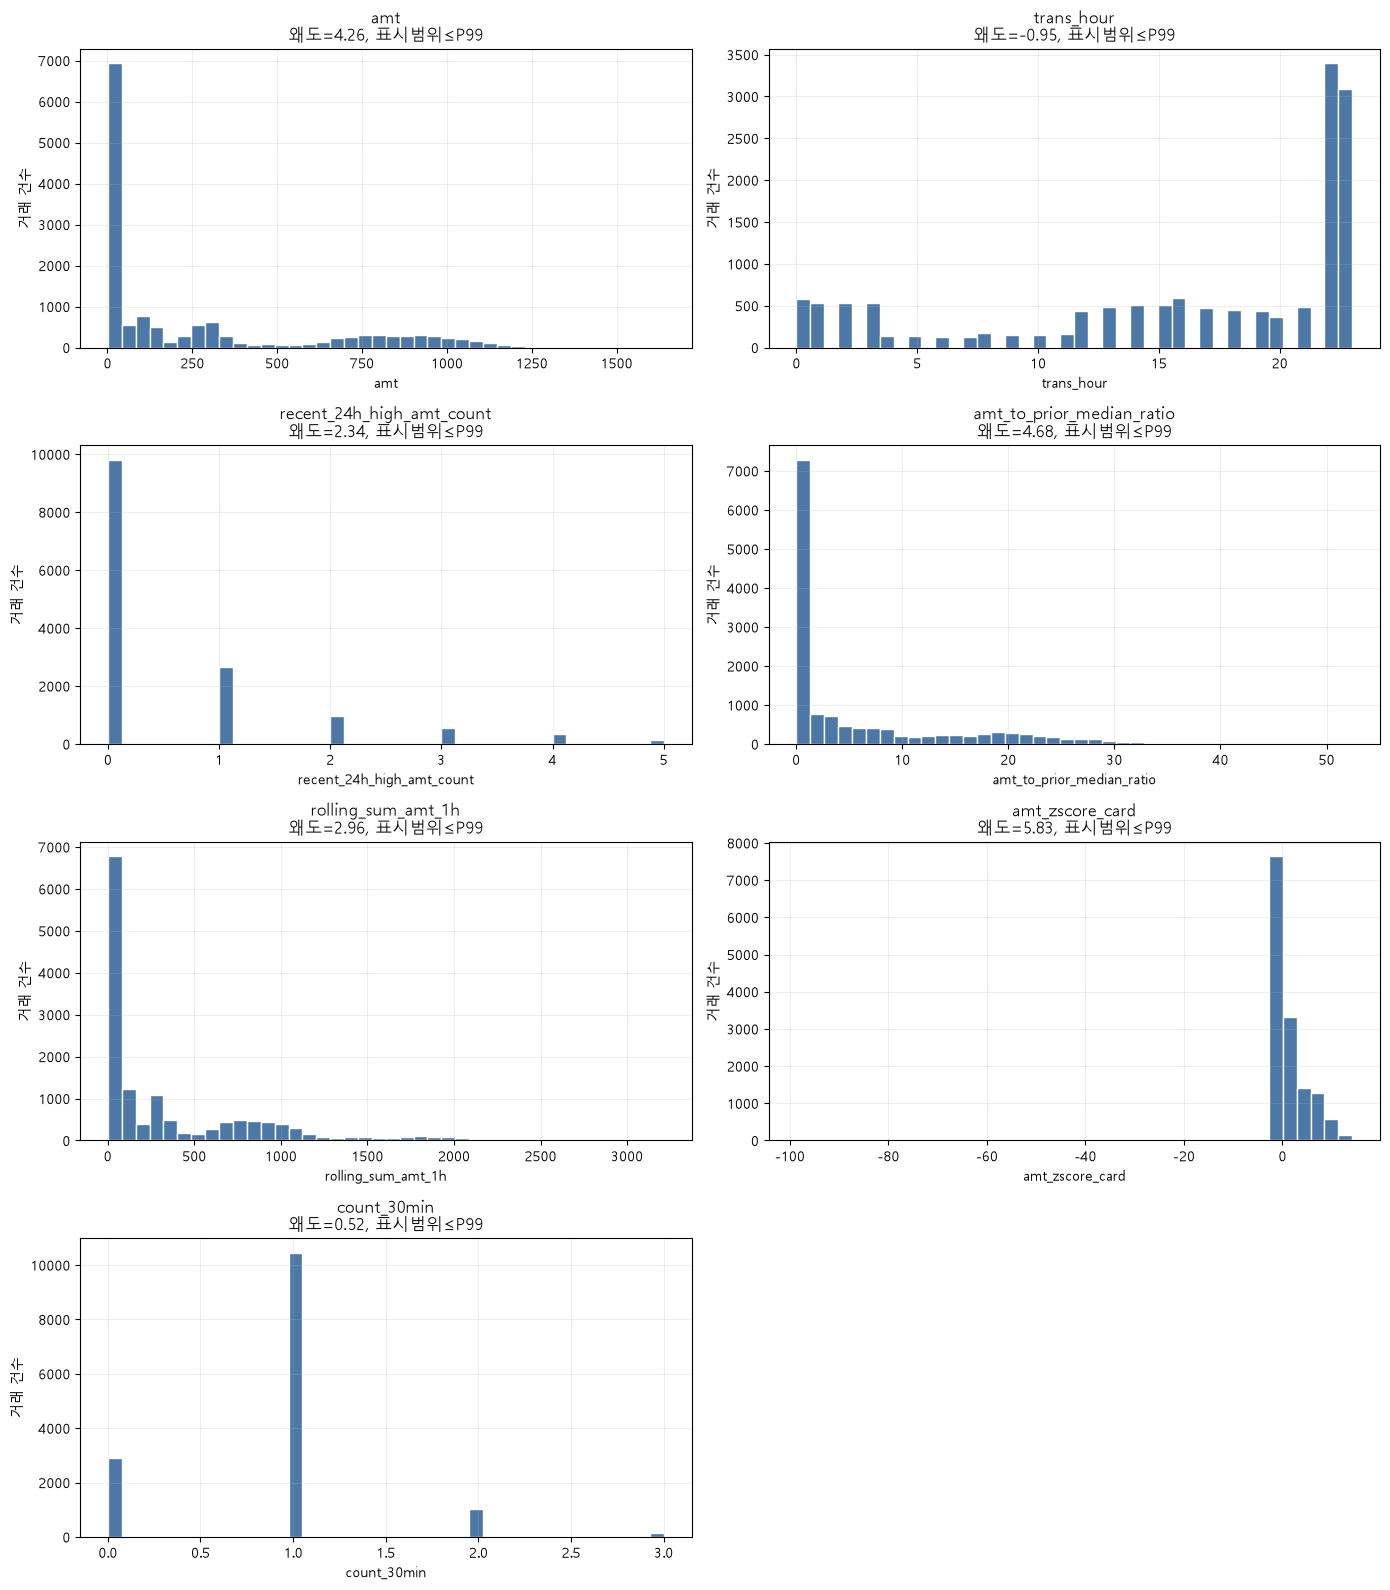

※ 그래프만 P99까지 표시했으며 실제 관측값은 제거하지 않았습니다.


In [17]:
# ============================================================
# STEP 2. 기존 군집변수 7개 분포·결측·왜도 확인
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


CLUSTER_CANDIDATES = [
    "amt",
    "trans_hour",
    "recent_24h_high_amt_count",
    "amt_to_prior_median_ratio",
    "rolling_sum_amt_1h",
    "amt_zscore_card",
    "count_30min"
]


# ------------------------------------------------------------
# 1. 기초 통계량
# ------------------------------------------------------------

distribution_results = []

for column in CLUSTER_CANDIDATES:

    values = pd.to_numeric(
        oof_top4_df[column],
        errors="coerce"
    )

    positive_inf_count = int(
        np.isposinf(values).sum()
    )

    negative_inf_count = int(
        np.isneginf(values).sum()
    )

    finite_values = values.replace(
        [np.inf, -np.inf],
        np.nan
    )

    valid_values = finite_values.dropna()

    distribution_results.append({
        "variable": column,
        "rows": len(values),
        "missing_count": int(values.isna().sum()),
        "positive_inf": positive_inf_count,
        "negative_inf": negative_inf_count,
        "zero_count": int((valid_values == 0).sum()),
        "negative_count": int((valid_values < 0).sum()),
        "unique_count": int(valid_values.nunique()),
        "min": valid_values.min(),
        "p50": valid_values.quantile(0.50),
        "p75": valid_values.quantile(0.75),
        "p90": valid_values.quantile(0.90),
        "p95": valid_values.quantile(0.95),
        "p99": valid_values.quantile(0.99),
        "max": valid_values.max(),
        "skewness": valid_values.skew()
    })


distribution_summary_df = pd.DataFrame(
    distribution_results
)

print("=" * 75)
print("상위 4등급 군집변수 분포 요약")
print("=" * 75)

display(
    distribution_summary_df.style.format({
        "min": "{:.4f}",
        "p50": "{:.4f}",
        "p75": "{:.4f}",
        "p90": "{:.4f}",
        "p95": "{:.4f}",
        "p99": "{:.4f}",
        "max": "{:.4f}",
        "skewness": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 2. 분포 시각화
# - 극단값 때문에 본체가 눌리지 않도록 99% 구간까지만 표시
# - 실제 데이터 삭제는 하지 않음
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 16)
)

axes = axes.flatten()

for index, column in enumerate(CLUSTER_CANDIDATES):

    values = (
        pd.to_numeric(
            oof_top4_df[column],
            errors="coerce"
        )
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    upper_limit = values.quantile(0.99)

    plot_values = values[
        values <= upper_limit
    ]

    axes[index].hist(
        plot_values,
        bins=40,
        color="#4C78A8",
        edgecolor="white"
    )

    axes[index].set_title(
        f"{column}\n"
        f"왜도={values.skew():.2f}, "
        f"표시범위≤P99"
    )

    axes[index].set_xlabel(column)
    axes[index].set_ylabel("거래 건수")
    axes[index].grid(alpha=0.2)

axes[-1].axis("off")

plt.tight_layout()
plt.show()

print(
    "※ 그래프만 P99까지 표시했으며 "
    "실제 관측값은 제거하지 않았습니다."
)

In [18]:
# ============================================================
# STEP 3. 군집변수 변환 및
# ratio와 z-score 중복성 확인
# ============================================================

import numpy as np
import pandas as pd


cluster_review_df = oof_top4_df.copy()


# ------------------------------------------------------------
# 1. ratio 결측 여부 보존
# - K-means 입력에는 우선 넣지 않고 사후 해석에 사용
# ------------------------------------------------------------

cluster_review_df["prior_history_missing"] = (
    cluster_review_df[
        "amt_to_prior_median_ratio"
    ].isna()
).astype(np.int8)


# ------------------------------------------------------------
# 2. ratio 결측값 중앙값 대체
# ------------------------------------------------------------

ratio_median = (
    cluster_review_df[
        "amt_to_prior_median_ratio"
    ].median()
)

cluster_review_df[
    "amt_to_prior_median_ratio_imputed"
] = (
    cluster_review_df[
        "amt_to_prior_median_ratio"
    ].fillna(ratio_median)
)


# ------------------------------------------------------------
# 3. 로그변환
# ------------------------------------------------------------

cluster_review_df["amt_log"] = np.log1p(
    cluster_review_df["amt"]
)

cluster_review_df[
    "recent_24h_high_amt_count_log"
] = np.log1p(
    cluster_review_df[
        "recent_24h_high_amt_count"
    ]
)

cluster_review_df[
    "amt_to_prior_median_ratio_log"
] = np.log1p(
    cluster_review_df[
        "amt_to_prior_median_ratio_imputed"
    ]
)

cluster_review_df[
    "rolling_sum_amt_1h_log"
] = np.log1p(
    cluster_review_df[
        "rolling_sum_amt_1h"
    ]
)


# 음수가 존재하는 Z-score: signed log
cluster_review_df[
    "amt_zscore_card_signed_log"
] = (
    np.sign(
        cluster_review_df["amt_zscore_card"]
    )
    * np.log1p(
        np.abs(
            cluster_review_df["amt_zscore_card"]
        )
    )
)


# ------------------------------------------------------------
# 4. 시간 변수 sin·cos 변환
# ------------------------------------------------------------

cluster_review_df["trans_hour_sin"] = np.sin(
    2 * np.pi
    * cluster_review_df["trans_hour"]
    / 24
)

cluster_review_df["trans_hour_cos"] = np.cos(
    2 * np.pi
    * cluster_review_df["trans_hour"]
    / 24
)


# ------------------------------------------------------------
# 5. 변환 후 상관관계
# ------------------------------------------------------------

comparison_columns = [
    "amt_to_prior_median_ratio_log",
    "amt_zscore_card_signed_log"
]

spearman_correlation = (
    cluster_review_df[comparison_columns]
    .corr(method="spearman")
    .iloc[0, 1]
)

pearson_correlation = (
    cluster_review_df[comparison_columns]
    .corr(method="pearson")
    .iloc[0, 1]
)


# ratio가 실제로 관측된 행만 별도 비교
observed_ratio_mask = (
    cluster_review_df[
        "prior_history_missing"
    ] == 0
)

observed_spearman = (
    cluster_review_df.loc[
        observed_ratio_mask,
        comparison_columns
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

observed_pearson = (
    cluster_review_df.loc[
        observed_ratio_mask,
        comparison_columns
    ]
    .corr(method="pearson")
    .iloc[0, 1]
)


print("=" * 70)
print("ratio와 z-score 변환 후 상관관계")
print("=" * 70)

print(f"ratio 결측 대체값: {ratio_median:.6f}")
print(
    "ratio 결측 건수:",
    int(
        cluster_review_df[
            "prior_history_missing"
        ].sum()
    )
)

print("\n[결측 중앙값 대체 후 전체]")
print(f"Spearman: {spearman_correlation:.4f}")
print(f"Pearson:  {pearson_correlation:.4f}")

print("\n[ratio가 실제 관측된 거래만]")
print(f"Spearman: {observed_spearman:.4f}")
print(f"Pearson:  {observed_pearson:.4f}")


# ------------------------------------------------------------
# 6. ratio 결측 여부에 따른 z-score 확인
# ------------------------------------------------------------

print("\n[ratio 결측 여부별 z-score 분포]")

display(
    cluster_review_df.groupby(
        "prior_history_missing"
    )["amt_zscore_card"]
    .agg([
        "count",
        "min",
        "median",
        "mean",
        "max"
    ])
)

ratio와 z-score 변환 후 상관관계
ratio 결측 대체값: 1.218029
ratio 결측 건수: 352

[결측 중앙값 대체 후 전체]
Spearman: 0.9360
Pearson:  0.9570

[ratio가 실제 관측된 거래만]
Spearman: 0.9435
Pearson:  0.9682

[ratio 결측 여부별 z-score 분포]


,count,min,median,mean,max
prior_history_missing,,,,,
0,14202,-1.137324,-0.119559,1.867852,145.562879
1,352,-98.682133,0.000000,-0.052938,124.335225


잠정 군집변수 데이터 점검
데이터 크기: (14554, 7)
전체 결측값: 0
전체 무한대: 0

[잠정 군집변수 Spearman 상관계수]


,amt_log,trans_hour_sin,trans_hour_cos,recent_24h_high_amt_count_log,amt_to_prior_median_ratio_log,rolling_sum_amt_1h_log,count_30min
amt_log,1.000,-0.004,-0.018,0.191,0.958,0.909,-0.375
trans_hour_sin,-0.004,1.000,0.247,0.046,0.009,0.023,-0.134
trans_hour_cos,-0.018,0.247,1.000,0.132,-0.023,0.056,0.052
recent_24h_high_amt_count_log,0.191,0.046,0.132,1.000,0.162,0.321,-0.037
amt_to_prior_median_ratio_log,0.958,0.009,-0.023,0.162,1.000,0.873,-0.354
rolling_sum_amt_1h_log,0.909,0.023,0.056,0.321,0.873,1.000,-0.276
count_30min,-0.375,-0.134,0.052,-0.037,-0.354,-0.276,1.000



[절댓값 상관계수 상위 조합]


,variable_1,variable_2,spearman,absolute_spearman
0,amt_log,amt_to_prior_median_ratio_log,0.9582,0.9582
1,amt_log,rolling_sum_amt_1h_log,0.9092,0.9092
2,amt_to_prior_median_ratio_log,rolling_sum_amt_1h_log,0.8730,0.8730
3,amt_log,count_30min,-0.3750,0.3750
4,amt_to_prior_median_ratio_log,count_30min,-0.3537,0.3537
5,recent_24h_high_amt_count_log,rolling_sum_amt_1h_log,0.3214,0.3214
6,rolling_sum_amt_1h_log,count_30min,-0.2758,0.2758
7,trans_hour_sin,trans_hour_cos,0.2468,0.2468
8,amt_log,recent_24h_high_amt_count_log,0.1908,0.1908
9,recent_24h_high_amt_count_log,amt_to_prior_median_ratio_log,0.1622,0.1622


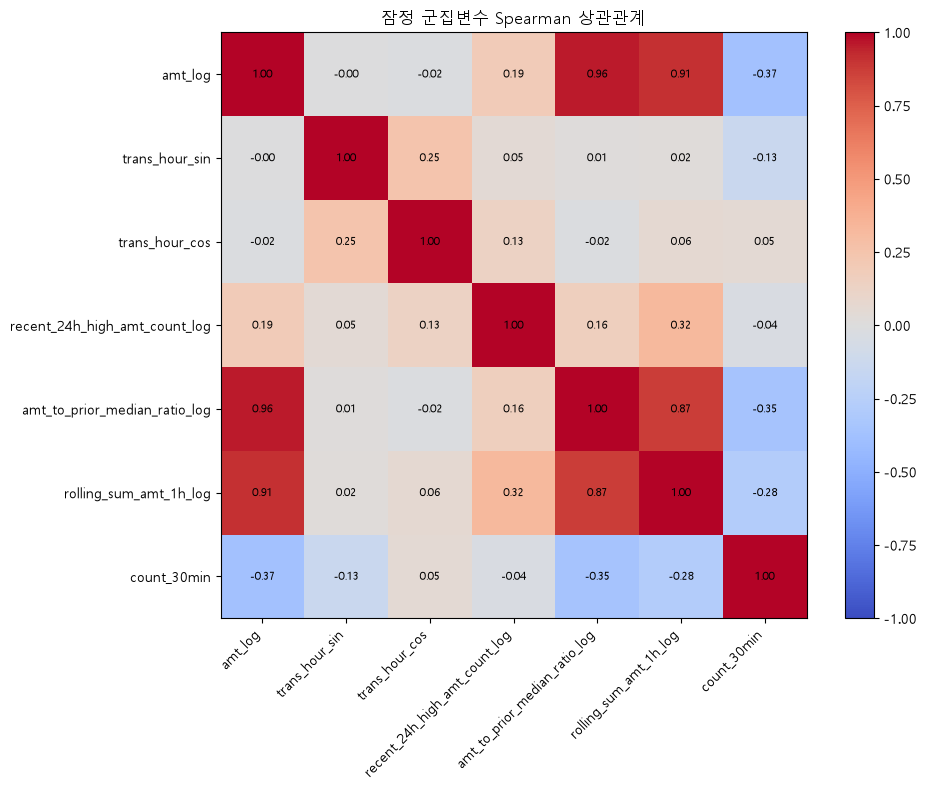

In [ ]:
## 금액 관련 다른 변수 사이에도 중복 확인

# ============================================================
# STEP 4. 잠정 군집변수 전체 상관관계 확인
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


PROVISIONAL_CLUSTER_FEATURES = [
    "amt_log",
    "trans_hour_sin",
    "trans_hour_cos",
    "recent_24h_high_amt_count_log",
    "amt_to_prior_median_ratio_log",
    "rolling_sum_amt_1h_log",
    "count_30min"
]


cluster_input_candidate_df = (
    cluster_review_df[
        PROVISIONAL_CLUSTER_FEATURES
    ]
    .copy()
)


# ------------------------------------------------------------
# 1. 결측·무한대 확인
# ------------------------------------------------------------

print("=" * 75)
print("잠정 군집변수 데이터 점검")
print("=" * 75)

print("데이터 크기:", cluster_input_candidate_df.shape)
print(
    "전체 결측값:",
    int(cluster_input_candidate_df.isna().sum().sum())
)

print(
    "전체 무한대:",
    int(
        np.isinf(
            cluster_input_candidate_df.to_numpy()
        ).sum()
    )
)


# ------------------------------------------------------------
# 2. Spearman 상관계수
# ------------------------------------------------------------

cluster_spearman_corr = (
    cluster_input_candidate_df
    .corr(method="spearman")
)

print("\n[잠정 군집변수 Spearman 상관계수]")

display(
    cluster_spearman_corr.style.format("{:.3f}")
)


# ------------------------------------------------------------
# 3. 절댓값 상관계수 상위 조합
# ------------------------------------------------------------

correlation_pairs = []

for first_index, first_variable in enumerate(
    PROVISIONAL_CLUSTER_FEATURES
):
    for second_variable in (
        PROVISIONAL_CLUSTER_FEATURES[
            first_index + 1:
        ]
    ):
        correlation_value = cluster_spearman_corr.loc[
            first_variable,
            second_variable
        ]

        correlation_pairs.append({
            "variable_1": first_variable,
            "variable_2": second_variable,
            "spearman": correlation_value,
            "absolute_spearman": abs(correlation_value)
        })


correlation_pairs_df = (
    pd.DataFrame(correlation_pairs)
    .sort_values(
        "absolute_spearman",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n[절댓값 상관계수 상위 조합]")

display(
    correlation_pairs_df.head(10)
    .style.format({
        "spearman": "{:.4f}",
        "absolute_spearman": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 4. 상관관계 히트맵
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

image = ax.imshow(
    cluster_spearman_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    range(len(PROVISIONAL_CLUSTER_FEATURES))
)

ax.set_yticks(
    range(len(PROVISIONAL_CLUSTER_FEATURES))
)

ax.set_xticklabels(
    PROVISIONAL_CLUSTER_FEATURES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    PROVISIONAL_CLUSTER_FEATURES
)

for row in range(len(PROVISIONAL_CLUSTER_FEATURES)):
    for column in range(len(PROVISIONAL_CLUSTER_FEATURES)):
        ax.text(
            column,
            row,
            f"{cluster_spearman_corr.iloc[row, column]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(image, ax=ax)
ax.set_title("잠정 군집변수 Spearman 상관관계")
plt.tight_layout()
plt.show()

amt: 절대적으로 얼마를 결제했는가
amt_to_prior_median_ratio: 해당 고객의 평소보다 몇 배 큰가

두 변수는 상관관계가 높지만, 목적이 다르므로 일단 유지.

->

< 군집분석 후 판단 방법 >

- 절대금액만 고액과 평소 대비만 고액이 모두 충분히 존재하고 특성이 다름 → amt와 ratio 모두 유지
- 두 집단이 거의 없고 대부분 절대·상대 모두 고액 → 정보 중복이 강하므로 하나만 유지
- 둘 다 유지한다면 K-means에서 금액 정보가 두 배 반영되지 않도록 표준화 후 가중치 조정 또는 포함·제외 군집 결과를 비교 <- 현재로서는 둘다 유지 후보.

In [20]:
# ============================================================
# STEP 5. rolling_sum_amt_1h에 현재 amt가 포함됐는지 점검
# ============================================================

import numpy as np
import pandas as pd


rolling_check_df = (
    oof_top4_df[
        ["amt", "rolling_sum_amt_1h"]
    ]
    .copy()
)

rolling_check_df["rolling_minus_amt"] = (
    rolling_check_df["rolling_sum_amt_1h"]
    - rolling_check_df["amt"]
)

total_count = len(rolling_check_df)

less_count = int(
    (
        rolling_check_df["rolling_sum_amt_1h"]
        < rolling_check_df["amt"]
    ).sum()
)

equal_count = int(
    np.isclose(
        rolling_check_df["rolling_sum_amt_1h"],
        rolling_check_df["amt"]
    ).sum()
)

greater_count = int(
    (
        rolling_check_df["rolling_sum_amt_1h"]
        > rolling_check_df["amt"]
    ).sum()
)

print("=" * 70)
print("rolling_sum_amt_1h 구성 점검")
print("=" * 70)

print(
    "rolling < amt:",
    f"{less_count:,}건",
    f"({less_count / total_count:.2%})"
)

print(
    "rolling = amt:",
    f"{equal_count:,}건",
    f"({equal_count / total_count:.2%})"
)

print(
    "rolling > amt:",
    f"{greater_count:,}건",
    f"({greater_count / total_count:.2%})"
)

print("\n[rolling - amt 분포]")

display(
    rolling_check_df["rolling_minus_amt"]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .to_frame("rolling_minus_amt")
)


# 현재 거래금액을 제외한 최근 1시간 누적금액 후보
rolling_check_df[
    "prior_1h_sum_amt"
] = (
    rolling_check_df[
        "rolling_minus_amt"
    ]
    .clip(lower=0)
)

rolling_check_df[
    "prior_1h_sum_amt_log"
] = np.log1p(
    rolling_check_df[
        "prior_1h_sum_amt"
    ]
)

comparison_df = pd.DataFrame({
    "amt_log":
        np.log1p(
            oof_top4_df["amt"]
        ),

    "ratio_log":
        cluster_review_df[
            "amt_to_prior_median_ratio_log"
        ],

    "original_rolling_log":
        np.log1p(
            oof_top4_df[
                "rolling_sum_amt_1h"
            ]
        ),

    "prior_1h_sum_amt_log":
        rolling_check_df[
            "prior_1h_sum_amt_log"
        ]
})

print("\n[현재 금액 제외 전후 상관관계]")

display(
    comparison_df
    .corr(method="spearman")
    .style.format("{:.4f}")
)

rolling_sum_amt_1h 구성 점검
rolling < amt: 0건 (0.00%)
rolling = amt: 10,881건 (74.76%)
rolling > amt: 3,673건 (25.24%)

[rolling - amt 분포]


,rolling_minus_amt
count,14554.000000
mean,134.307709
std,429.563581
min,0.000000
25%,0.000000
50%,0.000000
75%,1.357500
90%,347.231000
95%,971.798500
99%,2102.592400



[현재 금액 제외 전후 상관관계]


,amt_log,ratio_log,original_rolling_log,prior_1h_sum_amt_log
amt_log,1.0000,0.9582,0.9092,0.1913
ratio_log,0.9582,1.0000,0.8730,0.1718
original_rolling_log,0.9092,0.8730,1.0000,0.4720
prior_1h_sum_amt_log,0.1913,0.1718,0.4720,1.0000


하하 큰일남...

< 결과 해석 > 

" rolling_sum_amt_1h에는 현재 거래금액 amt가 포함되어 있어. "

- rolling < amt: 0건
- rolling = amt: 74.76%
- rolling > amt: 25.24%

=> 즉, 약 75%는 최근 1시간에 다른 거래가 없어 rolling_sum_amt_1h = 현재 amt였던 거야. 그래서 amt와 상관계수가 0.909로 높았던 거고.

현재 금액을 빼자 상관관계가 크게 낮아졌어.

- prior_1h_sum_amt ↔ amt: 0.191
- prior_1h_sum_amt ↔ ratio: 0.172

-> 따라서 최종 처리는 다음처럼 정하면 돼.

- 기존 rolling_sum_amt_1h_log: 군집 입력에서 제외
- 새 변수 prior_1h_sum_amt_log: 군집 입력에 포함


In [21]:
# ============================================================
# STEP 6. 절대금액과 평소 대비 금액 유형 비교
# - amt와 ratio를 모두 군집변수로 사용할지 판단
# ============================================================

import numpy as np
import pandas as pd


amount_type_df = oof_top4_df.copy()


# ------------------------------------------------------------
# 1. 고위험 기준 설정
# ------------------------------------------------------------

# 원자료 분석에서 사기가 집중됐던 절대금액 구간
absolute_high = (
    (amount_type_df["amt"] >= 700)
    & (amount_type_df["amt"] < 1500)
)

# 이전 정상거래 중앙값의 5배 이상
relative_high = (
    amount_type_df[
        "amt_to_prior_median_ratio"
    ] >= 5
)

# 이전 정상거래 이력이 없어 ratio가 결측인 경우
ratio_missing = (
    amount_type_df[
        "amt_to_prior_median_ratio"
    ].isna()
)


# ------------------------------------------------------------
# 2. 절대금액·상대금액 조합 유형 생성
# ------------------------------------------------------------

amount_type_df["amount_pattern"] = np.select(
    [
        ratio_missing,
        absolute_high & relative_high,
        absolute_high & ~relative_high,
        ~absolute_high & relative_high
    ],
    [
        "과거 기준 없음",
        "절대·상대 모두 고액",
        "절대금액만 고액",
        "평소 대비만 고액"
    ],
    default="둘 다 해당 없음"
)


# ------------------------------------------------------------
# 3. 유형별 요약
# ------------------------------------------------------------

amount_pattern_summary = (
    amount_type_df.groupby(
        "amount_pattern",
        observed=True
    )
    .agg(
        transactions=(
            "is_fraud",
            "size"
        ),

        fraud_count=(
            "is_fraud",
            "sum"
        ),

        fraud_rate=(
            "is_fraud",
            "mean"
        ),

        median_amt=(
            "amt",
            "median"
        ),

        median_ratio=(
            "amt_to_prior_median_ratio",
            "median"
        ),

        median_probability=(
            "y_probability",
            "median"
        )
    )
    .reset_index()
)

amount_pattern_summary[
    "transaction_share"
] = (
    amount_pattern_summary["transactions"]
    / len(amount_type_df)
)

amount_pattern_summary[
    "fraud_coverage"
] = (
    amount_pattern_summary["fraud_count"]
    / amount_type_df["is_fraud"].sum()
)


# ------------------------------------------------------------
# 4. 결과 출력
# ------------------------------------------------------------

print("=" * 80)
print("절대금액과 평소 대비 금액 유형 비교")
print("=" * 80)

display(
    amount_pattern_summary[
        [
            "amount_pattern",
            "transactions",
            "transaction_share",
            "fraud_count",
            "fraud_rate",
            "fraud_coverage",
            "median_amt",
            "median_ratio",
            "median_probability"
        ]
    ]
    .sort_values(
        "fraud_rate",
        ascending=False
    )
    .style.format({
        "transaction_share": "{:.2%}",
        "fraud_rate": "{:.2%}",
        "fraud_coverage": "{:.2%}",
        "median_amt": "${:,.2f}",
        "median_ratio": "{:.2f}배",
        "median_probability": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 5. 유형별 TP·TN·FP·FN
# ------------------------------------------------------------

print("\n[유형별 TP·TN·FP·FN]")

amount_pattern_confusion = pd.crosstab(
    amount_type_df["amount_pattern"],
    amount_type_df["confusion_type"],
    margins=True
)

display(
    amount_pattern_confusion.reindex(
        columns=["TN", "FP", "FN", "TP", "All"],
        fill_value=0
    )
)


# ------------------------------------------------------------
# 6. 핵심 비교 건수
# ------------------------------------------------------------

absolute_only_count = int(
    (
        amount_type_df["amount_pattern"]
        == "절대금액만 고액"
    ).sum()
)

relative_only_count = int(
    (
        amount_type_df["amount_pattern"]
        == "평소 대비만 고액"
    ).sum()
)

both_high_count = int(
    (
        amount_type_df["amount_pattern"]
        == "절대·상대 모두 고액"
    ).sum()
)

print("\n[핵심 판단]")
print(
    "절대금액만 고액:",
    f"{absolute_only_count:,}건"
)

print(
    "평소 대비만 고액:",
    f"{relative_only_count:,}건"
)

print(
    "절대·상대 모두 고액:",
    f"{both_high_count:,}건"
)

절대금액과 평소 대비 금액 유형 비교


,amount_pattern,transactions,transaction_share,fraud_count,fraud_rate,fraud_coverage,median_amt,median_ratio,median_probability
0,과거 기준 없음,352,2.42%,352,100.00%,9.65%,$775.56,nan배,1.0000
2,절대·상대 모두 고액,2739,18.82%,1506,54.98%,41.27%,$903.70,21.28배,0.9940
3,평소 대비만 고액,2300,15.80%,900,39.13%,24.66%,$339.81,8.65배,0.2745
1,둘 다 해당 없음,9163,62.96%,891,9.72%,24.42%,$19.67,0.47배,0.0388



[유형별 TP·TN·FP·FN]


confusion_type,TN,FP,FN,TP,All
amount_pattern,,,,,
과거 기준 없음,0,0,3,349,352
둘 다 해당 없음,8190,82,139,752,9163
절대·상대 모두 고액,1174,59,46,1460,2739
평소 대비만 고액,1380,20,27,873,2300
All,10744,161,215,3434,14554



[핵심 판단]
절대금액만 고액: 0건
평소 대비만 고액: 2,300건
절대·상대 모두 고액: 2,739건


결과를 보면 amt는 K-means 입력에서 제외해도 된다는 근거가 충분해.

핵심은 다음이야.

절대금액만 고액: 0건
$700~1,500 고액거래 2,739건은 전부 ratio 5배 이상
평소 대비만 고액: 2,300건 별도 존재
amt ↔ ratio 상관계수: 0.958

즉, 상위 4등급에서는 절대 고액거래가 전부 ratio 변수에도 포착됐고, ratio는 추가로 $700 미만이지만 평소보다 큰 거래까지 구분했어. amt를 함께 넣으면 동일한 금액 위험을 두 번 반영할 가능성이 커.

다만 amt를 버리는 건 아니야. K-means 군집을 만든 뒤 군집별 중앙값·금액 구간을 확인하는 보조 해석 변수로 사용하면 돼.

또한 과거 기준 없음 352건은 전부 실제 사기이고 예측확률 중앙값도 1이야. 이 집단은 매우 중요한 특수 유형이지만, 희소 이진변수를 K-means에 넣으면 거리를 지배할 수 있으므로 prior_history_missing으로 별도 표시하고 군집별 비율을 확인하자.

<정리>

1. trans_hour는 sin, cos으로 변경
2. amt_zscore_card를 군집변수에서 제외, amt_to_prior_median_ratio 채택
3. count_min을 제외한 나머지 변수들은 모두 log변환.

-> 총 6개 변수로 결정.

- amt_to_prior_median_ratio_log   # 유지 후보
- prior_1h_sum_amt_log            # 유지 확정
- recent_24h_high_amt_count_log   # 유지 후보  <- rolling_sum 대체
- count_30min                     # 유지 후보
- trans_hour_sin                  # 유지 확정
- trans_hour_cos                  # 유지 확정

prior_1h_sum_amt의 중앙값이 0이고 75% 지점도 약 1.36이므로, 대부분은 직전 1시간 거래가 거의 없지만 일부 거래에서 누적금액이 크게 증가하는 구조야. 이런 변수는 반복·연속 결제 유형을 구분하는 데 유용해.

amt, amt_zscore_card는 군집변수에서는 제외, 사후 프로파일링.

즉, 보조 해석 변수는 아래와 같음.(다 할 필요는 x. 시간상 어렵)

amt
amt_zscore_card
category
high_speed
age
prior_normal_median_amt
prior_history_missing
risk_grade
confusion_type
is_fraud
y_probability

In [22]:
## 최종 6개 수치 축을 구성하고 표준화한 뒤, K값(2~8)별 군집 품질 비교하기.
## 실루엣 등 계수, 군집 크기 균형 비교

# ============================================================
# STEP 7. 최종 군집변수 생성·표준화 및 K값 비교
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)


RANDOM_STATE = 42


# ------------------------------------------------------------
# 1. 상위 4등급 OOF 데이터 복사
# ------------------------------------------------------------

cluster_model_base_df = (
    oof_top4_df
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 2. ratio 결측 처리
# ------------------------------------------------------------

cluster_model_base_df[
    "prior_history_missing"
] = (
    cluster_model_base_df[
        "amt_to_prior_median_ratio"
    ].isna()
).astype(np.int8)

RATIO_MEDIAN = (
    cluster_model_base_df[
        "amt_to_prior_median_ratio"
    ].median()
)

cluster_model_base_df[
    "amt_to_prior_median_ratio_imputed"
] = (
    cluster_model_base_df[
        "amt_to_prior_median_ratio"
    ].fillna(RATIO_MEDIAN)
)

cluster_model_base_df[
    "amt_to_prior_median_ratio_log"
] = np.log1p(
    cluster_model_base_df[
        "amt_to_prior_median_ratio_imputed"
    ]
)


# ------------------------------------------------------------
# 3. 현재 거래금액을 제외한 직전 1시간 누적금액
# ------------------------------------------------------------

cluster_model_base_df[
    "prior_1h_sum_amt"
] = (
    cluster_model_base_df[
        "rolling_sum_amt_1h"
    ]
    - cluster_model_base_df["amt"]
).clip(lower=0)

cluster_model_base_df[
    "prior_1h_sum_amt_log"
] = np.log1p(
    cluster_model_base_df[
        "prior_1h_sum_amt"
    ]
)


# ------------------------------------------------------------
# 4. 최근 24시간 고액거래 횟수 로그변환
# ------------------------------------------------------------

cluster_model_base_df[
    "recent_24h_high_amt_count_log"
] = np.log1p(
    cluster_model_base_df[
        "recent_24h_high_amt_count"
    ]
)


# ------------------------------------------------------------
# 5. 거래시간 sin·cos 변환
# ------------------------------------------------------------

cluster_model_base_df[
    "trans_hour_sin"
] = np.sin(
    2 * np.pi
    * cluster_model_base_df["trans_hour"]
    / 24
)

cluster_model_base_df[
    "trans_hour_cos"
] = np.cos(
    2 * np.pi
    * cluster_model_base_df["trans_hour"]
    / 24
)


# ------------------------------------------------------------
# 6. 최종 군집 입력변수
# ------------------------------------------------------------

FINAL_CLUSTER_FEATURES = [
    "amt_to_prior_median_ratio_log",
    "prior_1h_sum_amt_log",
    "recent_24h_high_amt_count_log",
    "count_30min",
    "trans_hour_sin",
    "trans_hour_cos"
]

cluster_feature_df = (
    cluster_model_base_df[
        FINAL_CLUSTER_FEATURES
    ]
    .copy()
)


# ------------------------------------------------------------
# 7. 결측·무한대 최종 검증
# ------------------------------------------------------------

missing_count = int(
    cluster_feature_df.isna().sum().sum()
)

infinity_count = int(
    np.isinf(
        cluster_feature_df.to_numpy()
    ).sum()
)

print("=" * 75)
print("최종 군집 입력데이터 확인")
print("=" * 75)

print("거래 수:", f"{len(cluster_feature_df):,}")
print("입력변수 수:", len(FINAL_CLUSTER_FEATURES))
print("결측값:", missing_count)
print("무한대:", infinity_count)
print("ratio 중앙값 대체값:", f"{RATIO_MEDIAN:.6f}")

print("\n최종 군집변수:")
for feature in FINAL_CLUSTER_FEATURES:
    print("-", feature)

if missing_count > 0 or infinity_count > 0:
    raise ValueError(
        "군집 입력값에 결측 또는 무한대가 있습니다."
    )


# ------------------------------------------------------------
# 8. 표준화
# ------------------------------------------------------------

cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(
    cluster_feature_df
)

print("\n표준화 후 평균 최댓값:",
      f"{np.abs(X_cluster_scaled.mean(axis=0)).max():.8f}")

print(
    "표준화 후 표준편차 범위:",
    f"{X_cluster_scaled.std(axis=0).min():.4f}",
    "~",
    f"{X_cluster_scaled.std(axis=0).max():.4f}"
)


# ------------------------------------------------------------
# 9. K=2~8 비교
# ------------------------------------------------------------

cluster_selection_results = []
kmeans_models = {}

for k in range(2, 9):

    start_time = time.perf_counter()

    kmeans_model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        max_iter=500,
        random_state=RANDOM_STATE
    )

    cluster_labels = kmeans_model.fit_predict(
        X_cluster_scaled
    )

    kmeans_models[k] = kmeans_model

    cluster_counts = pd.Series(
        cluster_labels
    ).value_counts()

    silhouette_sample_size = min(
        5000,
        len(X_cluster_scaled)
    )

    silhouette = silhouette_score(
        X_cluster_scaled,
        cluster_labels,
        sample_size=silhouette_sample_size,
        random_state=RANDOM_STATE
    )

    davies_bouldin = davies_bouldin_score(
        X_cluster_scaled,
        cluster_labels
    )

    calinski_harabasz = calinski_harabasz_score(
        X_cluster_scaled,
        cluster_labels
    )

    elapsed_seconds = (
        time.perf_counter()
        - start_time
    )

    cluster_selection_results.append({
        "k": k,
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
        "inertia": kmeans_model.inertia_,
        "smallest_cluster": int(
            cluster_counts.min()
        ),
        "smallest_cluster_share": (
            cluster_counts.min()
            / len(cluster_labels)
        ),
        "largest_cluster": int(
            cluster_counts.max()
        ),
        "largest_cluster_share": (
            cluster_counts.max()
            / len(cluster_labels)
        ),
        "elapsed_seconds": elapsed_seconds
    })

    print(
        f"K={k} 완료 | "
        f"Silhouette={silhouette:.4f} | "
        f"DB={davies_bouldin:.4f} | "
        f"최소 군집={cluster_counts.min():,}건"
    )


cluster_selection_df = pd.DataFrame(
    cluster_selection_results
)


# ------------------------------------------------------------
# 10. 결과 출력
# ------------------------------------------------------------

print("\n")
print("=" * 90)
print("K-means 군집 수 비교")
print("=" * 90)

display(
    cluster_selection_df.style.format({
        "silhouette": "{:.4f}",
        "davies_bouldin": "{:.4f}",
        "calinski_harabasz": "{:,.2f}",
        "inertia": "{:,.2f}",
        "smallest_cluster_share": "{:.2%}",
        "largest_cluster_share": "{:.2%}",
        "elapsed_seconds": "{:.2f}"
    })
)

최종 군집 입력데이터 확인
거래 수: 14,554
입력변수 수: 6
결측값: 0
무한대: 0
ratio 중앙값 대체값: 1.218029

최종 군집변수:
- amt_to_prior_median_ratio_log
- prior_1h_sum_amt_log
- recent_24h_high_amt_count_log
- count_30min
- trans_hour_sin
- trans_hour_cos

표준화 후 평균 최댓값: 0.00000000
표준화 후 표준편차 범위: 1.0000 ~ 1.0000


c:\Users\splen\anaconda3\envs\fraud-fds\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


K=2 완료 | Silhouette=0.3111 | DB=1.6385 | 최소 군집=2,950건
K=3 완료 | Silhouette=0.2516 | DB=1.5879 | 최소 군집=2,657건
K=4 완료 | Silhouette=0.2702 | DB=1.4422 | 최소 군집=2,013건
K=5 완료 | Silhouette=0.2899 | DB=1.2821 | 최소 군집=1,942건
K=6 완료 | Silhouette=0.3069 | DB=1.2260 | 최소 군집=1,118건
K=7 완료 | Silhouette=0.3187 | DB=1.1932 | 최소 군집=1,110건
K=8 완료 | Silhouette=0.3162 | DB=1.2307 | 최소 군집=1,067건


K-means 군집 수 비교


,k,silhouette,davies_bouldin,calinski_harabasz,inertia,smallest_cluster,smallest_cluster_share,largest_cluster,largest_cluster_share,elapsed_seconds
0,2,0.3111,1.6385,"3,655.43","69,792.41",2950,20.27%,11604,79.73%,60.98
1,3,0.2516,1.5879,"3,654.08","58,129.08",2657,18.26%,7456,51.23%,14.64
2,4,0.2702,1.4422,"3,720.20","49,417.93",2013,13.83%,5855,40.23%,3.65
3,5,0.2899,1.2821,"3,766.15","42,901.86",1942,13.34%,5405,37.14%,7.34
4,6,0.3069,1.2260,"3,891.37","37,359.08",1118,7.68%,4957,34.06%,13.86
5,7,0.3187,1.1932,"3,802.82","33,998.12",1110,7.63%,4717,32.41%,3.33
6,8,0.3162,1.2307,"3,605.77","31,925.88",1067,7.33%,4194,28.82%,4.03


결론부터 : 어쩌구_raio 결측을 중앙값으로 대체함.

이유 : Train OOF 상위 4등급 14,554건 중 ratio 결측이 352건이고, 그 352건은 전부 is_fraud=1. (다만 Test에서도 반드시 100% 사기라는 뜻은 아님.)

목적 : 사기거래 유형 파악이라면 중앙값으로 대체해서 K-means에 포함해도 돼. 오히려 별도로 제외하면 352건의 행동 유형을 군집 안에서 확인할 수 없다는 네 말이 맞아.

나중에 다음처럼 해석하면 돼.

군집 2에는 과거 정상거래 이력이 없는 거래가 70% 집중됐으며, 이 거래들은 주로 심야·반복 고액거래 특성을 보였다.

중앙값으로 채운 값 자체를 실제 고객의 ratio로 해석하지만 않으면 돼.

In [23]:
# ============================================================
# STEP 8. 후보 K의 초기값별 군집 안정성 비교 ( k=5,6,7 비교 목적 )
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score


CANDIDATE_K_VALUES = [5, 6, 7]
STABILITY_SEEDS = [0, 21, 42, 84, 123]

stability_results = []
stability_labels = {}


for k in CANDIDATE_K_VALUES:

    print(f"\nK={k} 안정성 실험 시작")

    labels_by_seed = {}

    for seed in STABILITY_SEEDS:

        start_time = time.perf_counter()

        model = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=20,
            max_iter=500,
            random_state=seed
        )

        labels = model.fit_predict(
            X_cluster_scaled
        )

        labels_by_seed[seed] = labels

        print(
            f"  seed={seed} 완료 | "
            f"{time.perf_counter() - start_time:.2f}초"
        )

    stability_labels[k] = labels_by_seed

    pairwise_ari_values = []

    for first_index, first_seed in enumerate(
        STABILITY_SEEDS
    ):
        for second_seed in STABILITY_SEEDS[
            first_index + 1:
        ]:

            ari = adjusted_rand_score(
                labels_by_seed[first_seed],
                labels_by_seed[second_seed]
            )

            pairwise_ari_values.append(ari)

    reference_labels = labels_by_seed[42]

    cluster_counts = (
        pd.Series(reference_labels)
        .value_counts()
    )

    stability_results.append({
        "k": k,
        "mean_ari": np.mean(
            pairwise_ari_values
        ),
        "minimum_ari": np.min(
            pairwise_ari_values
        ),
        "maximum_ari": np.max(
            pairwise_ari_values
        ),
        "smallest_cluster": int(
            cluster_counts.min()
        ),
        "smallest_cluster_share": (
            cluster_counts.min()
            / len(reference_labels)
        ),
        "largest_cluster": int(
            cluster_counts.max()
        ),
        "largest_cluster_share": (
            cluster_counts.max()
            / len(reference_labels)
        )
    })


cluster_stability_df = pd.DataFrame(
    stability_results
)

print("\n")
print("=" * 80)
print("후보 K 군집 안정성 비교")
print("=" * 80)

display(
    cluster_stability_df.style.format({
        "mean_ari": "{:.4f}",
        "minimum_ari": "{:.4f}",
        "maximum_ari": "{:.4f}",
        "smallest_cluster_share": "{:.2%}",
        "largest_cluster_share": "{:.2%}"
    })
)


K=5 안정성 실험 시작
  seed=0 완료 | 1.29초
  seed=21 완료 | 8.19초
  seed=42 완료 | 12.92초
  seed=84 완료 | 6.72초
  seed=123 완료 | 2.61초

K=6 안정성 실험 시작
  seed=0 완료 | 1.16초
  seed=21 완료 | 2.83초
  seed=42 완료 | 5.57초
  seed=84 완료 | 2.15초
  seed=123 완료 | 1.43초

K=7 안정성 실험 시작
  seed=0 완료 | 3.59초
  seed=21 완료 | 4.13초
  seed=42 완료 | 4.83초
  seed=84 완료 | 3.82초
  seed=123 완료 | 3.95초


후보 K 군집 안정성 비교


,k,mean_ari,minimum_ari,maximum_ari,smallest_cluster,smallest_cluster_share,largest_cluster,largest_cluster_share
0,5,0.9961,0.9931,0.9993,1942,13.34%,5405,37.14%
1,6,0.9960,0.9934,1.0000,1118,7.68%,4957,34.06%
2,7,0.9984,0.9971,0.9993,1110,7.63%,4717,32.41%


k=5,6,7 모두 안정적.

In [24]:
# ============================================================
# STEP 9. K=5·6·7 군집별 행동 및 예측 성능 프로파일
# ============================================================

import numpy as np
import pandas as pd


PROFILE_K_VALUES = [5, 6, 7]

candidate_behavior_profiles = {}
candidate_performance_profiles = {}


# ------------------------------------------------------------
# 1. 보조 변수 생성
# ------------------------------------------------------------

profile_base_df = (
    cluster_model_base_df
    .copy()
)

profile_base_df["is_night"] = (
    profile_base_df["trans_hour"].isin(
        [22, 23, 0, 1, 2, 3, 4]
    )
).astype(np.int8)


# ------------------------------------------------------------
# 2. 후보 K별 프로파일 생성
# ------------------------------------------------------------

for k in PROFILE_K_VALUES:

    profile_df = (
        profile_base_df
        .copy()
    )

    profile_df["cluster"] = (
        kmeans_models[k].labels_
    )

    behavior_rows = []
    performance_rows = []

    for cluster_number, group in profile_df.groupby(
        "cluster"
    ):

        confusion_counts = (
            group["confusion_type"]
            .value_counts()
        )

        tn = int(confusion_counts.get("TN", 0))
        fp = int(confusion_counts.get("FP", 0))
        fn = int(confusion_counts.get("FN", 0))
        tp = int(confusion_counts.get("TP", 0))

        precision = (
            tp / (tp + fp)
            if (tp + fp) > 0
            else np.nan
        )

        recall = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else np.nan
        )

        category_mode = (
            group["category"]
            .astype("string")
            .mode()
        )

        top_category = (
            category_mode.iloc[0]
            if len(category_mode) > 0
            else "없음"
        )

        behavior_rows.append({
            "k": k,
            "cluster": cluster_number,
            "transactions": len(group),
            "transaction_share":
                len(group) / len(profile_df),

            "median_amt":
                group["amt"].median(),

            "median_ratio":
                group[
                    "amt_to_prior_median_ratio"
                ].median(),

            "median_prior_1h_amt":
                group[
                    "prior_1h_sum_amt"
                ].median(),

            "median_recent_24h_high_count":
                group[
                    "recent_24h_high_amt_count"
                ].median(),

            "median_count_30min":
                group["count_30min"].median(),

            "night_share":
                group["is_night"].mean(),

            "ratio_missing_share":
                group[
                    "prior_history_missing"
                ].mean(),

            "high_speed_share":
                group["high_speed"].mean(),

            "top_category":
                top_category
        })

        performance_rows.append({
            "k": k,
            "cluster": cluster_number,
            "transactions": len(group),

            "fraud_count":
                int(group["is_fraud"].sum()),

            "fraud_rate":
                group["is_fraud"].mean(),

            "median_probability":
                group["y_probability"].median(),

            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,

            "precision":
                precision,

            "recall":
                recall,

            "specificity":
                specificity,

            "predicted_positive_share":
                group["y_pred"].mean()
        })


    behavior_profile_df = (
        pd.DataFrame(behavior_rows)
        .sort_values("cluster")
        .reset_index(drop=True)
    )

    performance_profile_df = (
        pd.DataFrame(performance_rows)
        .sort_values("cluster")
        .reset_index(drop=True)
    )

    candidate_behavior_profiles[k] = (
        behavior_profile_df
    )

    candidate_performance_profiles[k] = (
        performance_profile_df
    )


# ------------------------------------------------------------
# 3. 결과 출력
# ------------------------------------------------------------

for k in PROFILE_K_VALUES:

    print("\n")
    print("=" * 100)
    print(f"K={k} 군집 행동 특성")
    print("=" * 100)

    display(
        candidate_behavior_profiles[k]
        .style.format({
            "transaction_share": "{:.2%}",
            "median_amt": "${:,.2f}",
            "median_ratio": "{:.2f}배",
            "median_prior_1h_amt": "${:,.2f}",
            "median_recent_24h_high_count": "{:.1f}",
            "median_count_30min": "{:.1f}",
            "night_share": "{:.2%}",
            "ratio_missing_share": "{:.2%}",
            "high_speed_share": "{:.2%}"
        })
    )

    print(f"\n[K={k} 군집별 모델 예측 성능]")

    display(
        candidate_performance_profiles[k]
        .style.format({
            "fraud_rate": "{:.2%}",
            "median_probability": "{:.4f}",
            "precision": "{:.2%}",
            "recall": "{:.2%}",
            "specificity": "{:.2%}",
            "predicted_positive_share": "{:.2%}"
        })
    )



K=5 군집 행동 특성


,k,cluster,transactions,transaction_share,median_amt,median_ratio,median_prior_1h_amt,median_recent_24h_high_count,median_count_30min,night_share,ratio_missing_share,high_speed_share,top_category
0,5,0,5405,37.14%,$20.32,0.49배,$0.00,0.0,1.0,89.57%,2.09%,17.45%,kids_pets
1,5,1,2100,14.43%,$256.99,4.45배,$0.00,0.0,1.0,55.71%,2.38%,4.10%,grocery_pos
2,5,2,2006,13.78%,$895.25,21.51배,$0.00,0.0,0.0,49.85%,1.00%,2.54%,shopping_net
3,5,3,1942,13.34%,$355.13,8.54배,$818.65,2.0,1.0,91.56%,7.00%,40.73%,shopping_net
4,5,4,3101,21.31%,$21.76,0.58배,$0.00,0.0,1.0,0.00%,1.06%,7.93%,kids_pets



[K=5 군집별 모델 예측 성능]


,k,cluster,transactions,fraud_count,fraud_rate,median_probability,TN,FP,FN,TP,precision,recall,specificity,predicted_positive_share
0,5,0,5405,556,10.29%,0.0467,4797,52,87,469,90.02%,84.35%,98.93%,9.64%
1,5,1,2100,689,32.81%,0.1248,1377,34,43,646,95.00%,93.76%,97.59%,32.38%
2,5,2,2006,778,38.78%,0.5526,1177,51,29,749,93.62%,96.27%,95.85%,39.88%
3,5,3,1942,1486,76.52%,1.0000,439,17,18,1468,98.86%,98.79%,96.27%,76.47%
4,5,4,3101,140,4.51%,0.0288,2954,7,38,102,93.58%,72.86%,99.76%,3.51%




K=6 군집 행동 특성


...

,k,cluster,transactions,fraud_count,fraud_rate,median_probability,TN,FP,FN,TP,precision,recall,specificity,predicted_positive_share
0,6,0,2993,136,4.54%,0.0283,2850,7,36,100,93.46%,73.53%,99.75%,3.58%
1,6,1,4957,533,10.75%,0.0483,4375,49,72,461,90.39%,86.49%,98.89%,10.29%
2,6,2,1408,1157,82.17%,1.0000,237,14,15,1142,98.79%,98.70%,94.42%,82.10%
3,6,3,1118,411,36.76%,0.1667,700,7,23,388,98.23%,94.40%,99.01%,35.33%
4,6,4,1996,727,36.42%,0.4468,1218,51,29,698,93.19%,96.01%,95.98%,37.53%
5,6,5,2082,685,32.90%,0.1251,1364,33,40,645,95.13%,94.16%,97.64%,32.56%




K=7 군집 행동 특성


,k,cluster,transactions,transaction_share,median_amt,median_ratio,median_prior_1h_amt,median_recent_24h_high_count,median_count_30min,night_share,ratio_missing_share,high_speed_share,top_category
0,7,0,2726,18.73%,$21.59,0.57배,$0.00,0.0,1.0,0.00%,1.06%,5.83%,kids_pets
1,7,1,1320,9.07%,$780.93,13.97배,$928.31,2.0,0.0,92.27%,8.86%,18.79%,shopping_net
2,7,2,1110,7.63%,$79.03,1.44배,$123.24,1.0,2.0,83.51%,2.16%,93.69%,grocery_pos
3,7,3,1701,11.69%,$887.41,21.66배,$0.00,0.0,0.0,38.33%,0.00%,3.00%,shopping_net
4,7,4,1828,12.56%,$144.54,2.53배,$0.00,0.0,1.0,53.34%,1.91%,3.77%,grocery_net
5,7,5,4717,32.41%,$19.90,0.47배,$0.00,0.0,1.0,86.86%,1.48%,10.03%,kids_pets
6,7,6,1152,7.92%,$311.62,7.05배,$0.00,2.0,1.0,79.86%,6.68%,6.68%,grocery_pos



[K=7 군집별 모델 예측 성능]


,k,cluster,transactions,fraud_count,fraud_rate,median_probability,TN,FP,FN,TP,precision,recall,specificity,predicted_positive_share
0,7,0,2726,99,3.63%,0.0281,2622,5,28,71,93.42%,71.72%,99.81%,2.79%
1,7,1,1320,1071,81.14%,1.0000,235,14,14,1057,98.69%,98.69%,94.38%,81.14%
2,7,2,1110,408,36.76%,0.1667,695,7,23,385,98.21%,94.36%,99.00%,35.32%
3,7,3,1701,427,25.10%,0.2036,1231,43,29,398,90.25%,93.21%,96.62%,25.93%
4,7,4,1828,449,24.56%,0.0765,1344,35,38,411,92.15%,91.54%,97.46%,24.40%
5,7,5,4717,314,6.66%,0.0414,4365,38,68,246,86.62%,78.34%,99.14%,6.02%
6,7,6,1152,881,76.48%,0.9999,252,19,15,866,97.85%,98.30%,92.99%,76.82%


최종 K 선택 기준은 다음이야.

추가된 군집이 기존 군집과 실제 행동 특성이 다른가?
각 군집을 명확한 거래유형으로 이름 붙일 수 있는가?
작은 군집도 최소 1,000건 이상으로 충분한가?
K=7의 추가 군집이 단순히 기존 군집을 애매하게 쪼갠 것은 아닌가?

K=7의 7개 유형이 각각 명확하면 K=7을 선택하고, 두 군집이 거의 같다면 더 단순한 K=6을 선택하면 돼. 결과 표를 보내주면 내가 군집별 차이를 비교해서 최종 K와 거래유형 이름까지 정해줄게.

PCA 설명력
PC1 설명력: 27.91%
PC2 설명력: 23.45%
2개 축 누적 설명력: 51.36%


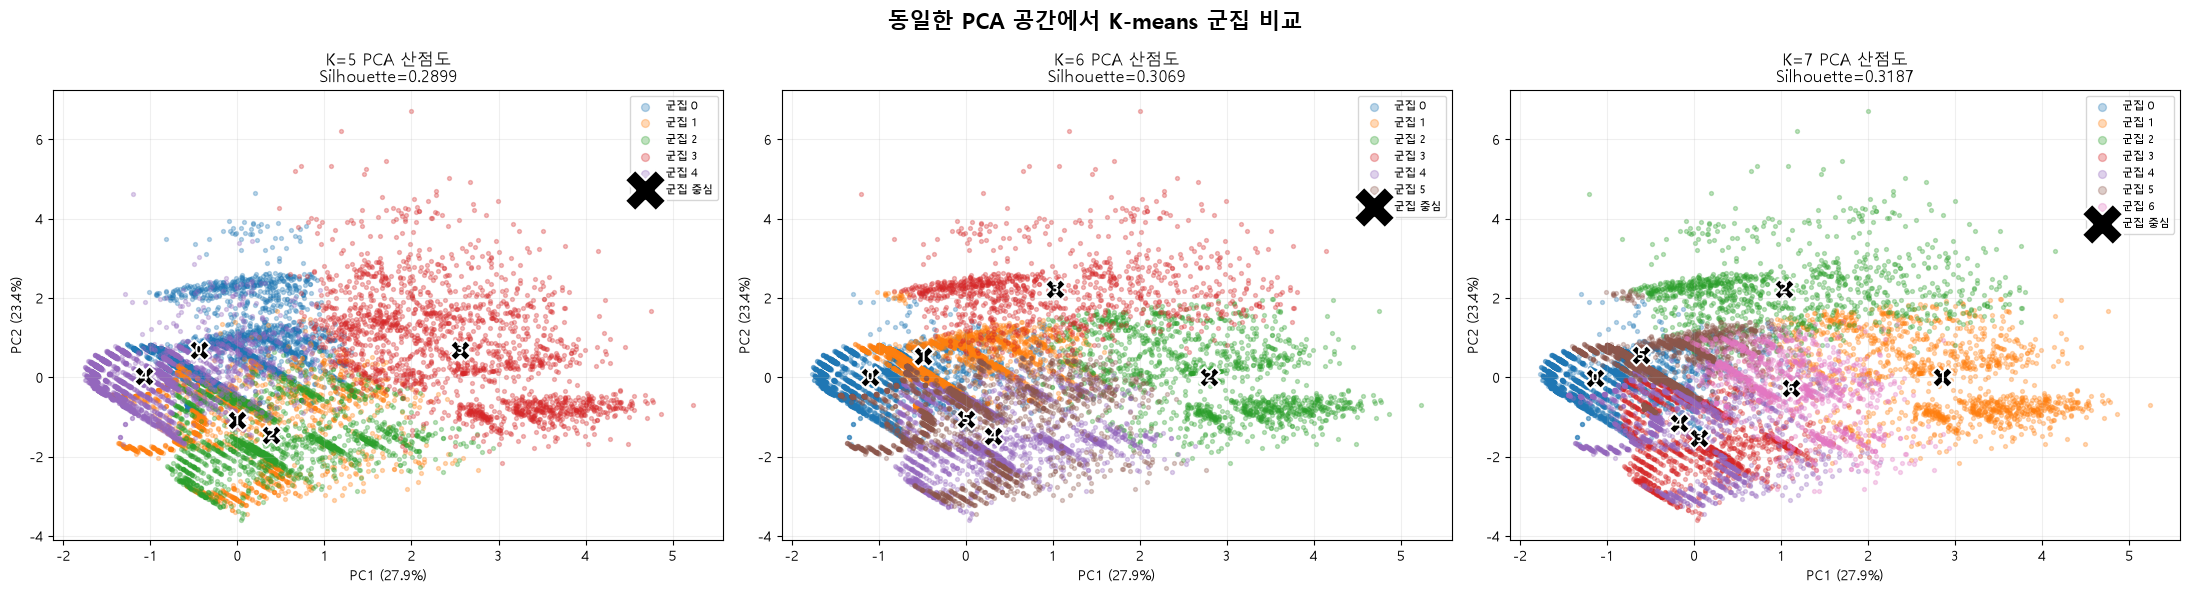

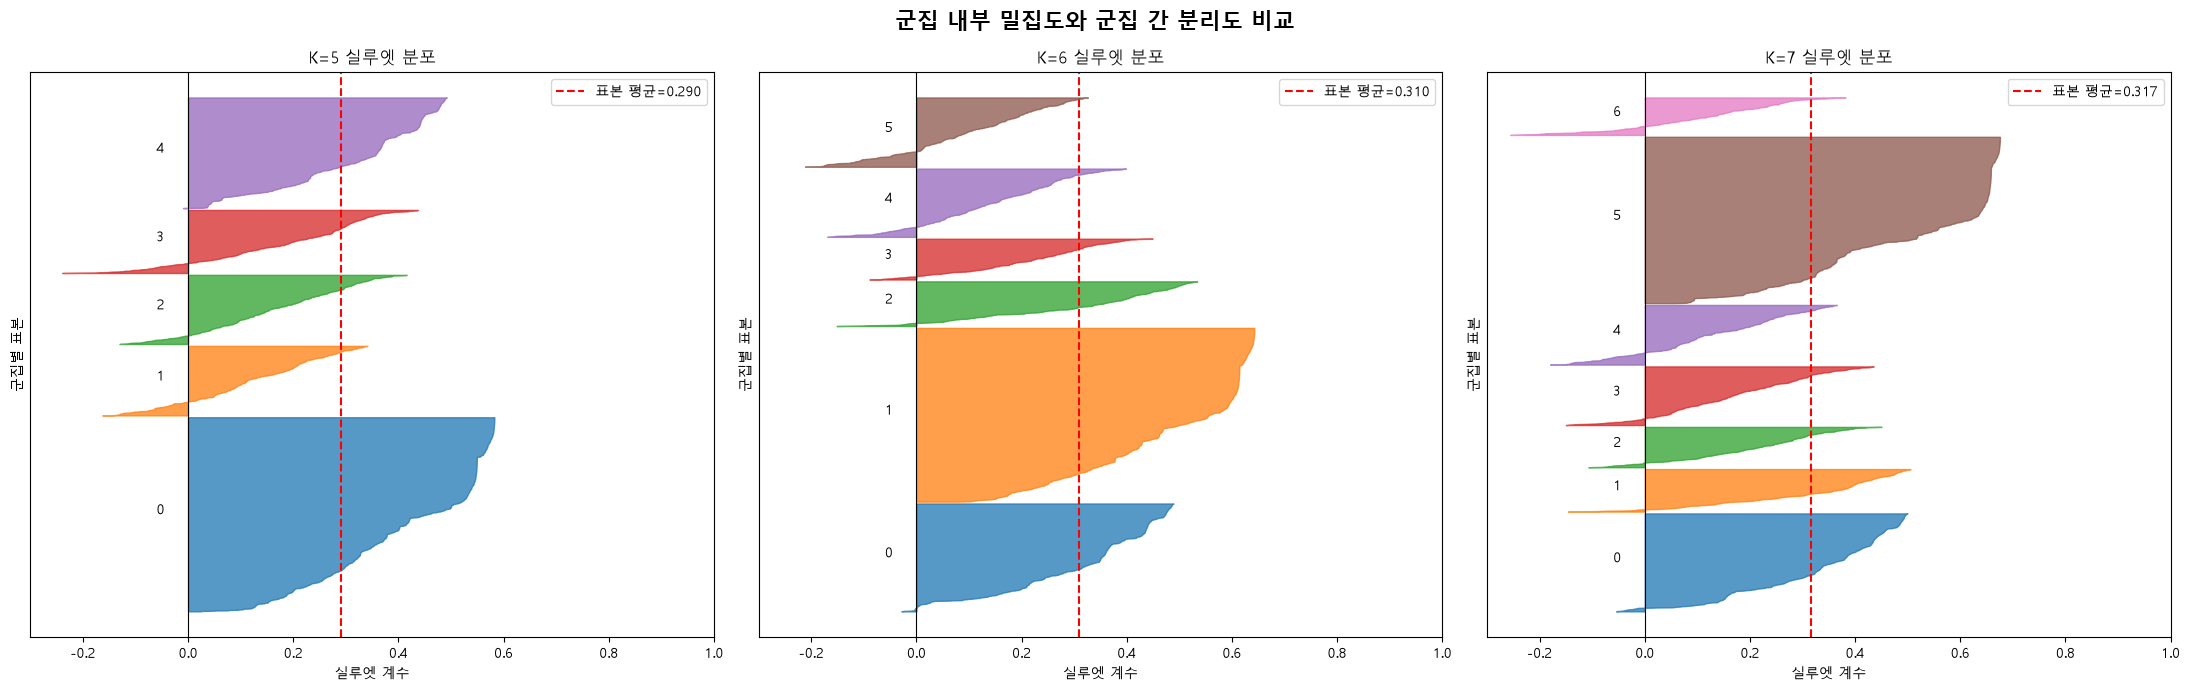

In [25]:
# ============================================================
# STEP 10. PCA 산점도와 실루엣 그래프로 K=5·6·7 비교
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples


VISUAL_K_VALUES = [5, 6, 7]


# ------------------------------------------------------------
# 1. 동일한 PCA 공간 생성
# ------------------------------------------------------------

pca = PCA(
    n_components=2,
    random_state=42
)

X_cluster_pca = pca.fit_transform(
    X_cluster_scaled
)

pc1_ratio = pca.explained_variance_ratio_[0]
pc2_ratio = pca.explained_variance_ratio_[1]
total_ratio = pc1_ratio + pc2_ratio

print("=" * 75)
print("PCA 설명력")
print("=" * 75)

print(f"PC1 설명력: {pc1_ratio:.2%}")
print(f"PC2 설명력: {pc2_ratio:.2%}")
print(f"2개 축 누적 설명력: {total_ratio:.2%}")


# ------------------------------------------------------------
# 2. K별 PCA 산점도
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 6)
)

color_map = plt.get_cmap("tab10")

for axis, k in zip(
    axes,
    VISUAL_K_VALUES
):

    model = kmeans_models[k]
    labels = model.labels_

    # 원래 6차원의 군집 중심을 동일한 PCA 공간으로 변환
    centroids_pca = pca.transform(
        model.cluster_centers_
    )

    for cluster_number in range(k):

        cluster_mask = (
            labels == cluster_number
        )

        axis.scatter(
            X_cluster_pca[
                cluster_mask,
                0
            ],
            X_cluster_pca[
                cluster_mask,
                1
            ],
            s=8,
            alpha=0.30,
            color=color_map(
                cluster_number
            ),
            label=f"군집 {cluster_number}"
        )

    # 군집 중심
    axis.scatter(
        centroids_pca[:, 0],
        centroids_pca[:, 1],
        s=220,
        marker="X",
        color="black",
        edgecolor="white",
        linewidth=1.5,
        label="군집 중심"
    )

    for cluster_number, center in enumerate(
        centroids_pca
    ):
        axis.text(
            center[0],
            center[1],
            str(cluster_number),
            fontsize=11,
            fontweight="bold",
            ha="center",
            va="center",
            color="white"
        )

    silhouette_value = (
        cluster_selection_df.loc[
            cluster_selection_df["k"] == k,
            "silhouette"
        ].iloc[0]
    )

    axis.set_title(
        f"K={k} PCA 산점도\n"
        f"Silhouette={silhouette_value:.4f}"
    )

    axis.set_xlabel(
        f"PC1 ({pc1_ratio:.1%})"
    )

    axis.set_ylabel(
        f"PC2 ({pc2_ratio:.1%})"
    )

    axis.grid(alpha=0.2)

    axis.legend(
        fontsize=8,
        loc="best",
        markerscale=2
    )

plt.suptitle(
    "동일한 PCA 공간에서 K-means 군집 비교",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. 실루엣 그래프용 동일 표본 추출
# - 노트북 메모리를 고려해 3,000건 사용
# ------------------------------------------------------------

rng = np.random.default_rng(42)

silhouette_sample_size = min(
    3000,
    len(X_cluster_scaled)
)

sample_indices = rng.choice(
    len(X_cluster_scaled),
    size=silhouette_sample_size,
    replace=False
)

X_silhouette_sample = (
    X_cluster_scaled[
        sample_indices
    ]
)


# ------------------------------------------------------------
# 4. K별 실루엣 그래프
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 7)
)

for axis, k in zip(
    axes,
    VISUAL_K_VALUES
):

    labels_sample = (
        kmeans_models[k]
        .labels_[sample_indices]
    )

    silhouette_values = (
        silhouette_samples(
            X_silhouette_sample,
            labels_sample
        )
    )

    average_silhouette = (
        silhouette_values.mean()
    )

    y_lower = 10

    for cluster_number in range(k):

        cluster_silhouette_values = (
            silhouette_values[
                labels_sample
                == cluster_number
            ]
        )

        cluster_silhouette_values.sort()

        cluster_size = len(
            cluster_silhouette_values
        )

        y_upper = (
            y_lower + cluster_size
        )

        axis.fill_betweenx(
            np.arange(
                y_lower,
                y_upper
            ),
            0,
            cluster_silhouette_values,
            facecolor=color_map(
                cluster_number
            ),
            edgecolor=color_map(
                cluster_number
            ),
            alpha=0.75
        )

        axis.text(
            -0.06,
            y_lower
            + 0.5 * cluster_size,
            str(cluster_number)
        )

        y_lower = y_upper + 10

    axis.axvline(
        average_silhouette,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=(
            f"표본 평균="
            f"{average_silhouette:.3f}"
        )
    )

    axis.axvline(
        0,
        color="black",
        linewidth=0.8
    )

    axis.set_title(
        f"K={k} 실루엣 분포"
    )

    axis.set_xlabel(
        "실루엣 계수"
    )

    axis.set_ylabel(
        "군집별 표본"
    )

    axis.set_xlim(
        -0.3,
        1.0
    )

    axis.set_yticks([])
    axis.legend()

plt.suptitle(
    "군집 내부 밀집도와 군집 간 분리도 비교",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
## 그냥 민정 개인 확인용

print(
    oof_top4_df["y_probability"]
    .describe()
)

print(
    "0.01 미만 거래:",
    int(
        (
            oof_top4_df["y_probability"]
            < 0.01
        ).sum()
    )
)

display(
    pd.crosstab(
        oof_top4_df["risk_grade"],
        oof_top4_df["y_probability"] < 0.01
    )
)

count    14554.000000
mean         0.342293
std          0.413917
min          0.010004
25%          0.021872
50%          0.073477
75%          0.909725
max          1.000000
Name: y_probability, dtype: float64
0.01 미만 거래: 0


y_probability,False
risk_grade,
관심,895
관찰,10064
긴급,3240
위험,355


< 정리 >

현재 결과를 종합하면 K=7이 가장 적절해 보여. 단순히 지표가 좋아서가 아니라, K=5·6보다 실제 거래 행동을 의미 있게 세분화했어.

K별 비교
K=5: 고위험 행동들이 하나의 군집에 섞여 있음
군집 3에 고액·최근 누적·반복거래·고속 이동이 함께 포함
K=6: 누적 고액형과 고속 연속거래형이 분리돼 해석력이 좋아짐
K=7: 고위험 거래가 세 가지로 더 명확하게 구분됨
1시간 누적·고액 반복형
30분 다회·고속 이동형
최근 24시간 고액 반복형

K=7은 실루엣 0.3187, DB 1.1932, 평균 ARI 0.9984로 수치도 가장 좋아. 추가된 군집도 단순히 잘게 나눈 것이 아니라 행동 특성이 달라서 K=7을 잠정 최종안으로 추천해.


다음에 해야 할 분석

1. 각 거래에 K=7 군집명 저장
2. 군집별 TP·TN·FP·FN 비율 비교
3. 같은 군집 안에서 TP vs FN, TN vs FP 변수 차이 비교
4. FN 215건 중 미탐 원인을 유형별로 분석
5. 일반 등급에 포함된 사기 30건 별도 분석 <- 여기까지만.
6. 대표 사례 선정
- 가장 낮은 확률을 받은 FN
- 임계값 바로 아래 FN
- 가장 높은 확률을 받은 FP
- 임계값 바로 위 FP
7. 최종 Test에서는 설정을 바꾸지 않고 동일한 유형과 오류 경향만 검증

In [27]:
# ============================================================
# STEP 11. K=7 최종 군집번호·유형명 확정 및 저장
# ============================================================

from pathlib import Path
import joblib
import pandas as pd


# ------------------------------------------------------------
# 1. 최종 K-means 모델
# ------------------------------------------------------------

FINAL_K = 7

final_kmeans_model = kmeans_models[FINAL_K]


# ------------------------------------------------------------
# 2. 군집 유형명
# ------------------------------------------------------------

CLUSTER_NAME_MAP = {
    0: "주간 소액·평소거래형",
    1: "심야 고액·단시간 누적형",
    2: "심야 초단기 다회·고속이동형",
    3: "단발성 초고액 이탈형",
    4: "중간금액·완만 이탈형",
    5: "심야 소액·평소거래형",
    6: "심야 고액 반복형"
}


# ------------------------------------------------------------
# 3. 최종 데이터에 군집번호와 유형명 추가
# ------------------------------------------------------------

final_clustered_oof_df = (
    cluster_model_base_df
    .copy()
    .reset_index(drop=True)
)

final_clustered_oof_df[
    "cluster_id"
] = final_kmeans_model.labels_

final_clustered_oof_df[
    "cluster_type"
] = (
    final_clustered_oof_df[
        "cluster_id"
    ]
    .map(CLUSTER_NAME_MAP)
)


# ------------------------------------------------------------
# 4. 결과 검증
# ------------------------------------------------------------

if final_clustered_oof_df[
    "cluster_type"
].isna().any():
    raise ValueError(
        "유형명이 연결되지 않은 군집이 있습니다."
    )

cluster_count_check = (
    final_clustered_oof_df
    .groupby(
        ["cluster_id", "cluster_type"],
        observed=True
    )
    .size()
    .reset_index(name="transactions")
)

cluster_count_check[
    "transaction_share"
] = (
    cluster_count_check["transactions"]
    / len(final_clustered_oof_df)
)


print("=" * 90)
print("K=7 최종 군집 유형 확정")
print("=" * 90)

display(
    cluster_count_check.style.format({
        "transaction_share": "{:.2%}"
    })
)

print(
    "전체 군집 거래:",
    f"{len(final_clustered_oof_df):,}건"
)

print(
    "군집 개수:",
    final_clustered_oof_df[
        "cluster_id"
    ].nunique()
)


# ------------------------------------------------------------
# 5. CSV 저장
# ------------------------------------------------------------

CLUSTER_DATA_PATH = Path(
    r"C:\Users\splen\OneDrive\Desktop\BDAI_"
    r"\BOOSTMAP\Fraud-FDS-Project\data"
    r"\lightGBM_combination3_OOF_top4_K7_clustered.csv"
)

final_clustered_oof_df.to_csv(
    CLUSTER_DATA_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 6. K-means 모델과 전처리 설정 저장
# ------------------------------------------------------------

CLUSTER_MODEL_PATH = Path(
    r"C:\Users\splen\OneDrive\Desktop\BDAI_"
    r"\BOOSTMAP\Fraud-FDS-Project\data"
    r"\lightGBM_combination3_K7_cluster_model.joblib"
)

cluster_model_package = {
    "scaler": cluster_scaler,
    "kmeans": final_kmeans_model,
    "final_k": FINAL_K,
    "cluster_features": FINAL_CLUSTER_FEATURES,
    "cluster_name_map": CLUSTER_NAME_MAP,
    "ratio_median": RATIO_MEDIAN,

    "preprocessing": {
        "amt_to_prior_median_ratio":
            "median imputation + log1p",

        "rolling_sum_amt_1h":
            "log1p(max(rolling_sum_amt_1h - amt, 0))",

        "recent_24h_high_amt_count":
            "log1p",

        "count_30min":
            "original value",

        "trans_hour":
            "sin and cos transformation"
    },

    "training_scope":
        "Train OOF predicted probability >= 0.01",

    "random_state": 42
}

joblib.dump(
    cluster_model_package,
    CLUSTER_MODEL_PATH
)


print("\n✅ 군집 결과 CSV 저장 완료")
print("CSV:", CLUSTER_DATA_PATH)

print("\n✅ 군집 모델·전처리 설정 저장 완료")
print("모델:", CLUSTER_MODEL_PATH)

print(
    "\n※ 두 파일은 대용량 데이터·모델 파일이므로 "
    "GitHub에는 아직 올리지 않습니다."
)

K=7 최종 군집 유형 확정


,cluster_id,cluster_type,transactions,transaction_share
0,0,주간 소액·평소거래형,2726,18.73%
1,1,심야 고액·단시간 누적형,1320,9.07%
2,2,심야 초단기 다회·고속이동형,1110,7.63%
3,3,단발성 초고액 이탈형,1701,11.69%
4,4,중간금액·완만 이탈형,1828,12.56%
5,5,심야 소액·평소거래형,4717,32.41%
6,6,심야 고액 반복형,1152,7.92%


전체 군집 거래: 14,554건
군집 개수: 7

✅ 군집 결과 CSV 저장 완료
CSV: C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP\Fraud-FDS-Project\data\lightGBM_combination3_OOF_top4_K7_clustered.csv

✅ 군집 모델·전처리 설정 저장 완료
모델: C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP\Fraud-FDS-Project\data\lightGBM_combination3_K7_cluster_model.joblib

※ 두 파일은 대용량 데이터·모델 파일이므로 GitHub에는 아직 올리지 않습니다.


K=7 군집별 TP·TN·FP·FN 및 성능


,cluster_id,cluster_type,transactions,TN,FP,FN,TP,actual_fraud,fraud_rate,precision,recall,specificity,false_positive_rate,false_negative_rate,cluster_error_rate,all_fp_share,all_fn_share
0,0,주간 소액·평소거래형,2726,2622,5,28,71,99,3.63%,93.42%,71.72%,99.81%,0.19%,28.28%,1.21%,3.11%,13.02%
1,1,심야 고액·단시간 누적형,1320,235,14,14,1057,1071,81.14%,98.69%,98.69%,94.38%,5.62%,1.31%,2.12%,8.70%,6.51%
2,2,심야 초단기 다회·고속이동형,1110,695,7,23,385,408,36.76%,98.21%,94.36%,99.00%,1.00%,5.64%,2.70%,4.35%,10.70%
3,3,단발성 초고액 이탈형,1701,1231,43,29,398,427,25.10%,90.25%,93.21%,96.62%,3.38%,6.79%,4.23%,26.71%,13.49%
4,4,중간금액·완만 이탈형,1828,1344,35,38,411,449,24.56%,92.15%,91.54%,97.46%,2.54%,8.46%,3.99%,21.74%,17.67%
5,5,심야 소액·평소거래형,4717,4365,38,68,246,314,6.66%,86.62%,78.34%,99.14%,0.86%,21.66%,2.25%,23.60%,31.63%
6,6,심야 고액 반복형,1152,252,19,15,866,881,76.48%,97.85%,98.30%,92.99%,7.01%,1.70%,2.95%,11.80%,6.98%



[군집 내부 TP·TN·FP·FN 구성비]


confusion_type,TN,FP,FN,TP
cluster_type,,,,
단발성 초고액 이탈형,72.37%,2.53%,1.70%,23.40%
심야 고액 반복형,21.88%,1.65%,1.30%,75.17%
심야 고액·단시간 누적형,17.80%,1.06%,1.06%,80.08%
심야 소액·평소거래형,92.54%,0.81%,1.44%,5.22%
심야 초단기 다회·고속이동형,62.61%,0.63%,2.07%,34.68%
주간 소액·평소거래형,96.18%,0.18%,1.03%,2.60%
중간금액·완만 이탈형,73.52%,1.91%,2.08%,22.48%


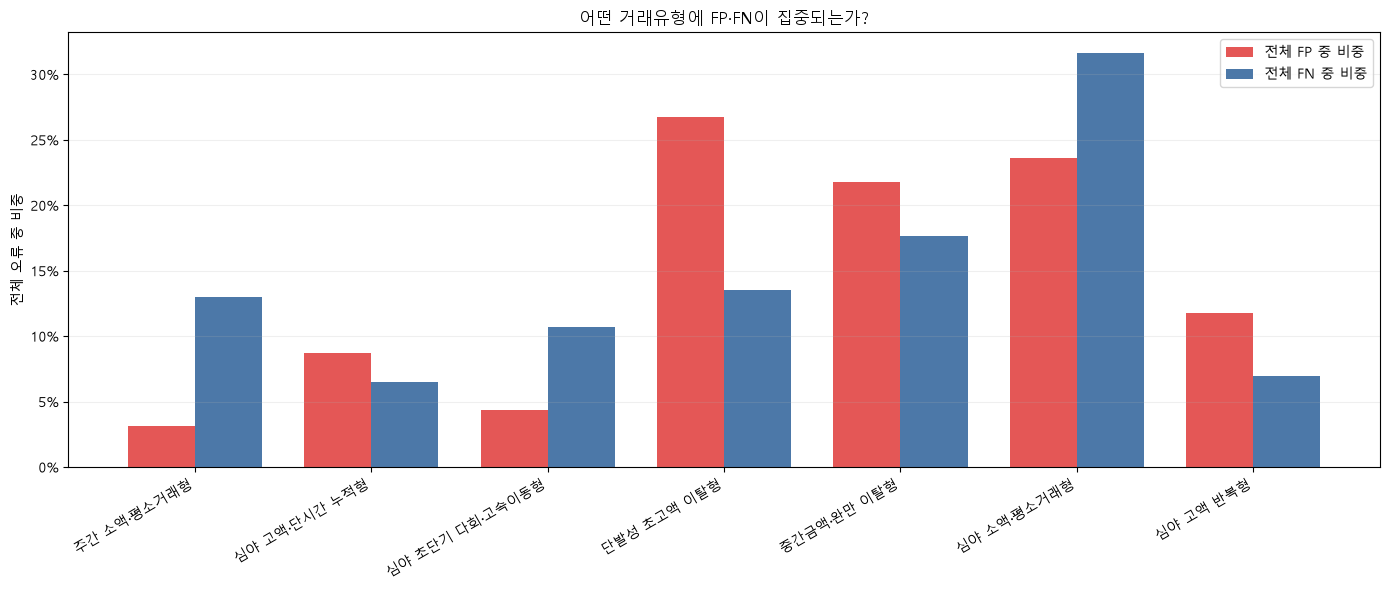


✅ 군집별 성능 결과 저장 완료
파일: C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP\Fraud-FDS-Project\data\K7_cluster_confusion_performance.csv


In [28]:
# ============================================================
# STEP 12. K=7 군집별 TP·TN·FP·FN 비교
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. 군집별 성능지표 계산
# ------------------------------------------------------------

cluster_performance_rows = []

total_fp = int(
    (
        final_clustered_oof_df[
            "confusion_type"
        ] == "FP"
    ).sum()
)

total_fn = int(
    (
        final_clustered_oof_df[
            "confusion_type"
        ] == "FN"
    ).sum()
)


for (
    cluster_id,
    cluster_type
), group in final_clustered_oof_df.groupby(
    ["cluster_id", "cluster_type"],
    observed=True
):

    confusion_counts = (
        group["confusion_type"]
        .value_counts()
    )

    tn = int(confusion_counts.get("TN", 0))
    fp = int(confusion_counts.get("FP", 0))
    fn = int(confusion_counts.get("FN", 0))
    tp = int(confusion_counts.get("TP", 0))

    actual_normal = tn + fp
    actual_fraud = tp + fn
    predicted_fraud = tp + fp

    cluster_performance_rows.append({
        "cluster_id": cluster_id,
        "cluster_type": cluster_type,
        "transactions": len(group),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,

        "actual_fraud": actual_fraud,
        "fraud_rate":
            actual_fraud / len(group),

        "precision":
            tp / predicted_fraud
            if predicted_fraud > 0
            else np.nan,

        "recall":
            tp / actual_fraud
            if actual_fraud > 0
            else np.nan,

        "specificity":
            tn / actual_normal
            if actual_normal > 0
            else np.nan,

        "false_positive_rate":
            fp / actual_normal
            if actual_normal > 0
            else np.nan,

        "false_negative_rate":
            fn / actual_fraud
            if actual_fraud > 0
            else np.nan,

        "cluster_error_rate":
            (fp + fn) / len(group),

        "all_fp_share":
            fp / total_fp
            if total_fp > 0
            else np.nan,

        "all_fn_share":
            fn / total_fn
            if total_fn > 0
            else np.nan
    })


cluster_performance_final_df = (
    pd.DataFrame(
        cluster_performance_rows
    )
    .sort_values("cluster_id")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 2. 전체 결과
# ------------------------------------------------------------

print("=" * 110)
print("K=7 군집별 TP·TN·FP·FN 및 성능")
print("=" * 110)

display(
    cluster_performance_final_df
    .style.format({
        "fraud_rate": "{:.2%}",
        "precision": "{:.2%}",
        "recall": "{:.2%}",
        "specificity": "{:.2%}",
        "false_positive_rate": "{:.2%}",
        "false_negative_rate": "{:.2%}",
        "cluster_error_rate": "{:.2%}",
        "all_fp_share": "{:.2%}",
        "all_fn_share": "{:.2%}"
    })
)


# ------------------------------------------------------------
# 3. 군집 내부 TP·TN·FP·FN 구성비
# ------------------------------------------------------------

confusion_count_table = pd.crosstab(
    final_clustered_oof_df[
        "cluster_type"
    ],
    final_clustered_oof_df[
        "confusion_type"
    ]
).reindex(
    columns=["TN", "FP", "FN", "TP"],
    fill_value=0
)

confusion_ratio_table = (
    confusion_count_table
    .div(
        confusion_count_table.sum(axis=1),
        axis=0
    )
)

print("\n[군집 내부 TP·TN·FP·FN 구성비]")

display(
    confusion_ratio_table.style.format(
        "{:.2%}"
    )
)


# ------------------------------------------------------------
# 4. 오류 집중도 시각화
# ------------------------------------------------------------

plot_df = (
    cluster_performance_final_df
    .sort_values("cluster_id")
)

x_positions = np.arange(
    len(plot_df)
)

bar_width = 0.38

fig, axis = plt.subplots(
    figsize=(14, 6)
)

axis.bar(
    x_positions - bar_width / 2,
    plot_df["all_fp_share"],
    width=bar_width,
    label="전체 FP 중 비중",
    color="#E45756"
)

axis.bar(
    x_positions + bar_width / 2,
    plot_df["all_fn_share"],
    width=bar_width,
    label="전체 FN 중 비중",
    color="#4C78A8"
)

axis.set_xticks(x_positions)

axis.set_xticklabels(
    plot_df["cluster_type"],
    rotation=30,
    ha="right"
)

axis.set_ylabel("전체 오류 중 비중")
axis.set_title(
    "어떤 거래유형에 FP·FN이 집중되는가?"
)

axis.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position:
        f"{value:.0%}"
    )
)

axis.grid(
    axis="y",
    alpha=0.2
)

axis.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. 결과 저장
# ------------------------------------------------------------

PERFORMANCE_SAVE_PATH = Path(
    r"C:\Users\splen\OneDrive\Desktop\BDAI_"
    r"\BOOSTMAP\Fraud-FDS-Project\data"
    r"\K7_cluster_confusion_performance.csv"
)

cluster_performance_final_df.to_csv(
    PERFORMANCE_SAVE_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ 군집별 성능 결과 저장 완료")
print("파일:", PERFORMANCE_SAVE_PATH)

다홍 : 전체 미탐(사기놓침) 중 해당 거래유형(군집)이 차지하는 비중
파랑 : 전체 오탐(정상을 사기로 탐지) 중 해당 유형이 차지하는 비중

In [29]:
# ============================================================
# STEP 13. 동일 군집 내부 TP-FN, TN-FP 변수 차이
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


error_analysis_df = (
    final_clustered_oof_df
    .copy()
)


# ------------------------------------------------------------
# 1. 비교용 파생변수
# ------------------------------------------------------------

error_analysis_df["is_night"] = (
    error_analysis_df["trans_hour"]
    .isin([22, 23, 0, 1, 2, 3, 4])
).astype(np.int8)

error_analysis_df["amt_log_profile"] = np.log1p(
    error_analysis_df["amt"]
)

error_analysis_df[
    "zscore_signed_log"
] = (
    np.sign(
        error_analysis_df["amt_zscore_card"]
    )
    * np.log1p(
        np.abs(
            error_analysis_df[
                "amt_zscore_card"
            ]
        )
    )
)

error_analysis_df[
    "prior_normal_median_amt_imputed"
] = (
    error_analysis_df[
        "prior_normal_median_amt"
    ].fillna(
        error_analysis_df[
            "prior_normal_median_amt"
        ].median()
    )
)

error_analysis_df[
    "prior_normal_median_amt_log"
] = np.log1p(
    error_analysis_df[
        "prior_normal_median_amt_imputed"
    ]
)


# ------------------------------------------------------------
# 2. 연속·횟수형 변수 설정
# - 효과크기는 변환값으로 계산
# - 결과 해석은 원래 단위 중앙값으로 표시
# ------------------------------------------------------------

CONTINUOUS_FEATURES = {
    "현재 거래금액": (
        "amt_log_profile",
        "amt"
    ),

    "평소 대비 금액비율": (
        "amt_to_prior_median_ratio_log",
        "amt_to_prior_median_ratio"
    ),

    "직전 1시간 누적금액": (
        "prior_1h_sum_amt_log",
        "prior_1h_sum_amt"
    ),

    "최근 24시간 고액횟수": (
        "recent_24h_high_amt_count_log",
        "recent_24h_high_amt_count"
    ),

    "금액 Z-score": (
        "zscore_signed_log",
        "amt_zscore_card"
    ),

    "최근 30분 거래횟수": (
        "count_30min",
        "count_30min"
    ),

    "연령": (
        "age",
        "age"
    ),

    "과거 정상거래 중앙값": (
        "prior_normal_median_amt_log",
        "prior_normal_median_amt"
    )
}

BINARY_FEATURES = {
    "심야거래 여부":
        "is_night",

    "고속이동 여부":
        "high_speed",

    "과거 정상거래 이력 없음":
        "prior_history_missing"
}


# ------------------------------------------------------------
# 3. 표준화 평균차 계산 함수
# ------------------------------------------------------------

def standardized_mean_difference(
    correct_values,
    error_values
):

    correct_values = (
        pd.to_numeric(
            correct_values,
            errors="coerce"
        ).dropna()
    )

    error_values = (
        pd.to_numeric(
            error_values,
            errors="coerce"
        ).dropna()
    )

    if (
        len(correct_values) < 2
        or len(error_values) < 2
    ):
        return np.nan

    pooled_variance = (
        (
            (len(correct_values) - 1)
            * correct_values.var(ddof=1)
        )
        +
        (
            (len(error_values) - 1)
            * error_values.var(ddof=1)
        )
    ) / (
        len(correct_values)
        + len(error_values)
        - 2
    )

    if pooled_variance <= 0:
        return 0.0

    pooled_sd = np.sqrt(
        pooled_variance
    )

    return (
        error_values.mean()
        - correct_values.mean()
    ) / pooled_sd


# ------------------------------------------------------------
# 4. TP-FN, TN-FP 비교
# ------------------------------------------------------------

COMPARISONS = [
    {
        "comparison": "TP 대비 FN",
        "correct_group": "TP",
        "error_group": "FN"
    },
    {
        "comparison": "TN 대비 FP",
        "correct_group": "TN",
        "error_group": "FP"
    }
]

continuous_rows = []
binary_rows = []
category_rows = []


for cluster_id, cluster_df in (
    error_analysis_df.groupby(
        "cluster_id"
    )
):

    cluster_type = (
        cluster_df[
            "cluster_type"
        ].iloc[0]
    )

    for comparison_info in COMPARISONS:

        correct_name = (
            comparison_info[
                "correct_group"
            ]
        )

        error_name = (
            comparison_info[
                "error_group"
            ]
        )

        correct_df = cluster_df[
            cluster_df["confusion_type"]
            == correct_name
        ]

        error_df = cluster_df[
            cluster_df["confusion_type"]
            == error_name
        ]

        # 연속·횟수형 변수
        for feature_name, (
            effect_column,
            raw_column
        ) in CONTINUOUS_FEATURES.items():

            effect_size = (
                standardized_mean_difference(
                    correct_df[effect_column],
                    error_df[effect_column]
                )
            )

            continuous_rows.append({
                "cluster_id": cluster_id,
                "cluster_type": cluster_type,
                "comparison":
                    comparison_info[
                        "comparison"
                    ],

                "variable": feature_name,
                "correct_group": correct_name,
                "error_group": error_name,

                "correct_count":
                    len(correct_df),

                "error_count":
                    len(error_df),

                "correct_median":
                    correct_df[
                        raw_column
                    ].median(),

                "error_median":
                    error_df[
                        raw_column
                    ].median(),

                "standardized_difference":
                    effect_size,

                "absolute_difference":
                    abs(effect_size)
                    if pd.notna(effect_size)
                    else np.nan
            })

        # 이진변수
        for feature_name, column in (
            BINARY_FEATURES.items()
        ):

            correct_rate = (
                correct_df[column].mean()
            )

            error_rate = (
                error_df[column].mean()
            )

            binary_rows.append({
                "cluster_id": cluster_id,
                "cluster_type": cluster_type,
                "comparison":
                    comparison_info[
                        "comparison"
                    ],

                "variable": feature_name,
                "correct_group": correct_name,
                "error_group": error_name,

                "correct_rate":
                    correct_rate,

                "error_rate":
                    error_rate,

                "rate_difference":
                    error_rate
                    - correct_rate
            })

        # category 구성비 차이
        correct_category_share = (
            correct_df["category"]
            .astype("string")
            .value_counts(
                normalize=True
            )
        )

        error_category_share = (
            error_df["category"]
            .astype("string")
            .value_counts(
                normalize=True
            )
        )

        category_values = (
            correct_category_share.index
            .union(
                error_category_share.index
            )
        )

        for category_value in category_values:

            correct_share = float(
                correct_category_share.get(
                    category_value,
                    0
                )
            )

            error_share = float(
                error_category_share.get(
                    category_value,
                    0
                )
            )

            category_rows.append({
                "cluster_id": cluster_id,
                "cluster_type": cluster_type,
                "comparison":
                    comparison_info[
                        "comparison"
                    ],

                "category":
                    category_value,

                "correct_share":
                    correct_share,

                "error_share":
                    error_share,

                "share_difference":
                    error_share
                    - correct_share,

                "absolute_difference":
                    abs(
                        error_share
                        - correct_share
                    )
            })


continuous_error_difference_df = (
    pd.DataFrame(continuous_rows)
)

binary_error_difference_df = (
    pd.DataFrame(binary_rows)
)

category_error_difference_df = (
    pd.DataFrame(category_rows)
)


# ------------------------------------------------------------
# 5. 군집별 차이가 큰 변수 상위 3개
# ------------------------------------------------------------

top_continuous_differences_df = (
    continuous_error_difference_df
    .sort_values(
        "absolute_difference",
        ascending=False
    )
    .groupby(
        ["cluster_id", "comparison"],
        observed=True
    )
    .head(3)
    .sort_values(
        ["comparison", "cluster_id"]
    )
    .reset_index(drop=True)
)

print("=" * 115)
print("군집별 TP-FN, TN-FP 차이가 큰 수치형 변수 TOP 3")
print("=" * 115)

display(
    top_continuous_differences_df
    .style.format({
        "correct_median": "{:,.3f}",
        "error_median": "{:,.3f}",
        "standardized_difference": "{:+.3f}",
        "absolute_difference": "{:.3f}"
    })
)


print("\n[이진변수 비율 차이]")

display(
    binary_error_difference_df
    .style.format({
        "correct_rate": "{:.2%}",
        "error_rate": "{:.2%}",
        "rate_difference": "{:+.2%}"
    })
)


# category 차이가 큰 상위 3개
top_category_differences_df = (
    category_error_difference_df
    .sort_values(
        "absolute_difference",
        ascending=False
    )
    .groupby(
        ["cluster_id", "comparison"],
        observed=True
    )
    .head(3)
    .sort_values(
        ["comparison", "cluster_id"]
    )
    .reset_index(drop=True)
)

print("\n[업종 구성비 차이 TOP 3]")

display(
    top_category_differences_df
    .style.format({
        "correct_share": "{:.2%}",
        "error_share": "{:.2%}",
        "share_difference": "{:+.2%}",
        "absolute_difference": "{:.2%}"
    })
)


# ------------------------------------------------------------
# 6. 결과 저장
# ------------------------------------------------------------

SAVE_DIRECTORY = Path(
    r"C:\Users\splen\OneDrive\Desktop\BDAI_"
    r"\BOOSTMAP\Fraud-FDS-Project\data"
)

top_continuous_differences_df.to_csv(
    SAVE_DIRECTORY
    / "K7_TP_FN_TN_FP_numeric_differences.csv",
    index=False,
    encoding="utf-8-sig"
)

binary_error_difference_df.to_csv(
    SAVE_DIRECTORY
    / "K7_TP_FN_TN_FP_binary_differences.csv",
    index=False,
    encoding="utf-8-sig"
)

top_category_differences_df.to_csv(
    SAVE_DIRECTORY
    / "K7_TP_FN_TN_FP_category_differences.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ 동일 군집 내부 오류 차이 분석 저장 완료")

군집별 TP-FN, TN-FP 차이가 큰 수치형 변수 TOP 3


,cluster_id,cluster_type,comparison,variable,correct_group,error_group,correct_count,error_count,correct_median,error_median,standardized_difference,absolute_difference
0,0,주간 소액·평소거래형,TN 대비 FP,최근 24시간 고액횟수,TN,FP,2622,5,0.000,1.000,+1.859,1.859
1,0,주간 소액·평소거래형,TN 대비 FP,과거 정상거래 중앙값,TN,FP,2622,5,40.085,35.030,-0.960,0.960
2,0,주간 소액·평소거래형,TN 대비 FP,평소 대비 금액비율,TN,FP,2622,5,0.563,1.115,+0.386,0.386
3,1,심야 고액·단시간 누적형,TN 대비 FP,평소 대비 금액비율,TN,FP,235,14,1.963,15.467,+1.135,1.135
4,1,심야 고액·단시간 누적형,TN 대비 FP,금액 Z-score,TN,FP,235,14,0.065,3.039,+0.954,0.954
5,1,심야 고액·단시간 누적형,TN 대비 FP,현재 거래금액,TN,FP,235,14,82.430,542.815,+0.664,0.664
6,2,심야 초단기 다회·고속이동형,TN 대비 FP,최근 24시간 고액횟수,TN,FP,695,7,0.000,1.000,+1.042,1.042
7,2,심야 초단기 다회·고속이동형,TN 대비 FP,현재 거래금액,TN,FP,695,7,27.350,22.090,-0.413,0.413
8,2,심야 초단기 다회·고속이동형,TN 대비 FP,최근 30분 거래횟수,TN,FP,695,7,2.000,2.000,+0.412,0.412
9,3,단발성 초고액 이탈형,TN 대비 FP,최근 30분 거래횟수,TN,FP,1231,43,0.000,0.000,-0.775,0.775



[이진변수 비율 차이]


,cluster_id,cluster_type,comparison,variable,correct_group,error_group,correct_rate,error_rate,rate_difference
0,0,주간 소액·평소거래형,TP 대비 FN,심야거래 여부,TP,FN,0.00%,0.00%,+0.00%
1,0,주간 소액·평소거래형,TP 대비 FN,고속이동 여부,TP,FN,0.00%,3.57%,+3.57%
2,0,주간 소액·평소거래형,TP 대비 FN,과거 정상거래 이력 없음,TP,FN,39.44%,3.57%,-35.87%
3,0,주간 소액·평소거래형,TN 대비 FP,심야거래 여부,TN,FP,0.00%,0.00%,+0.00%
4,0,주간 소액·평소거래형,TN 대비 FP,고속이동 여부,TN,FP,6.03%,0.00%,-6.03%
5,0,주간 소액·평소거래형,TN 대비 FP,과거 정상거래 이력 없음,TN,FP,0.00%,0.00%,+0.00%
6,1,심야 고액·단시간 누적형,TP 대비 FN,심야거래 여부,TP,FN,98.39%,57.14%,-41.25%
7,1,심야 고액·단시간 누적형,TP 대비 FN,고속이동 여부,TP,FN,14.10%,14.29%,+0.19%
8,1,심야 고액·단시간 누적형,TP 대비 FN,과거 정상거래 이력 없음,TP,FN,11.07%,0.00%,-11.07%
9,1,심야 고액·단시간 누적형,TN 대비 FP,심야거래 여부,TN,FP,67.66%,78.57%,+10.91%



[업종 구성비 차이 TOP 3]


,cluster_id,cluster_type,comparison,category,correct_share,error_share,share_difference,absolute_difference
0,0,주간 소액·평소거래형,TN 대비 FP,gas_transport,0.15%,20.00%,+19.85%,19.85%
1,0,주간 소액·평소거래형,TN 대비 FP,health_fitness,16.67%,0.00%,-16.67%,16.67%
2,0,주간 소액·평소거래형,TN 대비 FP,home,7.97%,20.00%,+12.03%,12.03%
3,1,심야 고액·단시간 누적형,TN 대비 FP,misc_net,2.55%,28.57%,+26.02%,26.02%
4,1,심야 고액·단시간 누적형,TN 대비 FP,shopping_pos,5.53%,28.57%,+23.04%,23.04%
5,1,심야 고액·단시간 누적형,TN 대비 FP,food_dining,13.62%,0.00%,-13.62%,13.62%
6,2,심야 초단기 다회·고속이동형,TN 대비 FP,health_fitness,12.37%,42.86%,+30.48%,30.48%
7,2,심야 초단기 다회·고속이동형,TN 대비 FP,food_dining,14.53%,0.00%,-14.53%,14.53%
8,2,심야 초단기 다회·고속이동형,TN 대비 FP,gas_transport,0.43%,14.29%,+13.85%,13.85%
9,3,단발성 초고액 이탈형,TN 대비 FP,misc_net,11.13%,41.86%,+30.73%,30.73%



✅ 동일 군집 내부 오류 차이 분석 저장 완료


아래는 4번째 분석: 상위 4등급에 포함된 FN 215건의 미탐 원인 분석이야.

아래 코드를 새 셀 하나에 그대로 실행해줘. 이번 단계에서는 FN을 다음 기준으로 분석해.

- 어느 군집에서 많이 놓쳤는지
- 관심·관찰 등급 중 어디에 속하는지
- 임계값과 얼마나 떨어져 있는지
- 어떤 위험 신호가 부족했는지
- 자주 함께 나타나는 미탐 패턴은 무엇인지

상위 4등급 FN 분석
FN 거래 수: 215건
TP 거래 수: 3,434건

군집별 FN 분포


,cluster_id,cluster_type,fn_count,median_probability,median_amt,median_ratio,median_recent_high_count,median_prior_1h_sum,night_share,median_weak_signal_count,fn_share
5,5,심야 소액·평소거래형,68,0.3890,$19.95,0.43배,0.0,$0.00,89.71%,6.0,31.63%
4,4,중간금액·완만 이탈형,38,0.6058,$662.60,13.30배,0.0,$0.00,52.63%,4.0,17.67%
3,3,단발성 초고액 이탈형,29,0.7421,$883.82,20.78배,0.0,$0.00,48.28%,3.0,13.49%
0,0,주간 소액·평소거래형,28,0.4487,$20.97,0.63배,0.0,$0.00,0.00%,6.0,13.02%
2,2,심야 초단기 다회·고속이동형,23,0.7141,$22.10,0.62배,0.0,$40.37,91.30%,4.0,10.70%
6,6,심야 고액 반복형,15,0.8474,$20.17,0.64배,2.0,$0.00,46.67%,5.0,6.98%
1,1,심야 고액·단시간 누적형,14,0.5773,$35.82,0.90배,1.0,$852.61,57.14%,4.0,6.51%



위험등급별 FN


,risk_grade,fn_count,min_probability,median_probability,max_probability,fn_share
0,관심,122,0.502873,0.811376,0.925573,56.74%
1,관찰,93,0.012036,0.184178,0.493922,43.26%



[임계값과의 거리별 FN]


...

,miss_reason,fn_count,fn_share
6,과거 정상거래 이력 존재,212,98.60%
3,직전 1시간 누적거래 없음,170,79.07%
0,현재 거래금액 $300 미만,150,69.77%
5,금액 Z-score 2 미만,148,68.84%
1,평소 대비 금액 5배 미만,139,64.65%
2,최근 24시간 고액거래 없음,134,62.33%
4,심야시간 외 거래,84,39.07%



FN 미탐 원인 조합 TOP 15


,miss_reason_combination,fn_count,fn_share
0,현재 거래금액 $300 미만 + 평소 대비 금액 5배 미만 + 최근 24시간 고액거래 없음 + 직전 1시간 누적거래 없음 + 금액 Z-score 2 미만 + 과거 정상거래 이력 존재,37,17.21%
1,현재 거래금액 $300 미만 + 평소 대비 금액 5배 미만 + 직전 1시간 누적거래 없음 + 금액 Z-score 2 미만 + 과거 정상거래 이력 존재,29,13.49%
2,최근 24시간 고액거래 없음 + 직전 1시간 누적거래 없음 + 심야시간 외 거래 + 과거 정상거래 이력 존재,26,12.09%
3,최근 24시간 고액거래 없음 + 직전 1시간 누적거래 없음 + 과거 정상거래 이력 존재,24,11.16%
4,현재 거래금액 $300 미만 + 평소 대비 금액 5배 미만 + 직전 1시간 누적거래 없음 + 심야시간 외 거래 + 금액 Z-score 2 미만 + 과거 정상거래 이력 존재,22,10.23%
5,현재 거래금액 $300 미만 + 평소 대비 금액 5배 미만 + 최근 24시간 고액거래 없음 + 직전 1시간 누적거래 없음 + 심야시간 외 거래 + 금액 Z-score 2 미만 + 과거 정상거래 이력 존재,18,8.37%
6,현재 거래금액 $300 미만 + 평소 대비 금액 5배 미만 + 금액 Z-score 2 미만 + 과거 정상거래 이력 존재,16,7.44%
7,현재 거래금액 $300 미만 + 평소 대비 금액 5배 미만 + 최근 24시간 고액거래 없음 + 금액 Z-score 2 미만 + 과거 정상거래 이력 존재,12,5.58%
8,최근 24시간 고액거래 없음 + 과거 정상거래 이력 존재,5,2.33%
9,현재 거래금액 $300 미만 + 평소 대비 금액 5배 미만 + 심야시간 외 거래 + 금액 Z-score 2 미만 + 과거 정상거래 이력 존재,5,2.33%



군집별 FN 약한 위험 신호 비율


,cluster_id,cluster_type,현재 거래금액 $300 미만,평소 대비 금액 5배 미만,최근 24시간 고액거래 없음,직전 1시간 누적거래 없음,심야시간 외 거래,금액 Z-score 2 미만,과거 정상거래 이력 존재
0,0,주간 소액·평소거래형,89.29%,78.57%,53.57%,100.00%,100.00%,85.71%,96.43%
1,1,심야 고액·단시간 누적형,71.43%,71.43%,21.43%,0.00%,42.86%,71.43%,100.00%
2,2,심야 초단기 다회·고속이동형,86.96%,78.26%,65.22%,0.00%,8.70%,86.96%,100.00%
3,3,단발성 초고액 이탈형,0.00%,0.00%,93.10%,93.10%,51.72%,3.45%,100.00%
4,4,중간금액·완만 이탈형,39.47%,31.58%,94.74%,100.00%,47.37%,34.21%,97.37%
5,5,심야 소액·평소거래형,97.06%,92.65%,55.88%,94.12%,10.29%,97.06%,98.53%
6,6,심야 고액 반복형,93.33%,93.33%,0.00%,86.67%,53.33%,93.33%,100.00%


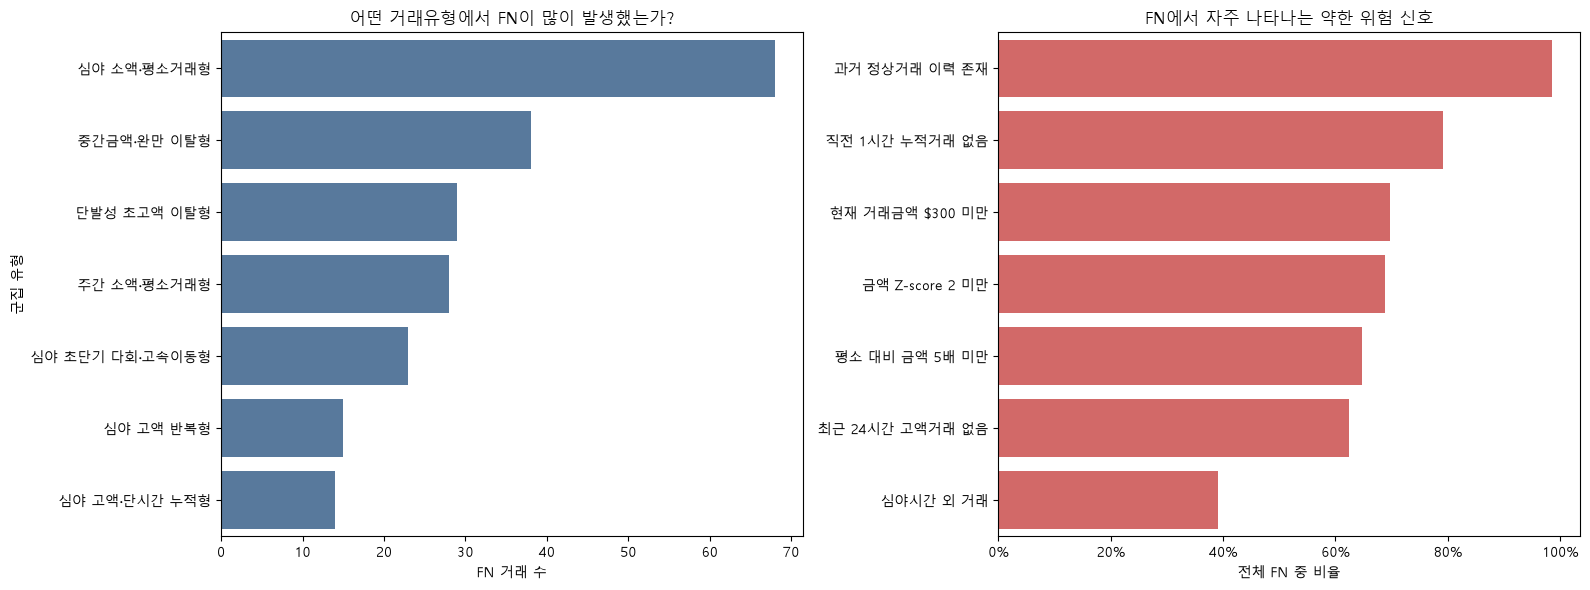


✅ 상위 4등급 FN 215건 분석 저장 완료


In [30]:
# ============================================================
# STEP 14. 상위 4등급 FN 215건 미탐 원인 분석
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# 1. 분석 데이터 준비
# ------------------------------------------------------------

fn_df = (
    final_clustered_oof_df
    .loc[final_clustered_oof_df["confusion_type"] == "FN"]
    .copy()
)

tp_df = (
    final_clustered_oof_df
    .loc[final_clustered_oof_df["confusion_type"] == "TP"]
    .copy()
)

print("=" * 90)
print("상위 4등급 FN 분석")
print("=" * 90)
print(f"FN 거래 수: {len(fn_df):,}건")
print(f"TP 거래 수: {len(tp_df):,}건")

assert len(fn_df) == 215, (
    f"예상 FN은 215건인데 현재 {len(fn_df):,}건입니다."
)


# ------------------------------------------------------------
# 2. 필요한 파생변수 생성
# ------------------------------------------------------------

for target_df in [fn_df, tp_df]:

    target_df["is_night"] = (
        (target_df["trans_hour"] >= 22)
        | (target_df["trans_hour"] <= 3)
    ).astype(int)

    # 현재 거래를 제외한 직전 1시간 누적금액
    if "prior_1h_sum_amt" not in target_df.columns:
        target_df["prior_1h_sum_amt"] = (
            target_df["rolling_sum_amt_1h"]
            - target_df["amt"]
        ).clip(lower=0)

    target_df["threshold_gap"] = (
        0.928939 - target_df["y_probability"]
    )

    # 임계값과의 거리
    target_df["threshold_distance_group"] = pd.cut(
        target_df["y_probability"],
        bins=[
            0.01,
            0.50,
            0.80,
            0.90,
            0.928939
        ],
        labels=[
            "관찰: 0.01~0.50",
            "관심 하단: 0.50~0.80",
            "관심 중단: 0.80~0.90",
            "임계값 근접: 0.90~0.928939"
        ],
        include_lowest=True,
        right=False
    )


# ------------------------------------------------------------
# 3. 미탐 원인 후보 플래그
# ------------------------------------------------------------

fn_df["signal_low_amount"] = (
    fn_df["amt"] < 300
)

fn_df["signal_normal_like_ratio"] = (
    fn_df["amt_to_prior_median_ratio"].fillna(np.inf) < 5
)

fn_df["signal_no_recent_high_amount"] = (
    fn_df["recent_24h_high_amt_count"] == 0
)

fn_df["signal_no_prior_1h_accumulation"] = (
    fn_df["prior_1h_sum_amt"] <= 0
)

fn_df["signal_not_night"] = (
    fn_df["is_night"] == 0
)

fn_df["signal_low_zscore"] = (
    fn_df["amt_zscore_card"] < 2
)

fn_df["signal_prior_history_exists"] = (
    fn_df["amt_to_prior_median_ratio"].notna()
)


reason_columns = {
    "signal_low_amount": "현재 거래금액 $300 미만",
    "signal_normal_like_ratio": "평소 대비 금액 5배 미만",
    "signal_no_recent_high_amount": "최근 24시간 고액거래 없음",
    "signal_no_prior_1h_accumulation": "직전 1시간 누적거래 없음",
    "signal_not_night": "심야시간 외 거래",
    "signal_low_zscore": "금액 Z-score 2 미만",
    "signal_prior_history_exists": "과거 정상거래 이력 존재"
}


# 거래별 약한 위험 신호 개수
fn_df["weak_signal_count"] = (
    fn_df[list(reason_columns.keys())]
    .sum(axis=1)
)


# ------------------------------------------------------------
# 4. 군집별 FN 분포
# ------------------------------------------------------------

cluster_fn_summary = (
    fn_df
    .groupby(
        ["cluster_id", "cluster_type"],
        observed=True
    )
    .agg(
        fn_count=("confusion_type", "size"),
        median_probability=("y_probability", "median"),
        median_amt=("amt", "median"),
        median_ratio=("amt_to_prior_median_ratio", "median"),
        median_recent_high_count=(
            "recent_24h_high_amt_count",
            "median"
        ),
        median_prior_1h_sum=(
            "prior_1h_sum_amt",
            "median"
        ),
        night_share=("is_night", "mean"),
        median_weak_signal_count=(
            "weak_signal_count",
            "median"
        )
    )
    .reset_index()
)

cluster_fn_summary["fn_share"] = (
    cluster_fn_summary["fn_count"]
    / len(fn_df)
)

cluster_fn_summary = (
    cluster_fn_summary
    .sort_values("fn_count", ascending=False)
)

print("\n" + "=" * 90)
print("군집별 FN 분포")
print("=" * 90)

display(
    cluster_fn_summary.style.format({
        "fn_share": "{:.2%}",
        "median_probability": "{:.4f}",
        "median_amt": "${:,.2f}",
        "median_ratio": "{:.2f}배",
        "median_recent_high_count": "{:.1f}",
        "median_prior_1h_sum": "${:,.2f}",
        "night_share": "{:.2%}",
        "median_weak_signal_count": "{:.1f}"
    })
)


# ------------------------------------------------------------
# 5. 위험등급·임계값 거리별 FN
# ------------------------------------------------------------

risk_grade_fn_summary = (
    fn_df
    .groupby("risk_grade", observed=True)
    .agg(
        fn_count=("confusion_type", "size"),
        min_probability=("y_probability", "min"),
        median_probability=("y_probability", "median"),
        max_probability=("y_probability", "max")
    )
    .reset_index()
)

risk_grade_fn_summary["fn_share"] = (
    risk_grade_fn_summary["fn_count"]
    / len(fn_df)
)

distance_fn_summary = (
    fn_df["threshold_distance_group"]
    .value_counts(sort=False, dropna=False)
    .rename_axis("probability_group")
    .reset_index(name="fn_count")
)

distance_fn_summary["fn_share"] = (
    distance_fn_summary["fn_count"]
    / len(fn_df)
)

print("\n" + "=" * 90)
print("위험등급별 FN")
print("=" * 90)

display(
    risk_grade_fn_summary.style.format({
        "fn_share": "{:.2%}",
        "min_probability": "{:.6f}",
        "median_probability": "{:.6f}",
        "max_probability": "{:.6f}"
    })
)

print("\n[임계값과의 거리별 FN]")

display(
    distance_fn_summary.style.format({
        "fn_share": "{:.2%}"
    })
)


# ------------------------------------------------------------
# 6. 미탐 원인 후보별 빈도
# ------------------------------------------------------------

reason_summary = []

for column, reason_name in reason_columns.items():

    count = int(fn_df[column].sum())

    reason_summary.append({
        "miss_reason": reason_name,
        "fn_count": count,
        "fn_share": count / len(fn_df)
    })

reason_summary = (
    pd.DataFrame(reason_summary)
    .sort_values("fn_count", ascending=False)
)

print("\n" + "=" * 90)
print("FN에서 나타난 약한 위험 신호")
print("=" * 90)

display(
    reason_summary.style.format({
        "fn_share": "{:.2%}"
    })
)


# ------------------------------------------------------------
# 7. 자주 함께 나타난 미탐 원인 조합
# ------------------------------------------------------------

def make_reason_combination(row):

    reasons = [
        reason_columns[column]
        for column in reason_columns
        if row[column]
    ]

    return " + ".join(reasons)


fn_df["miss_reason_combination"] = fn_df.apply(
    make_reason_combination,
    axis=1
)

reason_combination_summary = (
    fn_df["miss_reason_combination"]
    .value_counts()
    .head(15)
    .rename_axis("miss_reason_combination")
    .reset_index(name="fn_count")
)

reason_combination_summary["fn_share"] = (
    reason_combination_summary["fn_count"]
    / len(fn_df)
)

print("\n" + "=" * 90)
print("FN 미탐 원인 조합 TOP 15")
print("=" * 90)

display(
    reason_combination_summary.style.format({
        "fn_share": "{:.2%}"
    })
)


# ------------------------------------------------------------
# 8. 군집별 약한 신호 비율
# ------------------------------------------------------------

cluster_reason_summary = (
    fn_df
    .groupby(
        ["cluster_id", "cluster_type"],
        observed=True
    )[list(reason_columns.keys())]
    .mean()
    .reset_index()
    .rename(columns=reason_columns)
)

print("\n" + "=" * 90)
print("군집별 FN 약한 위험 신호 비율")
print("=" * 90)

display(
    cluster_reason_summary.style.format({
        column: "{:.2%}"
        for column in reason_columns.values()
    })
)


# ------------------------------------------------------------
# 9. 간단한 시각화
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

sns.barplot(
    data=cluster_fn_summary,
    x="fn_count",
    y="cluster_type",
    color="#4C78A8",
    ax=axes[0]
)

axes[0].set_title("어떤 거래유형에서 FN이 많이 발생했는가?")
axes[0].set_xlabel("FN 거래 수")
axes[0].set_ylabel("군집 유형")

sns.barplot(
    data=reason_summary,
    x="fn_share",
    y="miss_reason",
    color="#E45756",
    ax=axes[1]
)

axes[1].set_title("FN에서 자주 나타나는 약한 위험 신호")
axes[1].set_xlabel("전체 FN 중 비율")
axes[1].set_ylabel("")

axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, position: f"{x:.0%}"
    )
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. 결과 저장
# ------------------------------------------------------------

SAVE_DIR = Path(
    r"C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP"
    r"\Fraud-FDS-Project\data"
)

SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

fn_df.to_csv(
    SAVE_DIR / "K7_top4_false_negative_215_cases.csv",
    index=False,
    encoding="utf-8-sig"
)

cluster_fn_summary.to_csv(
    SAVE_DIR / "K7_top4_FN_cluster_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

reason_summary.to_csv(
    SAVE_DIR / "K7_top4_FN_reason_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

reason_combination_summary.to_csv(
    SAVE_DIR / "K7_top4_FN_reason_combinations.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ 상위 4등급 FN 215건 분석 저장 완료")

아래는 5번째 분석 : 일반 등급(예측확률 0~0.01)에 들어간 사기 30건 분석이야.

★ 이 30건은 모델이 사기인데도 거의 확실한 정상거래로 판단한 가장 심각한 미탐 사례야. 다음 내용을 확인하면 돼.

- 30건이 어느 K=7 군집에 속하는지
- 거래금액·ratio·시간·반복거래 등 위험 신호
- 상위 4등급 FN 215건과 무엇이 다른지
- 특정 업종이나 고객에게 집중됐는지
- 모델이 왜 1% 미만의 확률을 줬는지

✅ 기존 K=7 모델 불러오기 완료
군집 입력변수: ['amt_to_prior_median_ratio_log', 'prior_1h_sum_amt_log', 'recent_24h_high_amt_count_log', 'count_30min', 'trans_hour_sin', 'trans_hour_cos']

일반 등급 사기거래 추출
거래 수: 30건
예측확률 범위: 0.00000731 ~ 0.00960267

군집 입력 결측값: 0
군집 입력 무한대: 0

일반 등급 사기 30건의 K=7 유형 분포


,cluster_id,cluster_type,fraud_count,median_probability,median_amt,median_ratio,median_recent_high_count,median_prior_1h_sum,night_share,high_speed_share,history_missing_share,median_center_distance,fraud_share
0,0,주간 소액·평소거래형,12,0.00215824,$22.01,0.58배,0.0,$0.00,0.00%,0.00%,0.00%,1.031,40.00%
4,5,심야 소액·평소거래형,11,0.00172697,$14.13,0.32배,0.0,$0.00,90.91%,0.00%,0.00%,0.473,36.67%
1,2,심야 초단기 다회·고속이동형,4,0.00560541,$14.46,0.42배,0.0,$46.51,100.00%,100.00%,0.00%,1.722,13.33%
2,3,단발성 초고액 이탈형,2,0.00421029,$422.72,12.18배,0.0,$67.77,0.00%,50.00%,0.00%,1.919,6.67%
3,4,중간금액·완만 이탈형,1,0.00728965,$6.43,0.13배,0.0,$0.00,100.00%,0.00%,0.00%,1.558,3.33%



일반 등급 사기에서 나타난 약한 위험 신호


,weak_risk_signal,fraud_count,fraud_share
6,과거 정상거래 이력 존재,30,100.00%
2,최근 24시간 고액거래 없음,29,96.67%
0,현재 거래금액 $300 미만,29,96.67%
5,금액 Z-score 2 미만,29,96.67%
1,평소 대비 금액 5배 미만,27,90.00%
3,직전 1시간 누적거래 없음,25,83.33%
4,심야시간 외 거래,15,50.00%



[업종 분포]


,category,fraud_count,fraud_share
0,personal_care,7,23.33%
1,health_fitness,7,23.33%
2,kids_pets,6,20.00%
3,misc_pos,3,10.00%
4,travel,2,6.67%
5,food_dining,2,6.67%
6,home,2,6.67%
7,entertainment,1,3.33%



[시간대 분포]


,trans_hour,fraud_count
0,3,1
1,12,1
2,13,3
3,14,1
4,16,2
5,17,2
6,18,1
7,19,2
8,20,1
9,21,2



일반 등급 FN과 상위 4등급 FN 비교


,group,transactions,median_probability,median_amt,median_ratio,median_recent_high_count,median_prior_1h_sum,night_share,high_speed_share
0,일반 등급 FN 30건,30,0.002451,$19.93,0.42배,0.0,$0.00,50.00%,16.67%
1,상위 4등급 FN 215건,215,0.550647,$23.72,0.71배,0.0,$0.00,60.93%,14.88%


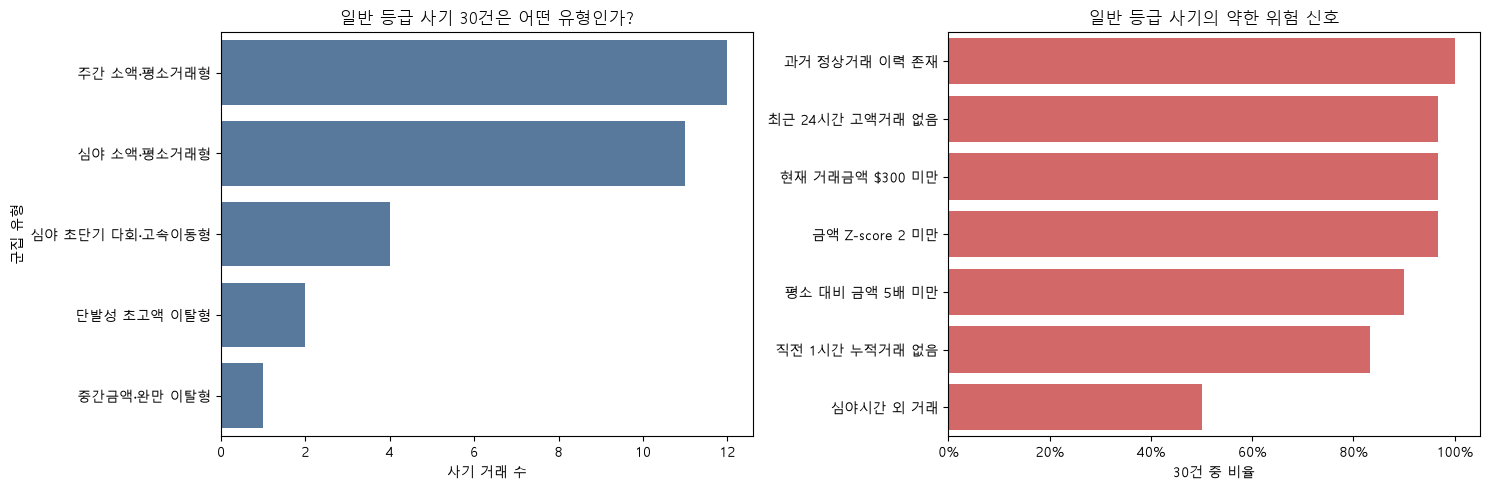


✅ 일반 등급 사기 30건 분석 저장 완료


In [31]:
## K=7 모델을 다시 학습하지 않고, 일반 등급 사기 30건을 기존 군집 중 가장 가까운 유형에 배정해 분석.

# ============================================================
# STEP 15. 일반 등급에 포함된 사기 30건 분석
# - 기존 K=7 모델을 그대로 적용
# ============================================================

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# 1. 전체 OOF 데이터 확인
# ------------------------------------------------------------

if "oof_analysis_df" not in globals():
    raise NameError(
        "oof_analysis_df가 없습니다.\n"
        "STEP 1의 OOF 예측과 원본 Train 변수 결합 셀을 "
        "먼저 실행해주세요."
    )


# ------------------------------------------------------------
# 2. 저장한 K=7 모델 불러오기
# ------------------------------------------------------------

CLUSTER_MODEL_PATH = Path(
    r"C:\Users\splen\OneDrive\Desktop\BDAI_"
    r"\BOOSTMAP\Fraud-FDS-Project\data"
    r"\lightGBM_combination3_K7_cluster_model.joblib"
)

cluster_package = joblib.load(
    CLUSTER_MODEL_PATH
)

saved_scaler = cluster_package["scaler"]
saved_kmeans = cluster_package["kmeans"]
saved_features = cluster_package["cluster_features"]
saved_name_map = cluster_package["cluster_name_map"]
saved_ratio_median = cluster_package["ratio_median"]

print("✅ 기존 K=7 모델 불러오기 완료")
print("군집 입력변수:", saved_features)


# ------------------------------------------------------------
# 3. 일반 등급에 포함된 실제 사기 추출
# ------------------------------------------------------------

general_fraud_df = (
    oof_analysis_df.loc[
        (oof_analysis_df["risk_grade"] == "일반")
        & (oof_analysis_df["is_fraud"] == 1)
    ]
    .copy()
    .reset_index(drop=True)
)

print("\n" + "=" * 90)
print("일반 등급 사기거래 추출")
print("=" * 90)
print("거래 수:", f"{len(general_fraud_df):,}건")
print(
    "예측확률 범위:",
    f"{general_fraud_df['y_probability'].min():.8f}",
    "~",
    f"{general_fraud_df['y_probability'].max():.8f}"
)

assert len(general_fraud_df) == 30, (
    f"예상 거래 수는 30건인데 현재 "
    f"{len(general_fraud_df):,}건입니다."
)


# ------------------------------------------------------------
# 4. 기존 K-means와 동일한 전처리
# ------------------------------------------------------------

general_fraud_df["prior_history_missing"] = (
    general_fraud_df[
        "amt_to_prior_median_ratio"
    ].isna()
).astype(np.int8)

general_fraud_df[
    "amt_to_prior_median_ratio_imputed"
] = (
    general_fraud_df[
        "amt_to_prior_median_ratio"
    ].fillna(saved_ratio_median)
)

general_fraud_df[
    "amt_to_prior_median_ratio_log"
] = np.log1p(
    general_fraud_df[
        "amt_to_prior_median_ratio_imputed"
    ]
)

general_fraud_df["prior_1h_sum_amt"] = (
    general_fraud_df["rolling_sum_amt_1h"]
    - general_fraud_df["amt"]
).clip(lower=0)

general_fraud_df["prior_1h_sum_amt_log"] = np.log1p(
    general_fraud_df["prior_1h_sum_amt"]
)

general_fraud_df[
    "recent_24h_high_amt_count_log"
] = np.log1p(
    general_fraud_df[
        "recent_24h_high_amt_count"
    ]
)

general_fraud_df["trans_hour_sin"] = np.sin(
    2 * np.pi
    * general_fraud_df["trans_hour"]
    / 24
)

general_fraud_df["trans_hour_cos"] = np.cos(
    2 * np.pi
    * general_fraud_df["trans_hour"]
    / 24
)

general_fraud_df["is_night"] = (
    (general_fraud_df["trans_hour"] >= 22)
    | (general_fraud_df["trans_hour"] <= 3)
).astype(np.int8)


# ------------------------------------------------------------
# 5. 결측·무한대 확인
# ------------------------------------------------------------

general_cluster_input = (
    general_fraud_df[saved_features]
    .copy()
)

missing_count = int(
    general_cluster_input.isna().sum().sum()
)

infinity_count = int(
    np.isinf(
        general_cluster_input.to_numpy()
    ).sum()
)

print("\n군집 입력 결측값:", missing_count)
print("군집 입력 무한대:", infinity_count)

if missing_count > 0 or infinity_count > 0:
    raise ValueError(
        "일반 등급 사기 군집 입력에 "
        "결측값 또는 무한대가 있습니다."
    )


# ------------------------------------------------------------
# 6. 기존 K=7 군집에 배정
# ------------------------------------------------------------

X_general_scaled = saved_scaler.transform(
    general_cluster_input
)

general_fraud_df["cluster_id"] = (
    saved_kmeans.predict(
        X_general_scaled
    )
)

general_fraud_df["cluster_type"] = (
    general_fraud_df["cluster_id"]
    .map(saved_name_map)
)


# 각 거래와 배정된 군집 중심 사이 거리
all_center_distances = saved_kmeans.transform(
    X_general_scaled
)

general_fraud_df["distance_to_cluster_center"] = (
    all_center_distances[
        np.arange(len(general_fraud_df)),
        general_fraud_df["cluster_id"].to_numpy()
    ]
)


# ------------------------------------------------------------
# 7. 군집별 일반 등급 사기 분포
# ------------------------------------------------------------

general_cluster_summary = (
    general_fraud_df
    .groupby(
        ["cluster_id", "cluster_type"],
        observed=True
    )
    .agg(
        fraud_count=("is_fraud", "size"),
        median_probability=("y_probability", "median"),
        median_amt=("amt", "median"),
        median_ratio=("amt_to_prior_median_ratio", "median"),
        median_recent_high_count=(
            "recent_24h_high_amt_count",
            "median"
        ),
        median_prior_1h_sum=(
            "prior_1h_sum_amt",
            "median"
        ),
        night_share=("is_night", "mean"),
        high_speed_share=("high_speed", "mean"),
        history_missing_share=(
            "prior_history_missing",
            "mean"
        ),
        median_center_distance=(
            "distance_to_cluster_center",
            "median"
        )
    )
    .reset_index()
)

general_cluster_summary["fraud_share"] = (
    general_cluster_summary["fraud_count"]
    / len(general_fraud_df)
)

general_cluster_summary = (
    general_cluster_summary
    .sort_values(
        "fraud_count",
        ascending=False
    )
)

print("\n" + "=" * 90)
print("일반 등급 사기 30건의 K=7 유형 분포")
print("=" * 90)

display(
    general_cluster_summary.style.format({
        "fraud_share": "{:.2%}",
        "median_probability": "{:.8f}",
        "median_amt": "${:,.2f}",
        "median_ratio": "{:.2f}배",
        "median_recent_high_count": "{:.1f}",
        "median_prior_1h_sum": "${:,.2f}",
        "night_share": "{:.2%}",
        "high_speed_share": "{:.2%}",
        "history_missing_share": "{:.2%}",
        "median_center_distance": "{:.3f}"
    })
)


# ------------------------------------------------------------
# 8. 약한 위험 신호 확인
# ------------------------------------------------------------

weak_signal_rules = {
    "현재 거래금액 $300 미만":
        general_fraud_df["amt"] < 300,

    "평소 대비 금액 5배 미만":
        general_fraud_df[
            "amt_to_prior_median_ratio"
        ].fillna(np.inf) < 5,

    "최근 24시간 고액거래 없음":
        general_fraud_df[
            "recent_24h_high_amt_count"
        ] == 0,

    "직전 1시간 누적거래 없음":
        general_fraud_df[
            "prior_1h_sum_amt"
        ] <= 0,

    "심야시간 외 거래":
        general_fraud_df["is_night"] == 0,

    "금액 Z-score 2 미만":
        general_fraud_df[
            "amt_zscore_card"
        ] < 2,

    "과거 정상거래 이력 존재":
        general_fraud_df[
            "prior_history_missing"
        ] == 0
}

general_reason_summary = pd.DataFrame([
    {
        "weak_risk_signal": reason,
        "fraud_count": int(mask.sum()),
        "fraud_share": float(mask.mean())
    }
    for reason, mask in weak_signal_rules.items()
]).sort_values(
    "fraud_count",
    ascending=False
)

print("\n" + "=" * 90)
print("일반 등급 사기에서 나타난 약한 위험 신호")
print("=" * 90)

display(
    general_reason_summary.style.format({
        "fraud_share": "{:.2%}"
    })
)


# ------------------------------------------------------------
# 9. 업종·시간대 분포
# ------------------------------------------------------------

category_summary = (
    general_fraud_df["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="fraud_count")
)

category_summary["fraud_share"] = (
    category_summary["fraud_count"]
    / len(general_fraud_df)
)

hour_summary = (
    general_fraud_df["trans_hour"]
    .value_counts()
    .sort_index()
    .rename_axis("trans_hour")
    .reset_index(name="fraud_count")
)

print("\n[업종 분포]")
display(
    category_summary.style.format({
        "fraud_share": "{:.2%}"
    })
)

print("\n[시간대 분포]")
display(hour_summary)


# ------------------------------------------------------------
# 10. 상위 4등급 FN 215건과 비교
# ------------------------------------------------------------

top4_fn_df = (
    final_clustered_oof_df.loc[
        final_clustered_oof_df[
            "confusion_type"
        ] == "FN"
    ]
    .copy()
)

if "prior_1h_sum_amt" not in top4_fn_df.columns:
    top4_fn_df["prior_1h_sum_amt"] = (
        top4_fn_df["rolling_sum_amt_1h"]
        - top4_fn_df["amt"]
    ).clip(lower=0)

top4_fn_df["is_night"] = (
    (top4_fn_df["trans_hour"] >= 22)
    | (top4_fn_df["trans_hour"] <= 3)
).astype(np.int8)

comparison_summary = pd.DataFrame([
    {
        "group": "일반 등급 FN 30건",
        "transactions": len(general_fraud_df),
        "median_probability":
            general_fraud_df["y_probability"].median(),
        "median_amt":
            general_fraud_df["amt"].median(),
        "median_ratio":
            general_fraud_df[
                "amt_to_prior_median_ratio"
            ].median(),
        "median_recent_high_count":
            general_fraud_df[
                "recent_24h_high_amt_count"
            ].median(),
        "median_prior_1h_sum":
            general_fraud_df[
                "prior_1h_sum_amt"
            ].median(),
        "night_share":
            general_fraud_df["is_night"].mean(),
        "high_speed_share":
            general_fraud_df["high_speed"].mean()
    },
    {
        "group": "상위 4등급 FN 215건",
        "transactions": len(top4_fn_df),
        "median_probability":
            top4_fn_df["y_probability"].median(),
        "median_amt":
            top4_fn_df["amt"].median(),
        "median_ratio":
            top4_fn_df[
                "amt_to_prior_median_ratio"
            ].median(),
        "median_recent_high_count":
            top4_fn_df[
                "recent_24h_high_amt_count"
            ].median(),
        "median_prior_1h_sum":
            top4_fn_df[
                "prior_1h_sum_amt"
            ].median(),
        "night_share":
            top4_fn_df["is_night"].mean(),
        "high_speed_share":
            top4_fn_df["high_speed"].mean()
    }
])

print("\n" + "=" * 90)
print("일반 등급 FN과 상위 4등급 FN 비교")
print("=" * 90)

display(
    comparison_summary.style.format({
        "median_probability": "{:.6f}",
        "median_amt": "${:,.2f}",
        "median_ratio": "{:.2f}배",
        "median_recent_high_count": "{:.1f}",
        "median_prior_1h_sum": "${:,.2f}",
        "night_share": "{:.2%}",
        "high_speed_share": "{:.2%}"
    })
)


# ------------------------------------------------------------
# 11. 시각화
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

sns.barplot(
    data=general_cluster_summary,
    x="fraud_count",
    y="cluster_type",
    color="#4C78A8",
    ax=axes[0]
)

axes[0].set_title(
    "일반 등급 사기 30건은 어떤 유형인가?"
)
axes[0].set_xlabel("사기 거래 수")
axes[0].set_ylabel("군집 유형")

sns.barplot(
    data=general_reason_summary,
    x="fraud_share",
    y="weak_risk_signal",
    color="#E45756",
    ax=axes[1]
)

axes[1].set_title(
    "일반 등급 사기의 약한 위험 신호"
)
axes[1].set_xlabel("30건 중 비율")
axes[1].set_ylabel("")

axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position:
        f"{value:.0%}"
    )
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12. 결과 저장
# ------------------------------------------------------------

SAVE_DIR = Path(
    r"C:\Users\splen\OneDrive\Desktop\BDAI_"
    r"\BOOSTMAP\Fraud-FDS-Project\data"
)

general_fraud_df.to_csv(
    SAVE_DIR / "K7_general_grade_fraud_30_cases.csv",
    index=False,
    encoding="utf-8-sig"
)

general_cluster_summary.to_csv(
    SAVE_DIR / "K7_general_grade_fraud_cluster_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

general_reason_summary.to_csv(
    SAVE_DIR / "K7_general_grade_fraud_reason_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

comparison_summary.to_csv(
    SAVE_DIR / "K7_general_vs_top4_FN_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ 일반 등급 사기 30건 분석 저장 완료")

결과가 아주 명확함. 
일반 등급 사기 30건은 모델이 놓친 사례 중에서도 거의 모든 위험 신호가 정상거래처럼 보이는 사기.

자세한 건 민정 개인톡으로 gpt설명 캡쳐해놓았습니다(발표자료만들때 참고용으로!)

아래 코드는 6번째 분석 : FN 2건과 FP 2건을 선정해 거래 하나하나를 설명할 거야.

선정 기준은 다음과 같아.

- FN 최저확률: 모델이 가장 확실하게 정상이라고 판단한 사기
- FN 임계값 직전: 아주 근소하게 놓친 사기
- FP 임계값 직후: 아주 근소하게 사기로 판단한 정상거래
- FP 최고확률: 모델이 가장 확실하게 사기라고 판단한 정상거래

In [32]:
# ============================================================
# STEP 16. FN·FP 대표 거래 사례 선정
# ============================================================

from pathlib import Path
import joblib
import numpy as np
import pandas as pd


FINAL_THRESHOLD = 0.928939


# ------------------------------------------------------------
# 1. 필수 데이터 확인
# ------------------------------------------------------------

if "oof_analysis_df" not in globals():
    raise NameError(
        "oof_analysis_df가 없습니다.\n"
        "STEP 1의 OOF와 원본 Train 결합 셀을 실행해주세요."
    )

if "df" not in globals():
    raise NameError(
        "원본 Train 데이터 df가 없습니다."
    )


# ------------------------------------------------------------
# 2. 전체 OOF FP·FN 추출
# ------------------------------------------------------------

error_cases_df = (
    oof_analysis_df.loc[
        oof_analysis_df[
            "confusion_type"
        ].isin(["FP", "FN"])
    ]
    .copy()
    .reset_index(drop=True)
)

print("=" * 90)
print("전체 OOF 오류 거래")
print("=" * 90)

print(
    error_cases_df[
        "confusion_type"
    ].value_counts()
)

assert (
    error_cases_df["confusion_type"] == "FN"
).sum() == 245

assert (
    error_cases_df["confusion_type"] == "FP"
).sum() == 161


# ------------------------------------------------------------
# 3. 거래 시간·가맹점 등 원본 정보 추가
# ------------------------------------------------------------

OPTIONAL_DETAIL_COLUMNS = [
    "trans_date_trans_time",
    "merchant",
    "trans_num",
    "cc_num"
]

available_detail_columns = [
    column
    for column in OPTIONAL_DETAIL_COLUMNS
    if (
        column in df.columns
        and column not in error_cases_df.columns
    )
]

if available_detail_columns:

    original_indices = (
        error_cases_df[
            "original_index"
        ]
        .astype(int)
        .to_numpy()
    )

    original_details = (
        df.iloc[original_indices][
            available_detail_columns
        ]
        .reset_index(drop=True)
    )

    for column in available_detail_columns:
        error_cases_df[column] = (
            original_details[column]
        )


# 카드번호는 발표용으로 끝 4자리만 표시
if "cc_num" in error_cases_df.columns:

    error_cases_df["card_last4"] = (
        error_cases_df["cc_num"]
        .astype(str)
        .str[-4:]
    )


# ------------------------------------------------------------
# 4. 저장한 K=7 군집모델 불러오기
# ------------------------------------------------------------

CLUSTER_MODEL_PATH = Path(
    r"C:\Users\splen\OneDrive\Desktop\BDAI_"
    r"\BOOSTMAP\Fraud-FDS-Project\data"
    r"\lightGBM_combination3_K7_cluster_model.joblib"
)

cluster_package = joblib.load(
    CLUSTER_MODEL_PATH
)

saved_scaler = cluster_package["scaler"]
saved_kmeans = cluster_package["kmeans"]
saved_features = cluster_package["cluster_features"]
saved_name_map = cluster_package["cluster_name_map"]
saved_ratio_median = cluster_package["ratio_median"]


# ------------------------------------------------------------
# 5. 모든 오류 거래에 기존 군집 전처리 적용
# ------------------------------------------------------------

error_cases_df["prior_history_missing"] = (
    error_cases_df[
        "amt_to_prior_median_ratio"
    ].isna()
).astype(np.int8)

error_cases_df[
    "amt_to_prior_median_ratio_imputed"
] = (
    error_cases_df[
        "amt_to_prior_median_ratio"
    ].fillna(saved_ratio_median)
)

error_cases_df[
    "amt_to_prior_median_ratio_log"
] = np.log1p(
    error_cases_df[
        "amt_to_prior_median_ratio_imputed"
    ]
)

error_cases_df["prior_1h_sum_amt"] = (
    error_cases_df["rolling_sum_amt_1h"]
    - error_cases_df["amt"]
).clip(lower=0)

error_cases_df["prior_1h_sum_amt_log"] = np.log1p(
    error_cases_df["prior_1h_sum_amt"]
)

error_cases_df[
    "recent_24h_high_amt_count_log"
] = np.log1p(
    error_cases_df[
        "recent_24h_high_amt_count"
    ]
)

error_cases_df["trans_hour_sin"] = np.sin(
    2 * np.pi
    * error_cases_df["trans_hour"]
    / 24
)

error_cases_df["trans_hour_cos"] = np.cos(
    2 * np.pi
    * error_cases_df["trans_hour"]
    / 24
)

error_cases_df["is_night"] = (
    (error_cases_df["trans_hour"] >= 22)
    | (error_cases_df["trans_hour"] <= 3)
).astype(np.int8)


# ------------------------------------------------------------
# 6. 기존 K=7 유형에 배정
# ------------------------------------------------------------

error_cluster_input = (
    error_cases_df[saved_features]
    .copy()
)

if (
    error_cluster_input.isna().any().any()
    or np.isinf(
        error_cluster_input.to_numpy()
    ).any()
):
    raise ValueError(
        "오류 사례 군집 입력에 결측 또는 무한대가 있습니다."
    )

X_error_scaled = saved_scaler.transform(
    error_cluster_input
)

error_cases_df["cluster_id"] = (
    saved_kmeans.predict(
        X_error_scaled
    )
)

error_cases_df["cluster_type"] = (
    error_cases_df["cluster_id"]
    .map(saved_name_map)
)


# ------------------------------------------------------------
# 7. 임계값과 거리 계산
# ------------------------------------------------------------

error_cases_df["threshold_gap"] = np.where(
    error_cases_df["confusion_type"] == "FN",

    FINAL_THRESHOLD
    - error_cases_df["y_probability"],

    error_cases_df["y_probability"]
    - FINAL_THRESHOLD
)


# ------------------------------------------------------------
# 8. FN·FP 대표 사례 선정
# ------------------------------------------------------------

fn_cases = error_cases_df.loc[
    error_cases_df["confusion_type"] == "FN"
].copy()

fp_cases = error_cases_df.loc[
    error_cases_df["confusion_type"] == "FP"
].copy()


# 모델이 가장 확실하게 정상이라고 판단한 사기
fn_lowest = (
    fn_cases
    .nsmallest(1, "y_probability")
    .assign(
        case_type="FN 최저확률",
        case_meaning="모델이 가장 확실하게 정상으로 판단한 사기"
    )
)


# 임계값 바로 아래에서 놓친 사기
fn_near_threshold = (
    fn_cases
    .nlargest(1, "y_probability")
    .assign(
        case_type="FN 임계값 직전",
        case_meaning="임계값을 아주 조금 넘지 못한 사기"
    )
)


# 임계값 바로 위에서 오탐한 정상거래
fp_near_threshold = (
    fp_cases
    .nsmallest(1, "y_probability")
    .assign(
        case_type="FP 임계값 직후",
        case_meaning="임계값을 아주 조금 넘어 사기로 판단한 정상거래"
    )
)


# 모델이 가장 확실하게 사기로 판단한 정상거래
fp_highest = (
    fp_cases
    .nlargest(1, "y_probability")
    .assign(
        case_type="FP 최고확률",
        case_meaning="모델이 가장 확실하게 사기로 판단한 정상거래"
    )
)


representative_cases_df = pd.concat(
    [
        fn_lowest,
        fn_near_threshold,
        fp_near_threshold,
        fp_highest
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 9. 사례별 위험 신호 생성
# ------------------------------------------------------------

def identify_risk_signals(row):

    signals = []

    if row["amt"] >= 700:
        signals.append("고액거래")

    if (
        pd.notna(
            row["amt_to_prior_median_ratio"]
        )
        and row["amt_to_prior_median_ratio"] >= 5
    ):
        signals.append("평소 대비 5배 이상")

    if row["recent_24h_high_amt_count"] >= 1:
        signals.append("최근 고액거래 존재")

    if row["prior_1h_sum_amt"] > 0:
        signals.append("직전 1시간 누적거래")

    if row["count_30min"] >= 2:
        signals.append("30분 내 반복거래")

    if row["is_night"] == 1:
        signals.append("심야거래")

    if row["amt_zscore_card"] >= 2:
        signals.append("금액 Z-score 2 이상")

    if row["high_speed"] == 1:
        signals.append("고속이동")

    if row["prior_history_missing"] == 1:
        signals.append("과거 정상거래 이력 없음")

    if not signals:
        return "뚜렷한 위험 신호 없음"

    return ", ".join(signals)


def identify_weak_signals(row):

    signals = []

    if row["amt"] < 300:
        signals.append("소액거래")

    if (
        pd.notna(
            row["amt_to_prior_median_ratio"]
        )
        and row["amt_to_prior_median_ratio"] < 5
    ):
        signals.append("평소와 유사한 금액")

    if row["recent_24h_high_amt_count"] == 0:
        signals.append("최근 고액거래 없음")

    if row["prior_1h_sum_amt"] <= 0:
        signals.append("직전 1시간 누적 없음")

    if row["is_night"] == 0:
        signals.append("주간거래")

    if row["amt_zscore_card"] < 2:
        signals.append("낮은 금액 Z-score")

    if not signals:
        return "약한 신호 없음"

    return ", ".join(signals)


representative_cases_df["risk_signals"] = (
    representative_cases_df.apply(
        identify_risk_signals,
        axis=1
    )
)

representative_cases_df["normal_like_signals"] = (
    representative_cases_df.apply(
        identify_weak_signals,
        axis=1
    )
)


# ------------------------------------------------------------
# 10. 출력할 컬럼
# ------------------------------------------------------------

display_columns = [
    "case_type",
    "case_meaning",
    "original_index",
    "fold",
    "confusion_type",
    "risk_grade",
    "y_probability",
    "threshold_gap",
    "cluster_type",
    "category",
    "amt",
    "trans_hour",
    "amt_to_prior_median_ratio",
    "amt_zscore_card",
    "recent_24h_high_amt_count",
    "prior_1h_sum_amt",
    "count_30min",
    "high_speed",
    "prior_history_missing",
    "risk_signals",
    "normal_like_signals"
]

for optional_column in [
    "trans_date_trans_time",
    "merchant",
    "trans_num",
    "card_last4"
]:
    if optional_column in representative_cases_df.columns:
        display_columns.insert(
            4,
            optional_column
        )


print("\n" + "=" * 110)
print("FN·FP 대표 거래 4건")
print("=" * 110)

display(
    representative_cases_df[
        display_columns
    ].style.format({
        "y_probability": "{:.8f}",
        "threshold_gap": "{:.8f}",
        "amt": "${:,.2f}",
        "amt_to_prior_median_ratio": "{:.2f}배",
        "amt_zscore_card": "{:.2f}",
        "prior_1h_sum_amt": "${:,.2f}"
    })
)


# ------------------------------------------------------------
# 11. 발표용 세로형 상세표
# ------------------------------------------------------------

case_detail_rows = []

for _, row in representative_cases_df.iterrows():

    case_detail_rows.extend([
        {
            "case_type": row["case_type"],
            "item": "실제 결과",
            "value": (
                "사기거래"
                if row["is_fraud"] == 1
                else "정상거래"
            )
        },
        {
            "case_type": row["case_type"],
            "item": "모델 예측확률",
            "value": f"{row['y_probability']:.6%}"
        },
        {
            "case_type": row["case_type"],
            "item": "거래 유형",
            "value": row["cluster_type"]
        },
        {
            "case_type": row["case_type"],
            "item": "업종",
            "value": str(row["category"])
        },
        {
            "case_type": row["case_type"],
            "item": "거래금액",
            "value": f"${row['amt']:,.2f}"
        },
        {
            "case_type": row["case_type"],
            "item": "거래시간",
            "value": f"{int(row['trans_hour'])}시"
        },
        {
            "case_type": row["case_type"],
            "item": "위험 신호",
            "value": row["risk_signals"]
        },
        {
            "case_type": row["case_type"],
            "item": "정상 유사 신호",
            "value": row["normal_like_signals"]
        }
    ])

case_detail_df = pd.DataFrame(
    case_detail_rows
)

print("\n[발표용 대표 사례 상세표]")

display(case_detail_df)


# ------------------------------------------------------------
# 12. 결과 저장
# ------------------------------------------------------------

SAVE_DIR = Path(
    r"C:\Users\splen\OneDrive\Desktop\BDAI_"
    r"\BOOSTMAP\Fraud-FDS-Project\data"
)

representative_cases_df[
    display_columns
].to_csv(
    SAVE_DIR / "OOF_representative_FN_FP_cases.csv",
    index=False,
    encoding="utf-8-sig"
)

case_detail_df.to_csv(
    SAVE_DIR / "OOF_representative_FN_FP_case_details.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n✅ FN·FP 대표 사례 저장 완료")

전체 OOF 오류 거래
confusion_type
FN    245
FP    161
Name: count, dtype: int64

FN·FP 대표 거래 4건


,case_type,case_meaning,original_index,fold,card_last4,merchant,trans_date_trans_time,confusion_type,risk_grade,y_probability,threshold_gap,cluster_type,category,amt,trans_hour,amt_to_prior_median_ratio,amt_zscore_card,recent_24h_high_amt_count,prior_1h_sum_amt,count_30min,high_speed,prior_history_missing,risk_signals,normal_like_signals
0,FN 최저확률,모델이 가장 확실하게 정상으로 판단한 사기,827648,1,5262,fraud_Boyer PLC,2019-12-09 23:11:16,FN,일반,0.00000731,0.92893169,심야 소액·평소거래형,misc_pos,$5.99,23,0.18배,-0.28,0,$0.00,1,0,0,심야거래,"소액거래, 평소와 유사한 금액, 최근 고액거래 없음, 직전 1시간 누적 없음, 낮은 금액 Z-score"
1,FN 임계값 직전,임계값을 아주 조금 넘지 못한 사기,802321,1,4544,fraud_Rolfson-Kunde,2019-12-04 22:48:55,FN,관심,0.92557339,0.00336561,심야 소액·평소거래형,personal_care,$19.77,22,0.36배,-0.60,1,$0.00,1,0,0,"최근 고액거래 존재, 심야거래","소액거래, 평소와 유사한 금액, 직전 1시간 누적 없음, 낮은 금액 Z-score"
2,FP 임계값 직후,임계값을 아주 조금 넘어 사기로 판단한 정상거래,1139106,3,9364,fraud_Kutch-Ferry,2020-04-19 22:03:17,FP,위험,0.92910309,0.00016409,심야 고액 반복형,home,$171.57,22,3.25배,0.69,2,$0.00,1,0,0,"최근 고액거래 존재, 심야거래","소액거래, 평소와 유사한 금액, 직전 1시간 누적 없음, 낮은 금액 Z-score"
3,FP 최고확률,모델이 가장 확실하게 사기로 판단한 정상거래,1242650,3,5790,fraud_Kunde-Sanford,2020-06-01 22:30:08,FP,긴급,0.99976802,0.07082902,심야 고액·단시간 누적형,misc_net,$734.42,22,36.82배,3.53,1,"$1,686.05",0,0,0,"고액거래, 평소 대비 5배 이상, 최근 고액거래 존재, 직전 1시간 누적거래, 심야거래, 금액 Z-score 2 이상",약한 신호 없음



[발표용 대표 사례 상세표]


,case_type,item,value
0,FN 최저확률,실제 결과,사기거래
1,FN 최저확률,모델 예측확률,0.000731%
2,FN 최저확률,거래 유형,심야 소액·평소거래형
3,FN 최저확률,업종,misc_pos
4,FN 최저확률,거래금액,$5.99
5,FN 최저확률,거래시간,23시
6,FN 최저확률,위험 신호,심야거래
7,FN 최저확률,정상 유사 신호,"소액거래, 평소와 유사한 금액, 최근 고액거래 없음, 직전 1시간 누적 없음, 낮은..."
8,FN 임계값 직전,실제 결과,사기거래
9,FN 임계값 직전,모델 예측확률,92.557339%



✅ FN·FP 대표 사례 저장 완료


주의할 점은 이 4건은 전체 경향을 대표하는 통계 표본이 아니라, 모델의 판단 경계를 쉽게 설명하기 위해 선정한 극단·경계 사례라는 거야. 전체 경향은 앞에서 분석한 215건·30건 결과로 설명하고, 이 사례들은 보충 사례로 사용하면 돼.

발표에서는 FN 최저확률과 FP 최고확률 두 건을 메인 사례로 보여주는 게 가장 좋아. 두 사례가 모델의 한계를 가장 극명하게 대비해 보여줘. FN·FP 임계값 인접 사례는 임계값과 정상거래 개입의 트레이드오프를 설명할 때 보조로 사용하면 돼.

### 중간점검 피드백 3가지 중 2번째 피드백에 대한 보완

count_30min(최근 30분 내 결제 횟수) 가 높은 횟수로 갈수록 표본이 급격히 감소할 가능성이 있으므로, 5회,6회 거래수와 사기 건수도 각각 확인해야 함. 거래 수가 적은 구간은 확정적으로 해석하지 말아야 함.

In [33]:
# ============================================================
# 중간점검 피드백 2
# count_30min 횟수별 표본 수와 사기율 점검
# ============================================================

import numpy as np
import pandas as pd
from statistics import NormalDist


TARGET = "is_fraud"
VARIABLE = "count_30min"


# ------------------------------------------------------------
# 1. 필수 변수 확인
# ------------------------------------------------------------

required_columns = [
    VARIABLE,
    TARGET
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        f"df에 없는 변수: {missing_columns}"
    )


# ------------------------------------------------------------
# 2. 분석 데이터 준비
# ------------------------------------------------------------

count_analysis_df = (
    df[required_columns]
    .copy()
)

count_analysis_df[VARIABLE] = (
    pd.to_numeric(
        count_analysis_df[VARIABLE],
        errors="coerce"
    )
    .fillna(0)
    .round()
    .astype(int)
)

count_analysis_df[TARGET] = (
    count_analysis_df[TARGET]
    .astype(int)
)

overall_fraud_rate = (
    count_analysis_df[TARGET]
    .mean()
)


# ------------------------------------------------------------
# 3. Wilson 95% 신뢰구간 함수
# ------------------------------------------------------------

def wilson_interval(
    fraud_count,
    transactions,
    confidence=0.95
):

    if transactions == 0:
        return np.nan, np.nan

    z = NormalDist().inv_cdf(
        1 - (1 - confidence) / 2
    )

    fraud_rate = (
        fraud_count / transactions
    )

    denominator = (
        1 + z**2 / transactions
    )

    center = (
        fraud_rate
        + z**2 / (2 * transactions)
    ) / denominator

    margin = (
        z
        * np.sqrt(
            (
                fraud_rate
                * (1 - fraud_rate)
                / transactions
            )
            + (
                z**2
                / (4 * transactions**2)
            )
        )
        / denominator
    )

    return (
        max(0, center - margin),
        min(1, center + margin)
    )


# ------------------------------------------------------------
# 4. 횟수별 거래 수·사기율
# ------------------------------------------------------------

count_30min_summary = (
    count_analysis_df
    .groupby(VARIABLE)
    .agg(
        transactions=(TARGET, "size"),
        fraud_count=(TARGET, "sum"),
        fraud_rate=(TARGET, "mean")
    )
    .reset_index()
)

count_30min_summary["normal_count"] = (
    count_30min_summary["transactions"]
    - count_30min_summary["fraud_count"]
)

count_30min_summary["transaction_share"] = (
    count_30min_summary["transactions"]
    / len(count_analysis_df)
)

count_30min_summary["fraud_coverage"] = (
    count_30min_summary["fraud_count"]
    / count_analysis_df[TARGET].sum()
)

count_30min_summary["fraud_rate_lift"] = (
    count_30min_summary["fraud_rate"]
    / overall_fraud_rate
)


# ------------------------------------------------------------
# 5. 사기율 95% 신뢰구간
# ------------------------------------------------------------

confidence_intervals = (
    count_30min_summary.apply(
        lambda row: wilson_interval(
            int(row["fraud_count"]),
            int(row["transactions"])
        ),
        axis=1
    )
)

count_30min_summary[
    "fraud_rate_ci_lower"
] = [
    interval[0]
    for interval in confidence_intervals
]

count_30min_summary[
    "fraud_rate_ci_upper"
] = [
    interval[1]
    for interval in confidence_intervals
]


# ------------------------------------------------------------
# 6. 표본 수에 따른 해석 주의 표시
# ------------------------------------------------------------

count_30min_summary[
    "interpretation"
] = np.select(
    [
        count_30min_summary[
            "transactions"
        ] < 30,

        count_30min_summary[
            "fraud_count"
        ] < 5,

        count_30min_summary[
            "transactions"
        ] < 100
    ],
    [
        "표본 매우 적음: 확정 해석 금지",
        "사기 건수 5건 미만: 강한 해석 금지",
        "표본 적음: 탐색적 해석만"
    ],
    default="상대적으로 안정적"
)


# ------------------------------------------------------------
# 7. 결과 출력
# ------------------------------------------------------------

print("=" * 110)
print("count_30min 횟수별 표본 수·사기율 점검")
print("=" * 110)

print(
    "전체 거래:",
    f"{len(count_analysis_df):,}건"
)

print(
    "전체 사기:",
    f"{count_analysis_df[TARGET].sum():,}건"
)

print(
    "전체 사기율:",
    f"{overall_fraud_rate:.4%}"
)

display(
    count_30min_summary.style.format({
        "transaction_share": "{:.4%}",
        "fraud_rate": "{:.4%}",
        "fraud_coverage": "{:.2%}",
        "fraud_rate_lift": "{:.2f}배",
        "fraud_rate_ci_lower": "{:.4%}",
        "fraud_rate_ci_upper": "{:.4%}"
    })
)


# ------------------------------------------------------------
# 8. 피드백에서 언급한 고빈도 구간만 확인
# ------------------------------------------------------------

high_frequency_summary = (
    count_30min_summary.loc[
        count_30min_summary[
            VARIABLE
        ] >= 3
    ]
    .copy()
)

print("\n" + "=" * 110)
print("30분 내 3회 이상 연속결제 구간")
print("=" * 110)

display(
    high_frequency_summary.style.format({
        "transaction_share": "{:.4%}",
        "fraud_rate": "{:.4%}",
        "fraud_coverage": "{:.2%}",
        "fraud_rate_lift": "{:.2f}배",
        "fraud_rate_ci_lower": "{:.4%}",
        "fraud_rate_ci_upper": "{:.4%}"
    })
)

count_30min 횟수별 표본 수·사기율 점검
전체 거래: 1,296,675건
전체 사기: 7,506건
전체 사기율: 0.5789%


,count_30min,transactions,fraud_count,fraud_rate,normal_count,transaction_share,fraud_coverage,fraud_rate_lift,fraud_rate_ci_lower,fraud_rate_ci_upper,interpretation
0,0,206282,2762,1.3389%,203520,15.9085%,36.80%,2.31배,1.2902%,1.3895%,상대적으로 안정적
1,1,1007030,3896,0.3869%,1003134,77.6625%,51.91%,0.67배,0.3749%,0.3992%,상대적으로 안정적
2,2,78081,717,0.9183%,77364,6.0216%,9.55%,1.59배,0.8537%,0.9876%,상대적으로 안정적
3,3,4939,115,2.3284%,4824,0.3809%,1.53%,4.02배,1.9434%,2.7875%,상대적으로 안정적
4,4,321,15,4.6729%,306,0.0248%,0.20%,8.07배,2.8520%,7.5658%,상대적으로 안정적
5,5,22,1,4.5455%,21,0.0017%,0.01%,7.85배,0.8069%,21.7980%,표본 매우 적음: 확정 해석 금지



30분 내 3회 이상 연속결제 구간


,count_30min,transactions,fraud_count,fraud_rate,normal_count,transaction_share,fraud_coverage,fraud_rate_lift,fraud_rate_ci_lower,fraud_rate_ci_upper,interpretation
3,3,4939,115,2.3284%,4824,0.3809%,1.53%,4.02배,1.9434%,2.7875%,상대적으로 안정적
4,4,321,15,4.6729%,306,0.0248%,0.20%,8.07배,2.8520%,7.5658%,상대적으로 안정적
5,5,22,1,4.5455%,21,0.0017%,0.01%,7.85배,0.8069%,21.7980%,표본 매우 적음: 확정 해석 금지
